# FERMAPYR — Complete pipeline (notebook version)

Complete FERMAPYR pipeline — sequential assembly of all the calculation,
statistics, and figure-production scripts used in the publication
"Machine learning for iron provenance: a geochemical and spatial approach
applied to the eastern French Pyrenees" (Fermapyr Provenance v5.docx).

Fully unsupervised end-to-end pipeline (14 steps, in dependency order):
Wasserstein geochemical distance between sites, ClustGeo spatially
constrained clustering, tables and maps of production sites and
archaeological objects, interactive biplots, Random Forest/SVM/neural
network models on the provenance clusters, comparison of the 3 methods,
and provenance maps (consensus, then per method at 60% and 80% confidence
thresholds).

The interactive matplotlib dialog for selecting/merging clusters is
replaced by direct application of the grouping already validated and used
throughout the rest of the project and the publication (clusters 1 and 7
merged into "G1_7") ; the 2 optional input() prompts ("run the model 10
times...", whose output is not used anywhere in the publication) are set
to "n" instead of being asked on screen.

WARNING: long execution (~20-30 minutes), dominated by the neural network
hyperparameter search (step 10, Keras Tuner, ~15 min). Interactive
figures/maps (plotly) are saved to disk but NOT automatically opened in
the browser (auto_open=False) to allow a fully unsupervised end-to-end
run; matplotlib windows (plt.show()) are, however, left unchanged from
the original scripts and may need to be closed manually depending on the
matplotlib backend used.

All outputs (CSV, XLSX, PNG, HTML, Keras Tuner cache) are written to THIS
folder (output/script global/), never to the project's root folder, so as
to never overwrite results already produced by the individual scripts.
See the os.chdir(...) block just below.


## Setup — shared imports, constants and functions

Run this cell first. It defines the objects reused by several steps below: `calculer_rapport_log10()`, `appliquer_jitter()`, `tracer_tsne()`, `TYPOLOGIES_A_EXCLURE`, `SITES_CONFIG`, `NOMS_GROUPES`, etc.


In [14]:
import os as _os
# NOTE: __file__ does not exist in a Jupyter notebook, unlike in a plain
# .py script, so the output folder is hardcoded here to this notebook's
# own location instead (same folder as the original pipeline script).
_DOSSIER_SORTIE = "/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/output/script global"
_os.makedirs(_DOSSIER_SORTIE, exist_ok=True)
_os.chdir(_DOSSIER_SORTIE)
print(f"All outputs from this pipeline will be written to: {_DOSSIER_SORTIE}")


def calculer_rapport_log10(df, colonnes, remplacer_zeros_par_nan=False):
    """FACTORED OUT computation of the centered log-ratio (CLR), used
    identically by steps 1, 2, 8, 9 and 10. Adds to `df` the columns
    'log10_<col>' (log10 of the concentration) and 'rapport_log10_<col>'
    (= log10_<col> minus the geometric mean of the logs of all the
    specified columns), for each column in `colonnes`. Modifies and
    returns `df`.

    remplacer_zeros_par_nan: behavior used in steps 1 and 2 - zeros are
    replaced with NaN before the log10 (avoids -inf). The RF/SVM/NN
    scripts (steps 8/9/10) did not apply this replacement (any resulting
    -inf values are removed later by a .replace([inf,
    -inf], nan).dropna()): this parameter preserves that exact behavior
    depending on the caller, rather than silently unifying the two.
    """
    for col in colonnes:
        valeurs = df[col]
        if remplacer_zeros_par_nan:
            valeurs = valeurs.replace(0, np.nan)
            df[col] = valeurs
        df[f"log10_{col}"] = np.log10(valeurs)
    colonnes_log = [f"log10_{c}" for c in colonnes]
    moyenne_geometrique = df[colonnes_log].mean(axis=1)
    for col in colonnes:
        df[f"rapport_log10_{col}"] = df[f"log10_{col}"] - moyenne_geometrique
    return df

# ------------------------------------------------------------------
# Constants and functions SHARED across several steps:
# TYPOLOGIES_A_EXCLURE (steps 1,2,3,7,8,9,10), SITES_CONFIG (steps 8,9,10),
# URL_TUILES_IGN/OPACITE_FOND_CARTE (steps 2,5,6,12,13,14),
# JITTER_RAYON_DEGRES/appliquer_jitter()/NOMS_GROUPES/couleur_par_groupe
# (steps 12,13,14), tracer_tsne() (steps 8,9,10 — see below).
# ------------------------------------------------------------------
TYPOLOGIES_A_EXCLURE = [
    "Lining", "Ashes charcoal/Coal", "Rock", "Earth", "Sketch Metal",
    "Baked clay Earth", "Molten lining", "Smelting slag block", "Ore"
]

SITES_CONFIG = [
    ("Capestang",       "R_CAPESTANG_concatenated.xlsx",            "Concatenated_Sheets", "Objet"),
    ("Castel_Minier",   "R_CASTEL_MINIER_concatenated.xlsx",        "Concatenated_Sheets", "Objet"),
    ("Ferrures",        "ferrures_localisees.xlsx",                  "Sheet1",              "Qualificatif"),
    ("Mirabat",         "R_MIRABAT_concatenated.xlsx",              "Concatenated_Sheets", "Objet"),
    ("Montreal",        "R_MONTREAL_DE_SOS_concatenated.xlsx",      "Concatenated_Sheets", "Objet"),
    ("STCatherine",     "R_STE_CATHERINE_concatenated.xlsx",        "Concatenated_Sheets", "Objet"),
]

URL_TUILES_IGN = (
    "https://data.geopf.fr/wmts?LAYER=GEOGRAPHICALGRIDSYSTEMS.PLANIGNV2"
    "&EXCEPTIONS=text/xml&FORMAT=image/png&SERVICE=WMTS&VERSION=1.0.0"
    "&REQUEST=GetTile&STYLE=normal&TILEMATRIXSET=PM"
    "&TILEMATRIX={z}&TILEROW={y}&TILECOL={x}"
)
OPACITE_FOND_CARTE = 0.6  # 0 = invisible, 1 = full opacity (original background)
JITTER_RAYON_DEGRES = 0.008  # ~800 m at this latitude; visually separates objects from the same site

NOMS_GROUPES = {
    "11": "Canigou",
    "G1_7": "Rancié",
}
couleur_par_groupe = {"Canigou": "#FF1E1E", "Rancié": "#0074FF"}


def appliquer_jitter(df, col_lon="Easting", col_lat="Northing", rayon=JITTER_RAYON_DEGRES):
    """
    Slightly shifts, in a small circle, the rows of df that share exactly
    the same coordinates (col_lon, col_lat) — otherwise their markers
    would overlap perfectly on the map. Adds the columns
    "Easting_affiche"/"Northing_affiche" (position to use for display);
    the original columns remain unchanged.
    """
    df = df.copy()
    df["Easting_affiche"] = df[col_lon].astype(float)
    df["Northing_affiche"] = df[col_lat].astype(float)

    cles = list(zip(df[col_lon].round(6), df[col_lat].round(6)))
    for cle in set(cles):
        indices = [idx for idx, c in zip(df.index, cles) if c == cle]
        n = len(indices)
        if n <= 1:
            continue
        for i, idx in enumerate(indices):
            angle = 2 * np.pi * i / n
            df.loc[idx, "Easting_affiche"] = df.loc[idx, col_lon] + rayon * np.cos(angle)
            df.loc[idx, "Northing_affiche"] = df.loc[idx, col_lat] + rayon * np.sin(angle)
    return df


from sklearn.manifold import TSNE
import seaborn as sns


def tracer_tsne(X, y, titre, nom_fichier):
    """2D t-SNE of a training set, colored by class (cluster or
    'Outlier'). SHARED function used IDENTICALLY by the 3 classifiers
    (RF, SVM, NN) to visualize the same pipeline stages — raw reference
    data, after SMOTE (SVM/NN only, RF does not use SMOTE), after adding
    outliers — so the 3 methods can be visually compared on an equal
    footing (same colors, same layout, same palette). Saved as PNG
    (nom_fichier) in addition to plt.show(), since the latter produces no
    file with the non-interactive backend (Agg) used for an unsupervised
    end-to-end run.
    """
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
    X_tsne = tsne.fit_transform(X)
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=X_tsne[:, 0], y=X_tsne[:, 1],
        hue=y,
        palette="tab20",
        alpha=0.7,
        s=100,
        edgecolor="k"
    )
    plt.title(titre)
    plt.xlabel("Composante t-SNE 1")
    plt.ylabel("Composante t-SNE 2")
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(nom_fichier, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"t-SNE saved: {nom_fichier}")


All outputs from this pipeline will be written to: /Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/output/script global


## Step 1 — Wasserstein distance between sites (geochemistry)


In [15]:
import pandas as pd
import numpy as np
from scipy.stats import wasserstein_distance
import dash
from dash import dcc, html, Input, Output, callback
import dash_leaflet as dl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import ot

# --- Loading and preparing the data ---
chemin_fichier = '/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Projet R FERMAPYR/data:/FERAPO_FERMAPYR_Data_v2.csv'

try:
    brut = pd.read_csv(chemin_fichier, sep=';', engine='python')
    print("File loaded successfully.")
except FileNotFoundError:
    print(f"Error: File not found: {chemin_fichier}")
    exit()
except Exception as e:
    print(f"Error: {e}")
    exit()

# --- DataFrame optimization ---
brut = brut.copy()  # Avoids fragmentation

# Filter rows by the 'typology' column
typologies_a_exclure = TYPOLOGIES_A_EXCLURE
brut = brut[~brut["typology"].isin(typologies_a_exclure)]

# Filter rows by site (context_name), same principle as the typology filter
sites_a_exclure = ["Cabaret"]
brut = brut[~brut["context_name"].isin(sites_a_exclure)]

# Select the columns used to compute the ratios
colonnes = ["ce", "eu", "hf", "la", "nb", "nd", "sm", "u", "y", "yb", "th"]

# Compute log10 for each column (replace zeros with NaN)
brut = calculer_rapport_log10(brut, colonnes, remplacer_zeros_par_nan=True)

# Select the columns to keep
colonnes_a_garder = ["context_name", "easting", "northing"] + [
    col for col in brut.columns if col.startswith("rapport_log10_")
]
data1 = brut[colonnes_a_garder].dropna()

# Rename the first column
data1 = data1.rename(columns={"context_name": "Entite"})

# Prepare the coordinates for the map
coordonnees_sites = data1[["Entite", "easting", "northing"]].drop_duplicates()
coordonnees_sites["easting"] = pd.to_numeric(coordonnees_sites["easting"])
coordonnees_sites["northing"] = pd.to_numeric(coordonnees_sites["northing"])

# Save to a CSV file
coordonnees_sites.to_csv(
    "coordonnees_sites.csv",  # Output file name
    sep=";",                  # Separator (semicolon for compatibility with some software)
    index=False,              # Do not save the DataFrame index
    encoding="utf-8"          # Encoding to avoid special-character issues
)

# List the unique sites
sites = list(coordonnees_sites["Entite"])
print(sites)

# Check for duplicate site names
doublons_sites = coordonnees_sites["Entite"].duplicated().any()
if doublons_sites:
    print("⚠️ Warning: there are duplicate site names!")
    doublons = coordonnees_sites[coordonnees_sites["Entite"].duplicated(keep=False)].sort_values("Entite")
    print("Duplicate sites:\n", doublons)
else:
    print("✅ No duplicate site names.")


# List the unique sites (deduplicated)
sites = list(coordonnees_sites["Entite"].drop_duplicates())
print(sites)

# Extract the log-ratio columns
colonnes_rapports = [col for col in data1.columns if col.startswith("rapport_log10_")]

# Initialize a matrix to store the distances
matrice_distance = pd.DataFrame(
    np.zeros((len(sites), len(sites))),
    index=sites,
    columns=sites
)

# Check that the ratio columns are indeed numeric
assert all(data1[col].dtype in [np.float64, np.int64] for col in colonnes_rapports), "Some ratio columns are not numeric."

# --- Computing the Wasserstein distances with ot.emd2 ---
for site_i in sites:
    # Get the individuals of site i
    individus_site_i = data1[data1["Entite"] == site_i][colonnes_rapports].values

    for site_j in sites:
        # Get the individuals of site j
        individus_site_j = data1[data1["Entite"] == site_j][colonnes_rapports].values

        if individus_site_i.size == 0 or individus_site_j.size == 0:
            matrice_distance.loc[site_i, site_j] = np.nan
            continue

        # Compute the cost matrix M (Euclidean distance between individuals)
        M = ot.dist(individus_site_i, individus_site_j, metric='sqeuclidean')

        # Define the probability distributions (uniform here)
        a = np.ones(len(individus_site_i)) / len(individus_site_i)
        b = np.ones(len(individus_site_j)) / len(individus_site_j)

        # Compute the Wasserstein distance with ot.emd2
        matrice_distance.loc[site_i, site_j] = ot.emd2(a, b, M)

# --- Checks ---
# Check that the matrix contains no infinite or NaN values
assert not matrice_distance.isin([np.inf, -np.inf]).any().any(), \
    "The distance matrix contains infinite values."
assert not matrice_distance.isna().any().any(), \
    "The distance matrix contains NaNs."

print("Wasserstein distance matrix computed and checked.")

# --- Display the distance matrix ---
print("\nWasserstein distance matrix:")
print(matrice_distance)

# --- Save the distance matrix to a CSV file ---
matrice_distance.to_csv(
    "matrice_brute.csv",
    sep=";",
    index=True,
    header=True,
    encoding="utf-8"
)

print("\nDistance matrix saved to 'matrice_distance_wasserstein.csv'.")

# (Exploratory figure of the Wasserstein distances sorted for a hardcoded
# site — removed from the pipeline: not referenced in the publication, and
# was never saved to a file anyway.)


File loaded successfully.
['La Mouline 03', 'Castel Minier', 'Sainte Catherine 01', 'Stal de Bizou 01', 'Lercoul 01', 'Lercoul 02', 'Oust Vieille Forge', 'Pujols 01 ', 'Carniès 01', 'Cimetière 01', 'Najar 02 - US 203', 'Najar 02 - Ferrier XVI', 'Najar 02 - US 205', 'Najar 01', 'Andronne 01', 'Bernades01', 'Bernades02', 'Sérac 01', 'Port de lHers 01', 'Coume Païronell', 'Arles-sur-Tech village', 'Coll del Forn', 'Mas Sahilla', 'Mas de la Serre 1', 'Mas de la Serre 2', 'Mas de la Serre 3', 'Cave coopérative', 'Mas Arman 5', 'Correc de Mata Porcs', 'Clot de Poux 1', "Prat d'en Paou", 'Cancardous', "Rec de l'Orri de la Vinyola I", "Rec de l'Orri de la Vinyola II", 'Oratori StMarsal', 'Pla de l’Abella 1', 'Camp del Pull 1', 'Les Colomines', "Bac de l'Estanyol 9", 'Orry des Cabres 5', 'La Pinosa 1', 'Bois de Santa Maria 4', 'Monrouch 1', 'Carreleit', "Co d'Espérou", 'Laprade basse', 'Camp Naut', 'Les Martys', 'Cimetière 01', 'Farga Rossell', 'Farga Areny', 'Roc del Faoure 3', 'Ferasse 4', 'R

/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Wasserstein distance matrix computed and checked.

Wasserstein distance matrix:
                        La Mouline 03  Castel Minier  Sainte Catherine 01  \
La Mouline 03            1.776357e-16       0.732508         4.938669e-01   
Castel Minier            7.325080e-01       0.000000         5.738496e-01   
Sainte Catherine 01      4.938669e-01       0.573850         3.552714e-16   
Stal de Bizou 01         1.443851e+00       1.213953         5.425409e-01   
Lercoul 01               6.496666e-01       0.472887         8.426462e-01   
...                               ...            ...                  ...   
La Pinoseta 1            3.765369e-01       0.502743         5.551873e-01   
Les Estables             6.686135e-01       0.480973         7.009305e-01   
Col Vert 1               3.943212e-01       0.368470         3.555340e-01   
Rivière de l Alemany 1   5.105381e-01       0.687041         9.321724e-01   
Pas de Rotja 2           3.091215e-01       0.551841         5.322898e-01

## Step 2 — ClustGeo spatially constrained clustering (Figures 3 and 5)

ClustGeo-like spatially constrained clustering
from Wasserstein geochemical distances

Inputs:
  - matrice_brute.csv          : pairwise Wasserstein distance matrix
  - coordonnees_sites.csv      : site coordinates (Entite, easting, northing —
    actually WGS84 decimal-degree lon/lat despite their name, which allows
    them to be used directly as lon/lat for a basemap)
  - FERAPO_FERMAPYR_Data_v2.csv : individual-level geochemical data (used at
    the end of the script to recount the number of individuals per site/cluster)

Outputs:
  - qualite_clustgeo.png       : Q(D1) and Q(D2) quality curves over alpha
  - dendrogramme_clustgeo.png  : hierarchical dendrogram for chosen alpha/K
  - carte_clusters_alpha{a}_K{k}.html : interactive map of sites/clusters
    with an IGN basemap (Plan IGN v2, relief + place names), served by the
    IGN Géoplateforme (data.geopf.fr), free and open access — no API key
    needed —, opacity reduced so the cluster points stand out well;
    px.scatter_map
  - tsne_individus_alpha{a}_K{k}_run{n}.html : interactive t-SNE of the
    individuals, once per pass through the cluster-selection loop (right
    after the geographic map) — n = 1, 2, 3... for each new validation in
    the dialog box, until "STOP" is clicked
  - clusters_alpha{a}_K{k}.csv : cluster membership table, with a "Groupe"
    column reflecting the LATEST grouping validated in the t-SNE loop
    (section 9) — "Cluster" always remains the original ClustGeo partition
    (used as-is by the other scripts in the project), "Groupe" is the
    latest requested merge (identical to "Cluster" for unmerged clusters,
    or if no grouping was validated)
  - nombre_individus_par_cluster_alpha{a}_K{k}.csv : number of individuals
    (samples complete on all 11 elements) per cluster, sum of the counts
    of each site that makes it up, with the same "Groupe" column as above

Method: Chavent et al. (2018) ClustGeo — hierarchical clustering with a
mixed criterion D(alpha) = (1-alpha)*D1_norm + alpha*D2_norm, where D1 is
the normalised Wasserstein geochemical matrix and D2 the normalised
geographical distance matrix. Both are normalised so that their total
pseudo-inertia T(D) = 1, making the mixing coefficient alpha directly
interpretable as the relative weight given to spatial cohesion.


Wasserstein matrix loaded: 62 sites.
Coordinates loaded: 62 sites.
62 sites retained after alignment.
T(D1_norm) = 1.0000  (should be 1.0)
T(D2_norm) = 1.0000  (should be 1.0)

Computing quality curves...


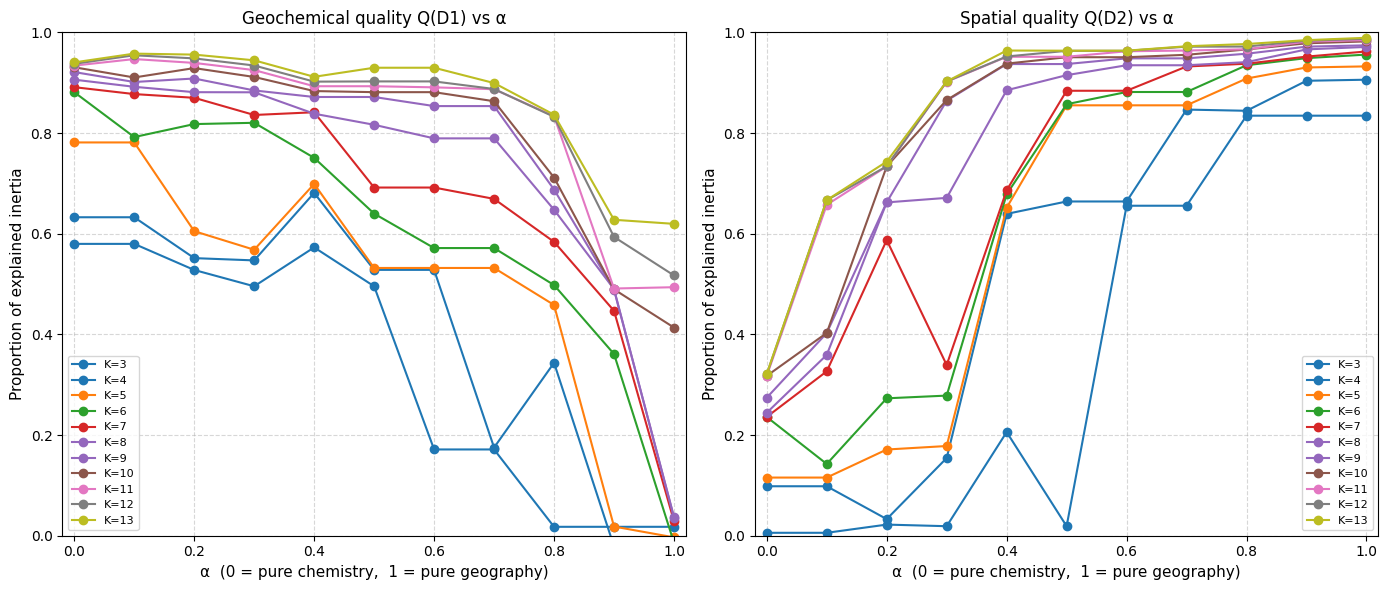

Quality curves saved: qualite_clustgeo.png

Final partition — alpha=0.5, K=12
  Geochemical quality Q(D1) = 0.903
  Spatial quality    Q(D2) = 0.963

Cluster membership:
                          Site  Cluster  Easting  Northing
                      Najar 01        1 1.820700 42.724600
                    Lercoul 02        1 1.542420 42.755969
             Najar 02 - US 205        1 1.793995 42.707480
        Najar 02 - Ferrier XVI        1 1.793995 42.707480
              Roc del Faoure 1        2 1.775000 42.876000
              Stal de Bizou 01        2 1.537182 42.826118
              Roc del Faoure 3        2 1.774000 42.875000
                    Pujols 01         2 1.520310 42.850048
                Prat d'en Paou        3 1.818685 42.533763
Rec de l'Orri de la Vinyola II        3 1.802309 42.555975
                    Cancardous        3 1.810821 42.516771
 Rec de l'Orri de la Vinyola I        3 1.793464 42.555223
                   Farga Areny        3 1.534000 42.556700
    

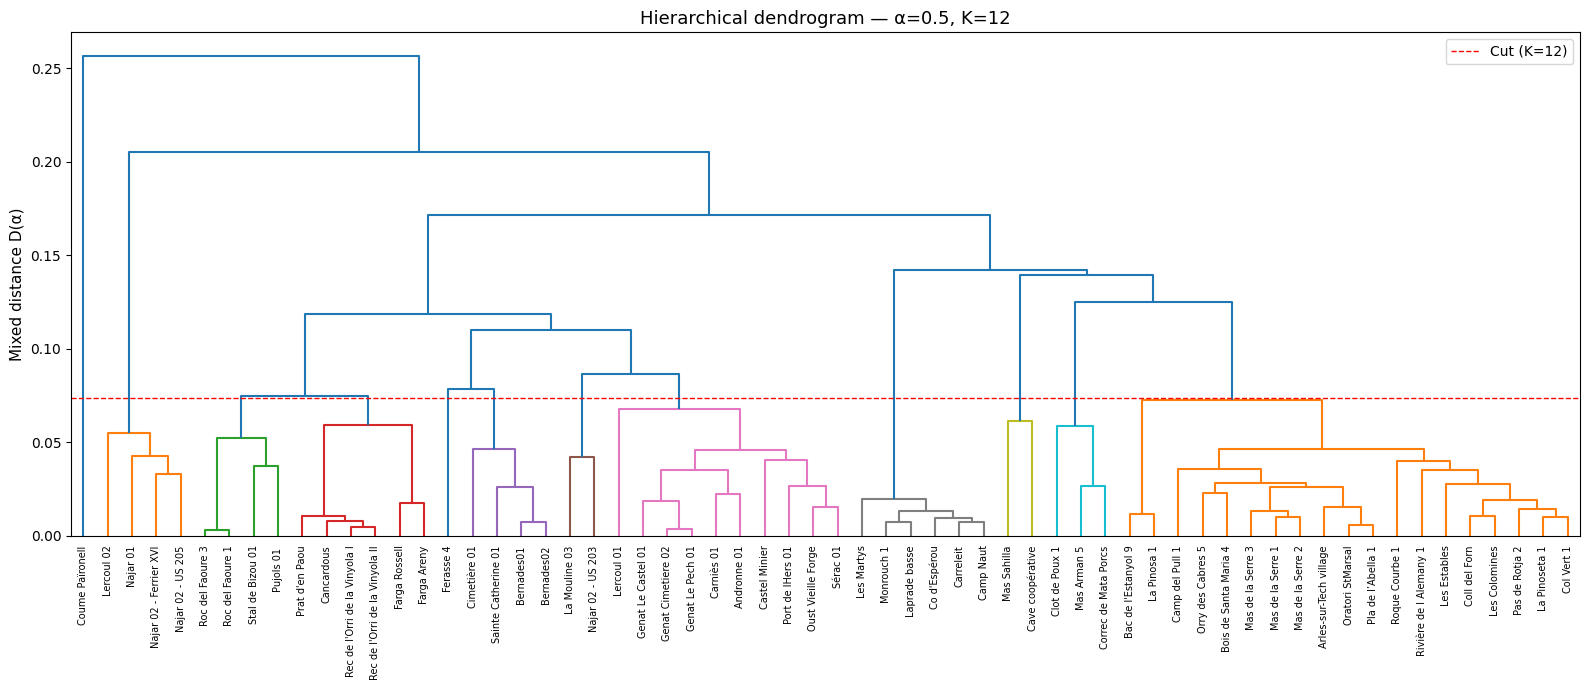

Dendrogram saved: dendrogramme_clustgeo.png
Interactive map saved and opened: carte_clusters_alpha0.5_K12.html

Grouping applied (non-interactive): clusters 1 and 7 -> 'G1_7'.


/var/folders/c3/l24zbq6s2cbct0zng4_520040000gp/T/ipykernel_51503/4076094755.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"log10_{col}"] = np.log10(valeurs)
/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/c3/l24zbq6s2cbct0zng4_520040000gp/T/ipykernel_51503/4076094755.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newfra

t-SNE (Figure 5) saved: tsne_individus_alpha0.5_K12_run1.html

Latest validated grouping (run 1) propagated into the CSV files (column 'Groupe').
Results saved: clusters_alpha0.5_K12.csv

NUMBER OF INDIVIDUALS PER CLUSTER
 Cluster Groupe  Nombre_sites  Nombre_individus
       1   G1_7             4                16
       2      2             4                17
       3      3             6                24
       4      4             4                21
       5      5             1                10
       6      6             2                 8
       7   G1_7            10                64
       8      8             6                21
       9      9             2                 8
      10     10             3                15
      11     11            19                78
      12     12             1                 5

Site detail per cluster:
  Cluster 1 (Group G1_7): Lercoul 02, Najar 01, Najar 02 - Ferrier XVI, Najar 02 - US 205
  Cluster 2 (Group 2): Pujols 01 , Roc

In [16]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
import plotly.io as pio
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
# NB: matplotlib dialog box, not Tkinter. On macOS, the Tcl/Tk bundled
# with python.org installers crashes (NSInvalidArgumentException,
# "-[NSApplication macOSVersion]") as soon as the very first Tk window is
# created on recent macOS versions (Apple removed the private API that
# Tk 8.6 depends on) — regardless of whether ttk or classic tk is used.
# matplotlib has no such dependency on macOS, hence this choice.


# ============================================================
# PARAMETERS — adjust after inspecting quality curves
# ============================================================
ALPHA_CHOISI = 0.5   # weight given to spatial distance [0 = pure chemistry, 1 = pure geography]
K_CHOISI     = 12     # number of clusters

# ============================================================
# 1. LOAD DATA
# ============================================================
try:
    matrice_wass = pd.read_csv("matrice_brute.csv", sep=";", index_col=0, encoding="utf-8")
    print(f"Wasserstein matrix loaded: {matrice_wass.shape[0]} sites.")
except FileNotFoundError:
    print("Error: 'matrice_brute.csv' not found. Run step 1 (Wasserstein distance) first.")
    exit()

try:
    coordonnees = pd.read_csv("coordonnees_sites.csv", sep=";", encoding="utf-8")
    coordonnees = coordonnees.drop_duplicates(subset="Entite").set_index("Entite")
    print(f"Coordinates loaded: {coordonnees.shape[0]} sites.")
except FileNotFoundError:
    print("Error: 'coordonnees_sites.csv' not found. Run step 1 (Wasserstein distance) first.")
    exit()

# Align on common sites
sites_communs = matrice_wass.index.intersection(coordonnees.index)
matrice_wass  = matrice_wass.loc[sites_communs, sites_communs]
coordonnees   = coordonnees.loc[sites_communs]
sites         = list(sites_communs)
n             = len(sites)
print(f"{n} sites retained after alignment.")

eastings  = coordonnees["easting"].values.astype(float)
northings = coordonnees["northing"].values.astype(float)

# ============================================================
# 2. GEOGRAPHIC DISTANCE MATRIX
# ============================================================
D2_vals = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        D2_vals[i, j] = np.sqrt((eastings[i] - eastings[j])**2 +
                                (northings[i] - northings[j])**2)

D1 = matrice_wass.copy()
D2 = pd.DataFrame(D2_vals, index=sites, columns=sites)

# ============================================================
# 3. NORMALISATION — ClustGeo style: T(D) = 1
#
# Total pseudo-inertia: T(D) = (1 / 2n) * sum_ij d_ij^2
# Normalised matrix:   D_norm = D / sqrt(T(D))
# => T(D_norm) = T(D) / T(D) = 1
# This makes alpha directly comparable across the two dimensions.
# ============================================================
def total_inertia(D):
    n = D.shape[0]
    return np.sum(D.values ** 2) / (2 * n)

def normalize_D(D):
    return D / np.sqrt(total_inertia(D))

D1_norm = normalize_D(D1)
D2_norm = normalize_D(D2)

print(f"T(D1_norm) = {total_inertia(D1_norm):.4f}  (should be 1.0)")
print(f"T(D2_norm) = {total_inertia(D2_norm):.4f}  (should be 1.0)")

# ============================================================
# 4. QUALITY CRITERION
#
# Within-cluster pseudo-inertia:
#   W(P, D) = sum_k  (1 / 2*n_k) * sum_{i,j in Ck} d_ij^2
# Proportion of explained inertia:
#   Q(P, D) = 1 - W(P, D) / T(D)
# A high Q means the partition captures most of the structure in D.
# ============================================================
def within_inertia(partition, D):
    D_vals = D.values
    W = 0.0
    for label in np.unique(partition):
        idx = np.where(partition == label)[0]
        nk  = len(idx)
        if nk > 1:
            sub = D_vals[np.ix_(idx, idx)]
            W  += np.sum(sub ** 2) / (2 * nk)
    return W

def quality(partition, D):
    T = total_inertia(D)
    W = within_inertia(partition, D)
    return 1.0 - W / T

# ============================================================
# 5. QUALITY CURVES OVER ALPHA AND K
#
# For each (alpha, K):
#   - build mixed matrix D(alpha) = (1-alpha)*D1_norm + alpha*D2_norm
#   - cluster with average linkage (appropriate for non-Euclidean distances)
#   - compute Q(D1) and Q(D2) separately
#
# Reading the plot:
#   - Q(D1) shows how well clusters remain geochemically coherent
#   - Q(D2) shows how much spatial compactness is gained
#   - Choose the smallest alpha at which Q(D2) starts to increase
#     substantially without Q(D1) collapsing
# ============================================================
alphas   = np.round(np.arange(0.0, 1.05, 0.1), 2)
K_range  = range(3, 14)
results  = []

print("\nComputing quality curves...")
for alpha in alphas:
    D_mix     = (1 - alpha) * D1_norm + alpha * D2_norm
    condensed = squareform(D_mix.values, checks=False)
    Z         = linkage(condensed, method='average')
    for K in K_range:
        partition = fcluster(Z, K, criterion='maxclust')
        results.append({
            'alpha': alpha, 'K': K,
            'Q_D1': quality(partition, D1_norm),
            'Q_D2': quality(partition, D2_norm)
        })

results_df = pd.DataFrame(results)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_K = cm.tab10(np.linspace(0, 0.8, len(K_range)))

for i, K in enumerate(K_range):
    sub = results_df[results_df['K'] == K]
    axes[0].plot(sub['alpha'], sub['Q_D1'], marker='o', color=colors_K[i], label=f'K={K}')
    axes[1].plot(sub['alpha'], sub['Q_D2'], marker='o', color=colors_K[i], label=f'K={K}')

for ax, title, ylabel in zip(
    axes,
    ["Geochemical quality Q(D1) vs α", "Spatial quality Q(D2) vs α"],
    ["Proportion of explained inertia"] * 2
):
    ax.set_xlabel("α  (0 = pure chemistry,  1 = pure geography)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("qualite_clustgeo.png", dpi=150)
plt.show()
print("Quality curves saved: qualite_clustgeo.png")

# ============================================================
# 6. FINAL CLUSTERING WITH CHOSEN ALPHA AND K
# ============================================================
D_mix_final = (1 - ALPHA_CHOISI) * D1_norm + ALPHA_CHOISI * D2_norm
condensed   = squareform(D_mix_final.values, checks=False)
Z_final     = linkage(condensed, method='average')
partition   = fcluster(Z_final, K_CHOISI, criterion='maxclust')

q1 = quality(partition, D1_norm)
q2 = quality(partition, D2_norm)
print(f"\nFinal partition — alpha={ALPHA_CHOISI}, K={K_CHOISI}")
print(f"  Geochemical quality Q(D1) = {q1:.3f}")
print(f"  Spatial quality    Q(D2) = {q2:.3f}")

resultat = pd.DataFrame({
    'Site'    : sites,
    'Cluster' : partition,
    'Easting' : eastings,
    'Northing': northings
})
print("\nCluster membership:")
print(resultat.sort_values('Cluster').to_string(index=False))

# ============================================================
# 7. DENDROGRAM
# ============================================================
# Colour threshold at the cut that yields K_CHOISI clusters
heights = sorted(Z_final[:, 2])
cut     = (heights[-K_CHOISI] + heights[-K_CHOISI + 1]) / 2

plt.figure(figsize=(16, 7))
dendrogram(
    Z_final,
    labels=sites,
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=cut
)
plt.axhline(y=cut, color='red', linestyle='--', linewidth=1, label=f'Cut (K={K_CHOISI})')
plt.title(f"Hierarchical dendrogram — α={ALPHA_CHOISI}, K={K_CHOISI}", fontsize=13)
plt.ylabel("Mixed distance D(α)", fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig("dendrogramme_clustgeo.png", dpi=150)
plt.show()
print("Dendrogram saved: dendrogramme_clustgeo.png")

# ============================================================
# 8. SPATIAL MAP OF CLUSTERS — interactive (Plotly), with basemap
#
# The "easting"/"northing" columns of coordonnees_sites.csv are actually
# WGS84 decimal degrees (longitude/latitude), not metric projected
# coordinates — so they can be used directly as lon/lat for a basemap.
# px.scatter_map (MapLibre, replacing px.scatter_mapbox deprecated since
# Plotly 6) is displayed here on a "white-bg" background, over which a
# custom raster layer loads the IGN "Plan IGN v2" tiles
# (GEOGRAPHICALGRIDSYSTEMS.PLANIGNV2), served by the IGN Géoplateforme
# (data.geopf.fr) via WMTS, free and open access with no API key needed
# (unlike the classic SCAN25, restricted to registered IGN keys). The
# layer is displayed at reduced opacity (OPACITE_FOND_CARTE) over a white
# background, which lightens it while keeping relief/place names visible,
# so that the cluster points (bright, fully opaque colours) stand out
# better by contrast.
#
# Hovering over a point shows: site name, cluster number,
# and coordinates. The HTML file can be opened in any browser.
# ============================================================

resultat['Cluster_label'] = 'Cluster ' + resultat['Cluster'].astype(str)

fig_map = px.scatter_map(
    resultat,
    lat='Northing',
    lon='Easting',
    color='Cluster_label',
    hover_name='Site',
    hover_data={
        'Cluster_label': True,
        'Easting'      : ':.4f',
        'Northing'     : ':.4f'
    },
    color_discrete_sequence=px.colors.qualitative.Bold,
    zoom=8,
    map_style="white-bg",
    title=(f"Spatially constrained geochemical clusters<br>"
           f"α={ALPHA_CHOISI}, K={K_CHOISI} | "
           f"Q(D1)={q1:.2f}, Q(D2)={q2:.2f}"),
    labels={'Cluster_label': 'Cluster'}
)

fig_map.update_traces(
    marker=dict(size=13, opacity=1.0),
    selector=dict(mode='markers')
)
fig_map.update_layout(
    legend_title="Cluster",
    font=dict(size=12),
    margin=dict(l=0, r=0, t=60, b=0),
    map_layers=[{
        "below": "traces",
        "sourcetype": "raster",
        "sourceattribution": "© IGN-F/Géoportail",
        "source": [URL_TUILES_IGN],
        "opacity": OPACITE_FOND_CARTE
    }]
)

map_html = f"carte_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.html"
pio.write_html(fig_map, file=map_html, auto_open=False, include_plotlyjs=True)
print(f"Interactive map saved and opened: {map_html}")

# ============================================================
# 9. FINAL CLUSTER GROUPING AND T-SNE (NON-INTERACTIVE)
#
# The interactive cluster selection (matplotlib dialog box with
# CheckButtons/TextBox/Button to choose and merge clusters by clicking,
# replayable until the "STOP" button) has no place in an unsupervised
# pipeline: this step is replaced here by the DIRECT application of the
# last grouping validated and used throughout the rest of the project
# (RF/SVM/NN/AFD, maps, comparisons): merging clusters 1 and 7 (same
# geochemical signature, cf. t-SNE, and same geographic area — Rancié
# massif) under the name "G1_7".
# ============================================================
chemin_individus = '/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Projet R FERMAPYR/data:/FERAPO_FERMAPYR_Data_v2.csv'
try:
    brut_individus = pd.read_csv(chemin_individus, sep=';', engine='python')
except FileNotFoundError:
    print(f"Error: file not found -> {chemin_individus}")
    exit()

typologies_a_exclure = TYPOLOGIES_A_EXCLURE
brut_individus = brut_individus[~brut_individus["typology"].isin(typologies_a_exclure)]

colonnes_elements = ["ce", "eu", "hf", "la", "nb", "nd", "sm", "u", "y", "yb", "th"]
brut_individus = calculer_rapport_log10(brut_individus, colonnes_elements, remplacer_zeros_par_nan=True)

colonnes_a_garder_ind = ["context_name"] + [f"rapport_log10_{col}" for col in colonnes_elements]
data_individus = brut_individus[colonnes_a_garder_ind].dropna()
data_individus = data_individus.rename(columns={"context_name": "Entite"})

site_to_cluster = resultat.set_index("Site")["Cluster"].to_dict()
data_individus["Cluster"] = data_individus["Entite"].map(site_to_cluster)

data_tsne_complet = data_individus.dropna(subset=["Cluster"]).copy()
data_tsne_complet["Cluster"] = data_tsne_complet["Cluster"].astype(int)

effectifs_individus_cluster = data_tsne_complet.groupby("Cluster").size()
effectifs_sites_cluster = resultat.groupby("Cluster").size()
effectifs_par_cluster = {
    int(c): (int(effectifs_individus_cluster.get(c, 0)), int(effectifs_sites_cluster.get(c, 0)))
    for c in sorted(resultat["Cluster"].unique())
}

rapport_cols_ind = [f"rapport_log10_{col}" for col in colonnes_elements]

dernier_groupe_map = {1: "G1_7", 7: "G1_7"}
print(f"\nGrouping applied (non-interactive): clusters 1 and 7 -> 'G1_7'.")

# t-SNE of all individuals, colored by the final grouping selected
# (equivalent to the last validation of the original interactive loop)
data_tsne_run = data_tsne_complet.copy()
groupe_map_tsne = {c: dernier_groupe_map.get(c, str(c)) for c in data_tsne_run["Cluster"].unique()}
data_tsne_run["Groupe"] = data_tsne_run["Cluster"].map(groupe_map_tsne)
data_tsne_run["Cluster_label"] = "Cluster " + data_tsne_run["Groupe"].astype(str)
run = 1

X_scaled_ind = StandardScaler().fit_transform(data_tsne_run[rapport_cols_ind].values)
perplexite = min(30, data_tsne_run.shape[0] - 1)
tsne_ind = TSNE(n_components=2, perplexity=perplexite, max_iter=1000, random_state=42)
X_tsne_ind = tsne_ind.fit_transform(X_scaled_ind)
data_tsne_run["TSNE1"] = X_tsne_ind[:, 0]
data_tsne_run["TSNE2"] = X_tsne_ind[:, 1]

fig_tsne = px.scatter(
    data_tsne_run, x="TSNE1", y="TSNE2", color="Cluster_label",
    hover_name="Entite",
    hover_data={"Cluster_label": True, "TSNE1": ":.2f", "TSNE2": ":.2f"},
    color_discrete_sequence=px.colors.qualitative.Bold,
    title=(f"t-SNE of individual samples by (merged) cluster<br>"
           f"α={ALPHA_CHOISI}, K={K_CHOISI}, perplexity={perplexite}"),
    labels={"Cluster_label": "Cluster", "TSNE1": "t-SNE 1", "TSNE2": "t-SNE 2"}
)
fig_tsne.update_traces(marker=dict(size=9, line=dict(width=1, color='black')), selector=dict(mode='markers'))
fig_tsne.update_layout(
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgrey'),
    yaxis=dict(showgrid=True, gridcolor='lightgrey'),
    legend_title="Cluster", font=dict(size=12)
)
tsne_html = f"tsne_individus_alpha{ALPHA_CHOISI}_K{K_CHOISI}_run{run}.html"
pio.write_html(fig_tsne, file=tsne_html, auto_open=False, include_plotlyjs=True)
print(f"t-SNE (Figure 5) saved: {tsne_html}")

# ============================================================
# FINAL GROUP — latest validated grouping, propagated into the CSV files
#
# "Cluster" = original ClustGeo partition (unchanged, section 6).
# "Groupe"  = latest grouping validated in the loop above. Clusters not
# covered by this latest grouping (never selected/checked at the last
# "Validate", or if no grouping was ever validated) keep their own
# cluster number as their group.
# ============================================================
tous_clusters = sorted(resultat["Cluster"].unique())
groupe_map_final = {c: str(c) for c in tous_clusters}
groupe_map_final.update(dernier_groupe_map)
resultat["Groupe"] = resultat["Cluster"].map(groupe_map_final)

if dernier_groupe_map:
    print(f"\nLatest validated grouping (run {run}) propagated into the CSV files (column 'Groupe').")
else:
    print("\nNo grouping was validated — column 'Groupe' = original cluster number.")

# ============================================================
# 10. EXPORT
# ============================================================
outname = f"clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.csv"
resultat.to_csv(outname, sep=";", index=False, encoding="utf-8")
print(f"Results saved: {outname}")

# ============================================================
# 11. NUMBER OF INDIVIDUALS PER CLUSTER
#
# Reuses data_individus (already loaded and filtered in section 9): the
# table sums the counts per cluster (sum of all the sites that make it up).
# ============================================================
individus_par_site = data_individus.groupby("Entite").size().rename("Nb_individus")

table_clusters = resultat[["Site", "Cluster", "Groupe"]].merge(
    individus_par_site, left_on="Site", right_index=True, how="left"
)
table_clusters["Nb_individus"] = table_clusters["Nb_individus"].fillna(0).astype(int)

nb_individus_par_cluster = (
    table_clusters.groupby("Cluster")
    .agg(
        Groupe=("Groupe", "first"),
        Nombre_sites=("Site", "count"),
        Nombre_individus=("Nb_individus", "sum"),
        Sites=("Site", lambda s: ", ".join(sorted(s)))
    )
    .reset_index()
    .sort_values("Cluster")
)

print("\n" + "=" * 60)
print("NUMBER OF INDIVIDUALS PER CLUSTER")
print("=" * 60)
print(nb_individus_par_cluster[["Cluster", "Groupe", "Nombre_sites", "Nombre_individus"]].to_string(index=False))
print("\nSite detail per cluster:")
for _, row in nb_individus_par_cluster.iterrows():
    print(f"  Cluster {row['Cluster']} (Group {row['Groupe']}): {row['Sites']}")

outname_individus = f"nombre_individus_par_cluster_alpha{ALPHA_CHOISI}_K{K_CHOISI}.csv"
nb_individus_par_cluster.to_csv(outname_individus, sep=";", index=False, encoding="utf-8")
print(f"\nTable saved: {outname_individus}")


## Step 3 — Production sites table (Table 1)

Table for the publication: reference (production) sites used to train the
models (RF/SVM/NN/AFD), with their historical period and the number of
SLAG samples collected at each site.

Same site selection as for training the models (Groupe kept if
>= MIN_ECHANTILLONS_PAR_CLUSTER samples), but here the count only covers
samples whose typology contains "slag" — "Smelting tap slag", "Smelting
slag", "Smelting furnace slag", "Smithing Slag", "Hearth bottom slag",
"Blast furnace slag" — excluding the other typologies present (prepared
ore, undetermined, fired clay...).

Output: tableau_sites_periode_scories_alpha{a}_K{k}.xlsx


In [17]:
import pandas as pd
import os

ALPHA_CHOISI = 0.5
K_CHOISI = 12
MIN_ECHANTILLONS_PAR_CLUSTER = 10
CLUSTERS_CSV = f"clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.csv"

DATA_DIR = os.path.expanduser(
    "~/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Projet R FERMAPYR/data:"
)


ORDRE_PERIODES = [
    "Late La Tène ", "Late Republic Period", "Early Roman Empire", "Roman Empire",
    "Roman Antiquity", "Late Roman Empire", "Early Middle Ages", "Carolingian Period",
    "High Middle Ages", "Middle Ages", "14th century", "Late Middle Ages",
    "Renaissance", "Early modern period", "Late modern period", "Not documented",
]

brut = pd.read_csv(os.path.join(DATA_DIR, "FERAPO_FERMAPYR_Data_v2.csv"), sep=';', engine='python')
brut = brut[~brut['typology'].isin(TYPOLOGIES_A_EXCLURE)]

clusters = pd.read_csv(CLUSTERS_CSV, sep=';', encoding='utf-8')
site_to_cluster = clusters.set_index("Site")["Groupe"].to_dict()

brut_ref = brut[brut["context_name"].isin(site_to_cluster)].copy()
brut_ref["Groupe"] = brut_ref["context_name"].map(site_to_cluster)

effectifs = brut_ref["Groupe"].value_counts()
groupes_retenus = effectifs[effectifs >= MIN_ECHANTILLONS_PAR_CLUSTER].index.tolist()
brut_ref_retenu = brut_ref[brut_ref["Groupe"].isin(groupes_retenus)].copy()
brut_ref_retenu["is_slag"] = brut_ref_retenu["typology"].str.contains("slag", case=False, na=False)

sites = brut_ref_retenu.groupby("context_name").agg(
    Period=("period_name", lambda s: s.dropna().mode().iloc[0] if s.notna().any() else "Not documented"),
    N_slag_samples=("is_slag", "sum"),
).reset_index().rename(columns={"context_name": "Site"})

sites_sans_slag = sites[sites["N_slag_samples"] == 0]
if not sites_sans_slag.empty:
    print(f"WARNING - sites retained with no slag sample at all: "
          f"{sites_sans_slag['Site'].tolist()}")

periodes_absentes = set(sites["Period"]) - set(ORDRE_PERIODES)
if periodes_absentes:
    ORDRE_PERIODES = ORDRE_PERIODES + sorted(periodes_absentes)

sites["_ordre"] = sites["Period"].map({p: i for i, p in enumerate(ORDRE_PERIODES)})
sites = sites.sort_values(["_ordre", "Site"]).drop(columns="_ordre").reset_index(drop=True)

nom_fichier = f"tableau_sites_periode_scories_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
sites.to_excel(nom_fichier, index=False, sheet_name="Sites - Period - Slag")
print(f"\nTable saved: {nom_fichier} ({sites.shape[0]} sites, "
      f"{sites['N_slag_samples'].sum()} slag samples in total)")
print(sites.to_string(index=False))



Table saved: tableau_sites_periode_scories_alpha0.5_K12.xlsx (57 sites, 279 slag samples in total)
                          Site               Period  N_slag_samples
               Camp del Pull 1        Late La Tène                4
              Oratori StMarsal Late Republic Period               4
             Pla de l’Abella 1 Late Republic Period               4
        Arles-sur-Tech village   Early Roman Empire               3
                  Cimetière 01   Early Roman Empire              12
                    Bernades01         Roman Empire               3
                    Bernades02         Roman Empire               2
                    Pujols 01          Roman Empire               8
                    Lercoul 01      Roman Antiquity              15
                 Les Colomines      Roman Antiquity               4
                    Les Martys      Roman Antiquity              19
             Mas de la Serre 1    Late Roman Empire               5
 Rec de l'Orri d

## Step 4 — Archaeological objects table (Table 2)

Archaeological objects table for the publication (supplementary
materials): Object / Site / Latitude / Longitude / Historical period,
in English.

Source: localisation objets v6.xlsx (columns "objet", "Commune", "lieu",
"Periode", "northing", "easting"), the same file used for the provenance
maps.

Output: tableau_objets_sites_periodes_EN.xlsx


In [18]:
import pandas as pd
import os

DATA_DIR = os.path.expanduser(
    "~/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Projet R FERMAPYR/data:"
)
FICHIER_LOCALISATION = os.path.join(DATA_DIR, "localisation objets v6.xlsx")

df = pd.read_excel(FICHIER_LOCALISATION)
df = df.rename(columns={
    "objet": "Object",
    "northing": "Latitude",
    "easting": "Longitude",
})

# French -> English translation of the historical periods
TRADUCTION_PERIODE = {
    "Antique": "Antiquity",
    "BMA": "Late Middle Ages",
    "Proto": "Protohistoric period",
    "XI": "11th century",
    "XII": "12th century",
    "XIV": "14th century",
    "XVI": "16th century",
    "XVI-XVIII": "16th–18th century",
    "II avant": "2nd century BC",
    "IV": "4th century AD",
}
df["Historical period"] = df["Periode"].map(TRADUCTION_PERIODE)

periodes_non_traduites = df.loc[df["Historical period"].isna(), "Periode"].unique()
if len(periodes_non_traduites) > 0:
    print(f"WARNING: periods with no English translation -> {list(periodes_non_traduites)}")

# "Site" = Commune + precise location (more informative than either column alone)
df["Site"] = df["Commune"].astype(str).str.strip()
lieu_valide = df["lieu"].notna() & (df["lieu"].astype(str).str.strip() != "")
df.loc[lieu_valide, "Site"] = df.loc[lieu_valide, "Commune"].astype(str).str.strip() + " – " + df.loc[lieu_valide, "lieu"].astype(str).str.strip()

table = df[["Object", "Site", "Latitude", "Longitude", "Historical period"]].copy()
table["Object"] = table["Object"].astype(str).str.strip()
table = table.sort_values(["Site", "Object"]).reset_index(drop=True)

excel_filename = "tableau_objets_sites_periodes_EN.xlsx"
table.to_excel(excel_filename, index=False, sheet_name="Objects")
print(f"Table saved: {excel_filename} ({table.shape[0]} objects)")
print(table.to_string(index=False))


Table saved: tableau_objets_sites_periodes_EN.xlsx (107 objects)
     Object                                                            Site  Latitude  Longitude    Historical period
  CM05-2-27                                 Aulus les Bains – Castel Minier 42.789799   1.336400     Late Middle Ages
  CM05-2-31                                 Aulus les Bains – Castel Minier 42.789799   1.336400     Late Middle Ages
  CM05-2-34                                 Aulus les Bains – Castel Minier 42.789799   1.336400     Late Middle Ages
  CM05-2-36                                 Aulus les Bains – Castel Minier 42.789799   1.336400     Late Middle Ages
   CM05-2-4                                 Aulus les Bains – Castel Minier 42.789799   1.336400     Late Middle Ages
  CM05-2-54                                 Aulus les Bains – Castel Minier 42.789799   1.336400     Late Middle Ages
  CM05-2-59                                 Aulus les Bains – Castel Minier 42.789799   1.336400     Late Mid

## Step 5 — Production sites map (Figure 1 / S1)

Interactive map of the reference (production) sites used to train the
provenance models: one marker per site, colored by historical period;
popup on hover = site name, period, number of slag samples collected at
this site.

Technical note: on this type of map (Plotly Scattermap, based on
MapLibre), only the "circle" symbol supports a custom color per marker —
the other shapes (square, triangle...) always display in black, with no
color control (verified empirically). The period is therefore encoded by
the COLOR of the markers (circles), not by their shape.

Source: tableau_sites_periode_scories_alpha0.5_K12.xlsx (Site, Period,
N_slag_samples) + clusters_alpha0.5_K12.csv (Easting/Northing coordinates).

Output: carte_sites_periode_scories.html


In [19]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px

ALPHA_CHOISI = 0.5
K_CHOISI = 12
TABLEAU_SITES = f"tableau_sites_periode_scories_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
CLUSTERS_CSV = f"clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.csv"


# ============================================================
# 1. DATA: sites + period + slag count + coordinates
# ============================================================
sites = pd.read_excel(TABLEAU_SITES)
clusters = pd.read_csv(CLUSTERS_CSV, sep=';', encoding='utf-8')
coord = clusters.set_index("Site")[["Easting", "Northing"]]

sites = sites.join(coord, on="Site")
sans_coord = sites[sites["Easting"].isna()]
if not sans_coord.empty:
    print(f"WARNING - sites with no coordinates (excluded from the map): {sans_coord['Site'].tolist()}")
sites = sites.dropna(subset=["Easting", "Northing"])

print(f"{sites.shape[0]} geolocated sites, {int(sites['N_slag_samples'].sum())} slag samples in total.")

sites["Popup"] = (
    "<b>" + sites["Site"] + "</b><br>"
    + "Period: " + sites["Period"] + "<br>"
    + "Slag samples: " + sites["N_slag_samples"].astype(int).astype(str)
)

# ============================================================
# 2. MAP — one color per period
# ============================================================
ORDRE_PERIODES = [
    "Late La Tène ", "Late Republic Period", "Early Roman Empire", "Roman Empire",
    "Roman Antiquity", "Late Roman Empire", "Early Middle Ages", "Carolingian Period",
    "High Middle Ages", "Middle Ages", "14th century", "Late Middle Ages",
    "Renaissance", "Early modern period", "Late modern period", "Not documented",
]
periodes_presentes = [p for p in ORDRE_PERIODES if p in sites["Period"].unique()]
palette = px.colors.qualitative.Bold + px.colors.qualitative.Set2 + px.colors.qualitative.Pastel
couleur_par_periode = {p: palette[i % len(palette)] for i, p in enumerate(periodes_presentes)}
couleur_par_periode["Not documented"] = "#999999"  # neutral grey for undated sites

fig = go.Figure()

for periode in periodes_presentes:
    sous_ens = sites[sites["Period"] == periode]
    fig.add_trace(go.Scattermap(
        lat=sous_ens["Northing"], lon=sous_ens["Easting"],
        mode="markers",
        marker=dict(size=14 + 0.8 * sous_ens["N_slag_samples"], color=couleur_par_periode[periode]),
        text=sous_ens["Popup"],
        hoverinfo="text",
        name=f"{periode} ({sous_ens.shape[0]} sites)",
    ))

fig.update_layout(
    title=(f"Reference (production) sites used to train the provenance models — "
           f"colour = historical period<br>"
           f"({sites.shape[0]} sites, {int(sites['N_slag_samples'].sum())} slag samples, "
           f"α={ALPHA_CHOISI}, K={K_CHOISI})"),
    map=dict(
        style="white-bg",
        center=dict(lat=sites["Northing"].mean(), lon=sites["Easting"].mean()),
        zoom=8,
        layers=[{
            "below": "traces",
            "sourcetype": "raster",
            "sourceattribution": "© IGN-F/Géoportail",
            "source": [URL_TUILES_IGN],
            "opacity": OPACITE_FOND_CARTE,
        }],
    ),
    legend_title="Historical period",
    font=dict(size=12),
    margin=dict(l=0, r=0, t=80, b=0),
)

outname = "carte_sites_periode_scories.html"
pio.write_html(fig, file=outname, auto_open=False, include_plotlyjs=True)
print(f"\nMap saved: {outname}")


57 geolocated sites, 279 slag samples in total.

Map saved: carte_sites_periode_scories.html


## Step 6 — Archaeological objects map (Figure 2 / S2)

Interactive map of the archaeological objects' collection sites (one
marker per site; on hover/click: site name, historical period, number of
objects, and list of objects collected at this site).

Source: localisation objets v6.xlsx.

Output: carte_sites_objets.html


In [20]:
import pandas as pd
import numpy as np
import os
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px

FICHIER_LOCALISATION = os.path.expanduser(
    "~/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Projet R FERMAPYR/data:/localisation objets v6.xlsx"
)

TRADUCTION_PERIODE = {
    "Antique": "Antiquity",
    "BMA": "Late Middle Ages",
    "Proto": "Protohistoric period",
    "XI": "11th century",
    "XII": "12th century",
    "XIV": "14th century",
    "XVI": "16th century",
    "XVI-XVIII": "16th–18th century",
    "II avant": "2nd century BC",
    "IV": "4th century AD",
}


# ============================================================
# 1. LOADING AND GROUPING BY SITE
# ============================================================
df = pd.read_excel(FICHIER_LOCALISATION)
df = df.rename(columns={"objet": "Object", "northing": "Latitude", "easting": "Longitude"})
df["Object"] = df["Object"].astype(str).str.strip()
df["Historical period"] = df["Periode"].map(TRADUCTION_PERIODE)

df["Site"] = df["Commune"].astype(str).str.strip()
lieu_valide = df["lieu"].notna() & (df["lieu"].astype(str).str.strip() != "")
df.loc[lieu_valide, "Site"] = (
    df.loc[lieu_valide, "Commune"].astype(str).str.strip()
    + " – " + df.loc[lieu_valide, "lieu"].astype(str).str.strip()
)

# Exclusion requested (same typologies excluded elsewhere in the pipeline):
# out-of-scope communes + Montbolo/Thuir (outside SITES_CONFIG, never classified by the models)
# + CAP1/MdS 8889 (individual objects not classified, missing/incomplete data) — strict
# consistency with comparaison_predictions_RF_SVM_NN_Groupe_alpha0.5_K12.xlsx (77 modelled objects).
COMMUNES_A_EXCLURE = ["Quirbajou", "Saintes-Maries-de-la-mer", "Vieille Toulouse", "La Palme", "Lattes",
                       "Montbolo", "Thuir"]
OBJETS_A_EXCLURE = ["CAP1", "MdS 8889"]
nb_avant = df.shape[0]
df = df[~df["Site"].str.startswith(tuple(COMMUNES_A_EXCLURE))]
df = df[~df["Object"].isin(OBJETS_A_EXCLURE)].reset_index(drop=True)
print(f"Objects excluded (communes: {', '.join(COMMUNES_A_EXCLURE)} ; individual objects: "
      f"{', '.join(OBJETS_A_EXCLURE)}): {nb_avant - df.shape[0]} ({nb_avant} -> {df.shape[0]} objects)")

# Coordinates/period consistency per site: the most frequent value per
# site is kept for the marker position.
sites_incoherents = []
lignes_sites = []
for site, sous_ensemble in df.groupby("Site", sort=True):
    if (sous_ensemble["Latitude"].nunique() > 1
            or sous_ensemble["Longitude"].nunique() > 1
            or sous_ensemble["Historical period"].nunique() > 1):
        sites_incoherents.append(site)
    lignes_sites.append({
        "Site": site,
        "Latitude": sous_ensemble["Latitude"].mode().iloc[0],
        "Longitude": sous_ensemble["Longitude"].mode().iloc[0],
        "Historical period": sous_ensemble["Historical period"].mode().iloc[0],
        "Nb_objets": len(sous_ensemble),
        "Objets": sorted(sous_ensemble["Object"].tolist()),
    })

sites_df = pd.DataFrame(lignes_sites)
print(f"{sites_df.shape[0]} sites, {df.shape[0]} objects in total.")
if sites_incoherents:
    print(f"WARNING - inconsistent coordinates/period between objects at the same site "
          f"(most frequent value kept for the marker): {sites_incoherents}")

# ============================================================
# 2. POPUP TEXT (site name, period, list of objects)
# ============================================================
def texte_popup(row):
    objets_html = "<br>".join(f"  • {o}" for o in row["Objets"])
    return (
        f"<b>{row['Site']}</b><br>"
        f"Period: {row['Historical period']}<br>"
        f"{row['Nb_objets']} object(s):<br>"
        f"{objets_html}"
    )

sites_df["Popup"] = sites_df.apply(texte_popup, axis=1)

# ============================================================
# 3. MAP (one color per historical period)
# ============================================================
periodes_uniques = sorted(sites_df["Historical period"].unique())
palette = px.colors.qualitative.Bold + px.colors.qualitative.Set2
couleur_par_periode = {p: palette[i % len(palette)] for i, p in enumerate(periodes_uniques)}

fig = go.Figure()

for periode in periodes_uniques:
    sous_ens = sites_df[sites_df["Historical period"] == periode]
    fig.add_trace(go.Scattermap(
        lat=sous_ens["Latitude"], lon=sous_ens["Longitude"],
        mode="markers",
        marker=dict(size=16 + 1.2 * sous_ens["Nb_objets"], color=couleur_par_periode[periode]),
        text=sous_ens["Popup"],
        hoverinfo="text",
        name=f"{periode} ({sous_ens.shape[0]} sites)",
    ))

fig.update_layout(
    title=f"Sampling sites of the archaeological objects ({sites_df.shape[0]} sites, {df.shape[0]} objects)",
    map=dict(
        style="white-bg",
        center=dict(lat=sites_df["Latitude"].mean(), lon=sites_df["Longitude"].mean()),
        zoom=7,
        layers=[{
            "below": "traces",
            "sourcetype": "raster",
            "sourceattribution": "© IGN-F/Géoportail",
            "source": [URL_TUILES_IGN],
            "opacity": OPACITE_FOND_CARTE,
        }],
    ),
    legend_title="Historical period",
    font=dict(size=12),
    margin=dict(l=0, r=0, t=60, b=0),
)

outname = "carte_sites_objets.html"
pio.write_html(fig, file=outname, auto_open=False, include_plotlyjs=True)
print(f"\nMap saved: {outname}")


Objects excluded (communes: Quirbajou, Saintes-Maries-de-la-mer, Vieille Toulouse, La Palme, Lattes, Montbolo, Thuir ; individual objects: CAP1, MdS 8889): 32 (107 -> 75 objects)
26 sites, 75 objects in total.

Map saved: carte_sites_objets.html


## Step 7 — Interactive biplots (exploration)

INTERACTIVE bivariate biplot (element vs element, reference samples
differentiated by "Groupe" cluster), with two dropdown menus (Element X /
Element Y) allowing the axes to be changed without rerunning the script,
in a standalone HTML file (Plotly).

Fixed log10(ppm) axes (trace element concentrations spanning several
orders of magnitude — standard convention).

Output: biplot_interactif_clusters_alpha{a}_K{k}.html
Simply open the file in a browser (double-click) — no server required,
plotly.js is included directly in the file.


In [21]:
import pandas as pd
import numpy as np
import os
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

pd.set_option('display.max_columns', None)

# ============================================================
# PARAMETRES
# ============================================================
ALPHA_CHOISI = 0.5
K_CHOISI = 12
CLUSTERS_CSV = f"clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.csv"

DATA_DIR = os.path.expanduser(
    "~/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Projet R FERMAPYR/data:"
)

COLONNES = ["Ce", "Eu", "Hf", "La", "Nb", "Nd", "Sm", "U", "Yb", "Th", "Y"]

ELEMENT_X_DEFAUT = "Sm"
ELEMENT_Y_DEFAUT = "Eu"


# ============================================================
# 1. REFERENCE DATA — labels = ClustGeo clusters ("Groupe" column)
# ============================================================
chemin_csv = os.path.join(DATA_DIR, "FERAPO_FERMAPYR_Data_v2.csv")
try:
    brut = pd.read_csv(chemin_csv, sep=';', engine='python')
    print(f"Reference file loaded: {brut.shape[0]} rows.")
except FileNotFoundError:
    print(f"Error: file not found -> {chemin_csv}")
    exit()

cols_a_majuscule = ["ce", "eu", "hf", "la", "nb", "nd", "sm", "u", "y", "yb",
                    "th", "pr", "gd", "dy", "ho", "er", "tm", "lu", "ba"]
brut.rename(columns={c: c.capitalize() for c in brut.columns if c in cols_a_majuscule},
            inplace=True)

brut = brut[~brut['typology'].isin(TYPOLOGIES_A_EXCLURE)]

try:
    clusters = pd.read_csv(CLUSTERS_CSV, sep=';', encoding='utf-8')
    print(f"Cluster file loaded: {clusters.shape[0]} sites -> {CLUSTERS_CSV}")
except FileNotFoundError:
    print(f"Error: file not found -> {CLUSTERS_CSV}. Rerun step 2 (clustering) of the pipeline first.")
    exit()

site_to_cluster = clusters.set_index("Site")["Groupe"].to_dict()

brut_ref = brut[brut["context_name"].isin(site_to_cluster)].copy()
if brut_ref.empty:
    print("No reference site matches the clusters file. Stopping.")
    exit()

data = brut_ref[["context_name"] + COLONNES].copy()
data["Groupe"] = data["context_name"].map(site_to_cluster)
data = data.rename(columns={"context_name": "Site"})

for col in COLONNES:
    data[col] = pd.to_numeric(data[col], errors='coerce')
    data.loc[data[col] <= 0, col] = np.nan  # log10 impossible on values <= 0

print(f"\nData loaded: {data.shape[0]} samples, {data['Groupe'].nunique()} groups.")
print(data["Groupe"].value_counts())

# ============================================================
# 2. SHARED PALETTE (identical to the other scripts in the project)
# ============================================================
groupes_uniques = sorted(data["Groupe"].unique(), key=str)
palette_couleurs = px.colors.qualitative.Dark24 + px.colors.qualitative.Light24
palette = {g: palette_couleurs[i % len(palette_couleurs)] for i, g in enumerate(groupes_uniques)}

# ============================================================
# 3. ONE TRACE PER GROUP (X/Y columns = ELEMENT_X_DEFAUT/ELEMENT_Y_DEFAUT initially)
# ============================================================
fig = go.Figure()

for groupe in groupes_uniques:
    sous_ensemble = data[data["Groupe"] == groupe].dropna(subset=[ELEMENT_X_DEFAUT, ELEMENT_Y_DEFAUT])
    fig.add_trace(go.Scatter(
        x=sous_ensemble[ELEMENT_X_DEFAUT],
        y=sous_ensemble[ELEMENT_Y_DEFAUT],
        mode="markers",
        name=str(groupe),
        marker=dict(size=10, color=palette[groupe], line=dict(width=0.6, color="black")),
        customdata=sous_ensemble[["Site"]],
        hovertemplate=(
            "Site : %{customdata[0]}<br>"
            f"Groupe : {groupe}<br>"
            "X : %{x:.3g}<br>"
            "Y : %{y:.3g}<extra></extra>"
        ),
    ))

# ============================================================
# 4. DROPDOWN MENUS — choice of the X element and the Y element
#    (simultaneous restyle of all traces, one per group)
# ============================================================
def boutons_axe(axe):
    """Generates the dropdown menu buttons for a given axis ('x' or 'y').
    Each button touches ONLY that axis (partial restyle via
    method="update"): the other axis keeps its current selection, so the
    two menus are truly independent. X and Y always come from the same
    rows per group (same index order), so there is no misalignment even
    if one of the two elements has NaNs (Plotly simply skips the
    corresponding point)."""
    boutons = []
    layout_key = "xaxis.title.text" if axe == "x" else "yaxis.title.text"
    for element in COLONNES:
        valeurs_par_trace = [data[data["Groupe"] == g][element] for g in groupes_uniques]
        boutons.append(dict(
            label=element,
            method="update",
            args=[{axe: valeurs_par_trace}, {layout_key: f"{element} (ppm)"}]
        ))
    return boutons


menu_x = boutons_axe("x")
menu_y = boutons_axe("y")
index_x_defaut = COLONNES.index(ELEMENT_X_DEFAUT)
index_y_defaut = COLONNES.index(ELEMENT_Y_DEFAUT)

fig.update_layout(
    updatemenus=[
        dict(
            buttons=menu_x, direction="down", x=0.0, y=0.99,
            xanchor="left", yanchor="top", showactive=True,
            active=index_x_defaut, pad=dict(r=10, t=10),
        ),
        dict(
            buttons=menu_y, direction="down", x=0.16, y=0.99,
            xanchor="left", yanchor="top", showactive=True,
            active=index_y_defaut, pad=dict(r=10, t=10),
        ),
    ],
    annotations=[
        dict(text="Élément X :", x=0.0, y=1.06, xref="paper", yref="paper",
             showarrow=False, xanchor="left", font=dict(size=12)),
        dict(text="Élément Y :", x=0.16, y=1.06, xref="paper", yref="paper",
             showarrow=False, xanchor="left", font=dict(size=12)),
    ],
    xaxis=dict(title=f"{ELEMENT_X_DEFAUT} (ppm)", type="linear"),
    yaxis=dict(title=f"{ELEMENT_Y_DEFAUT} (ppm)", type="linear"),
    title=dict(
        text=f"Biplot interactif éléments traces — différenciation par groupe (α={ALPHA_CHOISI}, K={K_CHOISI})",
        y=0.995, yanchor="top"
    ),
    legend=dict(title="Groupe"),
    width=1000,
    height=800,
    margin=dict(t=220),
)

# ============================================================
# 5. HTML "log-log scale" CHECKBOX (unchecked by default = linear)
#    Plotly has no native checkbox -> HTML/JS injected around the
#    figure, calling Plotly.relayout() on the type of both axes.
# ============================================================
DIV_ID = "biplot_div"
plotly_div = pio.to_html(fig, full_html=False, include_plotlyjs=True, div_id=DIV_ID)

page_html = f"""<!DOCTYPE html>
<html lang="fr">
<head>
<meta charset="utf-8">
<title>Biplot interactif — éléments traces (α={ALPHA_CHOISI}, K={K_CHOISI})</title>
<style>
  body {{ font-family: Arial, sans-serif; margin: 20px; }}
  #controle-echelle {{ margin-bottom: 10px; font-size: 14px; }}
  #controle-echelle label {{ cursor: pointer; }}
</style>
</head>
<body>
<div id="controle-echelle">
  <label>
    <input type="checkbox" id="chk-log-log">
    Échelle log-log (décoché = linéaire)
  </label>
</div>
{plotly_div}
<script>
  document.getElementById('chk-log-log').addEventListener('change', function() {{
    var type = this.checked ? 'log' : 'linear';
    Plotly.relayout('{DIV_ID}', {{'xaxis.type': type, 'yaxis.type': type}});
  }});
</script>
</body>
</html>
"""

nom_fichier = f"biplot_interactif_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.html"
with open(nom_fichier, "w", encoding="utf-8") as f:
    f.write(page_html)

print(f"\nInteractive biplot saved: {nom_fichier}")
print("Open this file in a browser: dropdown menus for the X/Y elements, "
      "checkbox to switch between linear (default) and log-log scale.")


Reference file loaded: 508 rows.
Cluster file loaded: 62 sites -> clusters_alpha0.5_K12.csv

Data loaded: 318 samples, 11 groups.
Groupe
G1_7    91
11      78
8       39
3       25
4       22
2       17
10      15
5       10
6        8
9        8
12       5
Name: count, dtype: int64

Interactive biplot saved: biplot_interactif_clusters_alpha0.5_K12.html
Open this file in a browser: dropdown menus for the X/Y elements, checkbox to switch between linear (default) and log-log scale.


## Step 8 — Random Forest model

Random Forest model (classes = "Groupe" column of
clusters_alpha{a}_K{k}.csv, geographic/chemical grouping derived from
ClustGeo).

No SMOTE: the BalancedRandomForestClassifier already rebalances each tree
via balanced bootstrap (undersampling the majority class down to the size
of the minority class), which avoids a double rebalancing and the risk of
overfitting on near-duplicate synthetic points for small classes. The
synthetic interpolation outliers (interpolation weight alpha ~ U(0.4,
0.6), noise factor ~ U(0.4, 0.7), Gaussian noise standard deviation = 1 —
parameters harmonized with SVM and NN) are generated directly from the
train split's samples, and the final training is done on the raw data +
outliers, without prior oversampling. The natural outliers (Isolation
Forest, contamination=0.05) are specific to RF/SVM and absent from the NN
pipeline.

Evaluation by a single 70/30 split AND by repeated cross-validation
(RepeatedStratifiedKFold, 5-fold x 10 repeats = 50 evaluations), with the
natural and synthetic outliers regenerated at each fold solely from the
current training fold (no leakage into the validation fold), using the
hyperparameters already found by RandomizedSearchCV. This yields a mean
± standard deviation of balanced_accuracy and macro F1.

The probabilities and predictions are exported both at the sample level
(per-sample detail) and averaged per object (one row per object), as well
as for the validation split and for each fold of the repeated
cross-validation, aggregated by reference site (useful for empirically
comparing the agreement rate between RF/SVM/NN).


Reference file loaded: 508 rows.
Cluster file loaded: 62 sites -> clusters_alpha0.5_K12.csv
Reference: 318 samples spread across 11 clusters (from 62 sites out of 62 in clusters_alpha0.5_K12.csv).
Clusters excluded (< 10 samples): 6 (8), 9 (8), 12 (5)
Reference retained: 297 samples, 8 clusters kept.
[OK] Capestang: 88 rows loaded from 'R_CAPESTANG_concatenated.xlsx'
[OK] Castel_Minier: 527 rows loaded from 'R_CASTEL_MINIER_concatenated.xlsx'
[OK] Ferrures: 341 rows loaded from 'ferrures_localisees.xlsx'
[OK] Mirabat: 332 rows loaded from 'R_MIRABAT_concatenated.xlsx'
[OK] Montreal: 305 rows loaded from 'R_MONTREAL_DE_SOS_concatenated.xlsx'
[OK] STCatherine: 78 rows loaded from 'R_STE_CATHERINE_concatenated.xlsx'

Final DataFrame: 918 rows after removing NaN/Inf. Saved: data_rapports_log_clusters_alpha0.5_K12.csv

Number of rows per site and type:
Site                            Type    
Andronne 01                     ensemble      5
Arles-sur-Tech village          ensemble      3
Bac

/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


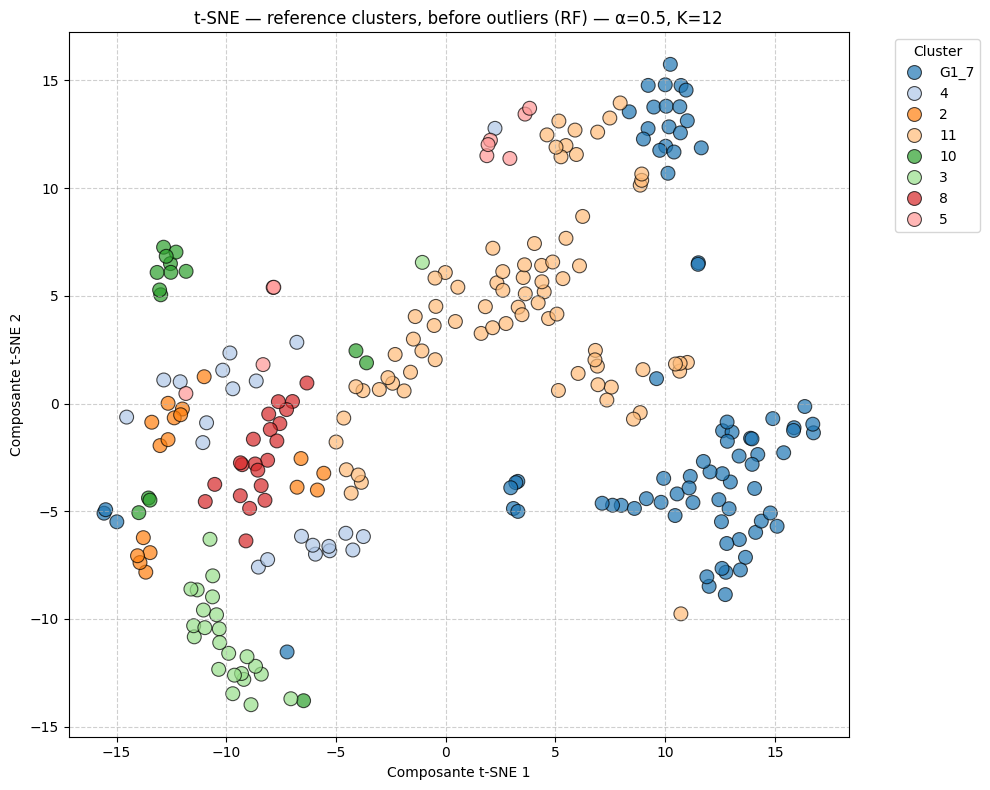

t-SNE saved: tsne_RF_avant_outliers_alpha0.5_K12.png

Stratified train/val split...

Generating the outliers...

Per-class counts (train split, without SMOTE):
Entite
G1_7    56
11      54
3       17
8       15
4       15
2       12
10      10
5        7
Name: count, dtype: int64


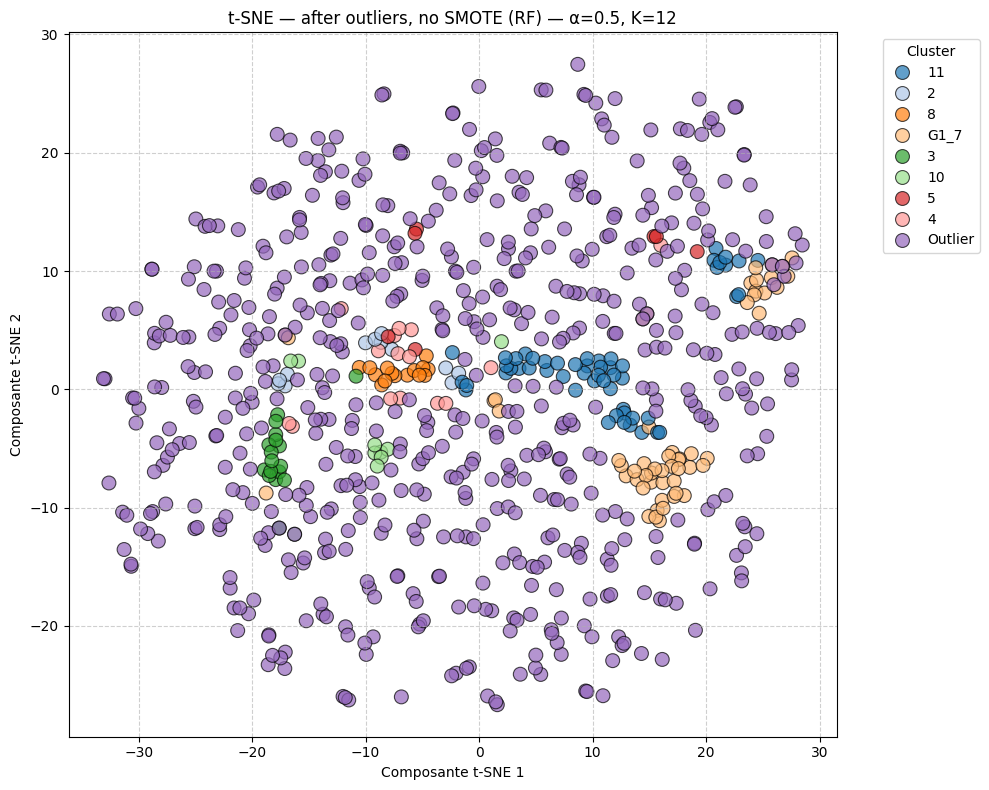

t-SNE saved: tsne_RF_apres_outliers_alpha0.5_K12.png

Label encoding and normalization...
Unique classes: ['10' '11' '2' '3' '4' '5' '8' 'G1_7' 'Outlier']
Distribution after adding the outliers (without SMOTE):
Outlier    610
G1_7        56
11          54
3           17
8           15
4           15
2           12
10          10
5            7
Name: count, dtype: int64
Data shapes:
X_train_scaled: (796, 11), y_train_encoded: (796,)
X_val_scaled: (80, 11), y_val_encoded: (80,)
X_test_scaled: (652, 11)

Hyperparameter optimization with RandomizedSearchCV...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV] END bootstrap=True, criterion=entropy, max_depth=40, max_features=None, min_samples_leaf=8, min_samples_split=8, n_estimators=221, replacement=True, sampling_strategy=auto; total time=   0.5s
[CV] END bootstrap=True, criterion=entropy, max_depth=40, max_features=None, min_samples_leaf=8, min_samples_split=8, n_estimators=221, replacement=True, sampling_strategy=auto;

/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  Fold 30/50 done...
  Fold 40/50 done...
  Fold 50/50 done...
Repeated cross-validation time: 106.08 seconds

Balanced accuracy over 5x10=50 folds: 0.8107 ± 0.0678 (min=0.6526, max=0.9510)
Macro F1-score over 50 folds: 0.7865 ± 0.0657 (min=0.6406, max=0.9371)

Classification report aggregated over all folds (each reference sample appears several times due to the repeats):
              precision    recall  f1-score   support

          10      0.707     0.773     0.739       150
          11      0.905     0.877     0.891       780
           2      0.664     0.824     0.735       170
           3      0.827     0.917     0.870       240
           4      0.653     0.610     0.631       210
           5      0.658     0.790     0.718       100
           8      0.797     0.824     0.810       210
        G1_7      0.963     0.877     0.918       800
     Outlier      0.000     0.000     0.000         0

    accuracy                          0.843      2660
   macro avg      0.686     

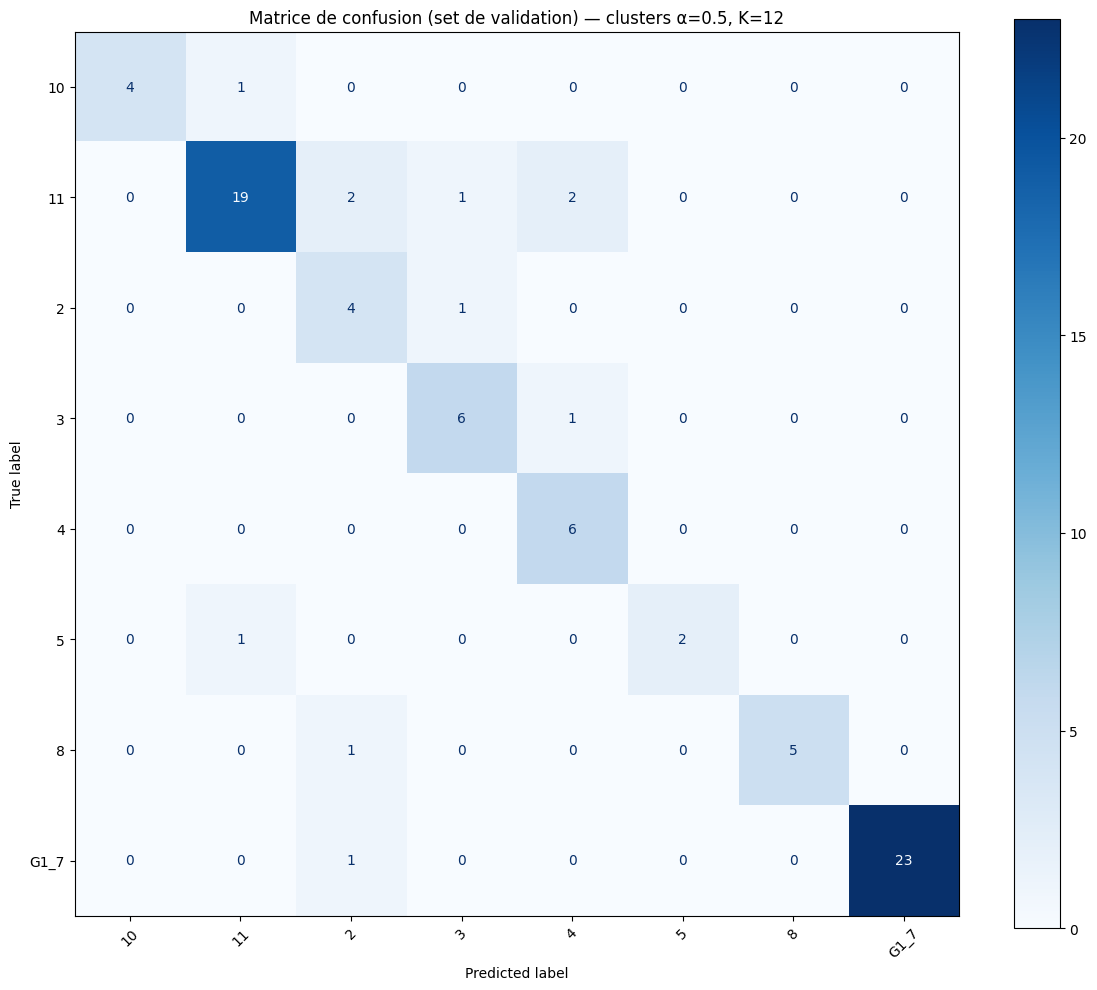


Classification report (validation):
              precision    recall  f1-score   support

          10      1.000     0.800     0.889         5
          11      0.905     0.792     0.844        24
           2      0.500     0.800     0.615         5
           3      0.750     0.857     0.800         7
           4      0.667     1.000     0.800         6
           5      1.000     0.667     0.800         3
           8      1.000     0.833     0.909         6
        G1_7      1.000     0.958     0.979        24

    accuracy                          0.863        80
   macro avg      0.853     0.838     0.830        80
weighted avg      0.893     0.863     0.869        80


Predicting probabilities for the test set (objects)...

Class-membership probabilities for each object of the test set:

Object: CAP3
Probabilities per class:
  10: 0.0350
  11: 0.0214
  2: 0.1993
  3: 0.3200
  4: 0.1143
  5: 0.0145
  8: 0.1915
  G1_7: 0.0534
  Outlier: 0.0507
  → Predicted cluster: 3 (probabi

In [22]:
# === 1. Imports ===
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, balanced_accuracy_score, f1_score
from sklearn.manifold import TSNE
from scipy.stats import randint
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
import os
from tabulate import tabulate

pd.set_option('display.max_columns', None)

# ============================================================
# PARAMETERS — choice of the ClustGeo clustering used as reference classes
# ============================================================
ALPHA_CHOISI = 0.5
K_CHOISI = 12
CLUSTERS_CSV = f"clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.csv"
MIN_ECHANTILLONS_PAR_CLUSTER = 10   # smaller clusters excluded (StratifiedKFold cv=5 requires >= 5 samples/class in the train set)

DATA_DIR = os.path.expanduser(
    "~/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Projet R FERMAPYR/data:"
)


COLONNES = ["Ce", "Eu", "Hf", "La", "Nb", "Nd", "Sm", "U", "Yb", "Th", "Y"]


# ============================================================
# 2. REFERENCE DATA — labels = ClustGeo clusters
# ============================================================
chemin_csv = os.path.join(DATA_DIR, "FERAPO_FERMAPYR_Data_v2.csv")
try:
    brut = pd.read_csv(chemin_csv, sep=';', engine='python')
    print(f"Reference file loaded: {brut.shape[0]} rows.")
except FileNotFoundError:
    print(f"Error: file not found -> {chemin_csv}")
    exit()

cols_a_majuscule = ["ce", "eu", "hf", "la", "nb", "nd", "sm", "u", "y", "yb",
                    "th", "pr", "gd", "dy", "ho", "er", "tm", "lu", "ba"]
brut.rename(columns={c: c.capitalize() for c in brut.columns if c in cols_a_majuscule},
            inplace=True)

brut = brut[~brut['typology'].isin(TYPOLOGIES_A_EXCLURE)]

try:
    clusters = pd.read_csv(CLUSTERS_CSV, sep=';', encoding='utf-8')
    print(f"Cluster file loaded: {clusters.shape[0]} sites -> {CLUSTERS_CSV}")
except FileNotFoundError:
    print(f"Error: file not found -> {CLUSTERS_CSV}. Rerun step 2 (clustering) of the pipeline first.")
    exit()

# "Groupe" = latest validated manual cluster grouping (e.g. merging
# several ClustGeo clusters into a single group); replaces "Cluster_label"
# (raw ClustGeo partition) as the training class.
site_to_cluster = clusters.set_index("Site")["Groupe"].to_dict()

brut_ref = brut[brut["context_name"].isin(site_to_cluster)].copy()
if brut_ref.empty:
    print("No reference site matches the clusters file. Stopping.")
    exit()

brut_ref_light = brut_ref[["context_name"] + COLONNES].copy()
brut_ref_light["Entite"] = brut_ref_light["context_name"].map(site_to_cluster)
brut_ref_light["Type"] = "ensemble"
brut_ref_light["Site"] = brut_ref_light["context_name"]
brut_ref_light = brut_ref_light.drop(columns="context_name")

print(f"Reference: {brut_ref_light.shape[0]} samples spread across "
      f"{brut_ref_light['Entite'].nunique()} clusters "
      f"(from {brut_ref['context_name'].nunique()} sites out of {len(site_to_cluster)} in {CLUSTERS_CSV}).")

# Exclusion of clusters that are too small (required by the stratified split + cross-validation)
effectifs_clusters = brut_ref_light["Entite"].value_counts()
clusters_exclus = effectifs_clusters[effectifs_clusters < MIN_ECHANTILLONS_PAR_CLUSTER].index.tolist()
if clusters_exclus:
    print(f"Clusters excluded (< {MIN_ECHANTILLONS_PAR_CLUSTER} samples): "
          f"{', '.join(f'{c} ({effectifs_clusters[c]})' for c in clusters_exclus)}")
    brut_ref_light = brut_ref_light[~brut_ref_light["Entite"].isin(clusters_exclus)]
print(f"Reference retained: {brut_ref_light.shape[0]} samples, "
      f"{brut_ref_light['Entite'].nunique()} clusters kept.")

# ============================================================
# 3. OBJETS ARCHEOLOGIQUES A CLASSER
# ============================================================
objets_list = []
for nom_site, nom_fichier, feuille, col_id in SITES_CONFIG:
    chemin = os.path.join(DATA_DIR, nom_fichier)
    try:
        if feuille is None:
            df = pd.read_csv(chemin, sep=';')
        else:
            df = pd.read_excel(chemin, sheet_name=feuille)
        print(f"[OK] {nom_site}: {df.shape[0]} rows loaded from '{nom_fichier}'")
    except FileNotFoundError:
        print(f"[MISSING] {nom_site}: file not found -> {chemin}")
        continue
    except Exception as e:
        print(f"[ERROR] {nom_site}: {e}")
        continue

    for col in COLONNES:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        else:
            df[col] = np.nan

    if col_id not in df.columns:
        df["_entite"] = nom_site + "_" + df.index.astype(str)
        col_id = "_entite"

    df_light = df[[col_id] + COLONNES].copy()
    df_light = df_light.rename(columns={col_id: "Entite"})
    df_light["Type"] = "objet"
    df_light["Site"] = nom_site
    objets_list.append(df_light)

if not objets_list:
    print("No object file loaded. Only the reference set will be processed.")

# ============================================================
# 4. ASSEMBLAGE ET RAPPORTS DE LOG
# ============================================================
brut2 = pd.concat([brut_ref_light] + objets_list, ignore_index=True)

brut2 = calculer_rapport_log10(brut2, COLONNES, remplacer_zeros_par_nan=False)

colonnes_a_garder = (
    ["Entite", "Type", "Site"]
    + [c for c in brut2.columns if c.startswith("rapport_log10_")]
)
data = brut2[colonnes_a_garder].copy()
data = data.replace([np.inf, -np.inf], np.nan).dropna()

outname = f"data_rapports_log_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.csv"
data.to_csv(outname, sep=';', index=False, encoding="utf-8")
print(f"\nFinal DataFrame: {data.shape[0]} rows after removing NaN/Inf. Saved: {outname}")
print("\nNumber of rows per site and type:")
print(data.groupby(['Site', 'Type']).size().to_string())

# ============================================================
# FROM HERE ON: balanced Random Forest pipeline.
# The training classes (y_train) are the ClustGeo cluster labels instead
# of the geological regions.
# ============================================================
train_data = data[data["Type"] == "ensemble"]  # Contient les classes (Cluster 1, Cluster 2, etc.)
test_data = data[data["Type"] == "objet"]       # Contient les noms d'objets (BLTER01, CAMEL01, etc.)

X_train = train_data[[col for col in train_data.columns if col.startswith("rapport_log10_")]]
y_train = train_data["Entite"]

X_test = test_data[[col for col in test_data.columns if col.startswith("rapport_log10_")]]
test_obj_names = test_data["Entite"]

print("Cluster classes represented in the reference set:", sorted(y_train.unique()))
print(y_train.value_counts())

tracer_tsne(X_train, y_train,
            f"t-SNE — reference clusters, before outliers (RF) — α={ALPHA_CHOISI}, K={K_CHOISI}",
            f"tsne_RF_avant_outliers_alpha{ALPHA_CHOISI}_K{K_CHOISI}.png")

# === Stratified train/val split ===
print("\nStratified train/val split...")
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train,
    test_size=0.3,
    random_state=42,
    stratify=y_train
)

# === Generating the outliers (natural + synthetic) ===
print("\nGenerating the outliers...")

# Detect natural outliers with Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_mask = iso_forest.fit_predict(X_train_split) == -1
X_natural_outliers = X_train_split[outlier_mask]
y_natural_outliers = pd.Series(["Outlier"] * len(X_natural_outliers), index=X_natural_outliers.index)

# No SMOTE: BalancedRandomForestClassifier already rebalances the classes
# via balanced bootstrap at each tree (see 'sampling_strategy' in the
# hyperparameter grid below). We therefore train on the real samples of
# the train split, plus the outliers (natural + synthetic).
print(f"\nPer-class counts (train split, without SMOTE):\n{y_train_split.value_counts()}")

# Generate synthetic outliers (more extreme) from the real samples
outliers = []
n_outliers = 600
unique_classes = [cls for cls in np.unique(y_train_split) if cls != "Outlier"]

for _ in range(n_outliers):
    class1, class2 = random.sample(list(unique_classes), 2)
    sample1 = X_train_split[y_train_split == class1].sample(1).iloc[0]
    sample2 = X_train_split[y_train_split == class2].sample(1).iloc[0]
    alpha = random.uniform(0.4, 0.6)
    interpolated_sample = sample1 * alpha + sample2 * (1 - alpha)
    noise_factor = random.uniform(0.4, 0.7)
    interpolated_sample += noise_factor * np.random.normal(0, 1, size=interpolated_sample.shape)
    outliers.append(interpolated_sample)

outliers_df = pd.DataFrame(outliers, columns=X_train_split.columns)

# Combine real data + natural outliers + synthetic outliers
X_train_with_outliers = pd.concat([X_train_split, outliers_df, X_natural_outliers], ignore_index=True)
y_train_with_outliers = pd.concat([
    y_train_split,
    pd.Series(["Outlier"] * len(outliers_df)),
    y_natural_outliers
], ignore_index=True)

tracer_tsne(X_train_with_outliers, y_train_with_outliers,
            f"t-SNE — after outliers, no SMOTE (RF) — α={ALPHA_CHOISI}, K={K_CHOISI}",
            f"tsne_RF_apres_outliers_alpha{ALPHA_CHOISI}_K{K_CHOISI}.png")

# === Label encoding and normalization ===
print("\nLabel encoding and normalization...")
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_with_outliers)
y_val_encoded = label_encoder.transform(y_val)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_with_outliers)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Checks
print("Unique classes:", label_encoder.classes_)
print("Distribution after adding the outliers (without SMOTE):")
print(pd.Series(y_train_with_outliers).value_counts())
print("Data shapes:")
print(f"X_train_scaled: {X_train_scaled.shape}, y_train_encoded: {y_train_encoded.shape}")
print(f"X_val_scaled: {X_val_scaled.shape}, y_val_encoded: {y_val_encoded.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")

# === Hyperparameter optimization with BalancedRandomForest ===
print("\nHyperparameter optimization with RandomizedSearchCV...")
start_time = time.time()

param_dist = {
    'n_estimators': randint(100, 1000),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy'],
    'replacement': [True, False],
    # No fixed value like {cls: 200}: without SMOTE, the real per-class
    # counts (5 to 54 for the clusters, cf. y_train_split) are well below
    # 200; requesting 200 for sampling without replacement makes almost
    # every fit fail. 'auto'/'not majority' undersample the majority
    # class(es) down to the minority level, which is consistent with the
    # real counts.
    'sampling_strategy': ['auto', 'not majority']
}

brf = BalancedRandomForestClassifier(random_state=42, n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=brf,
    param_distributions=param_dist,
    n_iter=200,
    cv=cv,
    scoring='balanced_accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train_scaled, y_train_encoded)

best_brf = random_search.best_estimator_
best_params = random_search.best_params_

print(f"\nBest cross-validation score (balanced_accuracy, without SMOTE): {random_search.best_score_:.4f}")

print("\nBest hyperparameters found:")
for param, value in best_params.items():
    print(f"{param}: {value}")

end_time = time.time()
print(f"Optimization time: {end_time - start_time:.2f} seconds")

# ============================================================
# Robust evaluation via repeated cross-validation (RepeatedStratifiedKFold)
# ============================================================
# The single 70/30 split used below has only ~85 samples for 10 classes
# (down to 2 for the smallest): a score computed on a single draw is very
# noisy. Here we repeat a 5-fold CV ten times (50 folds) on the WHOLE
# reference set, with the hyperparameters already found (a nested search
# would be more rigorous but ~50x more costly). At each fold, the outliers
# (natural + synthetic) are regenerated solely from the current training
# fold, so as not to leak into the validation fold.
# ============================================================
print("\n=== Robust evaluation via repeated cross-validation (RepeatedStratifiedKFold) ===")

N_SPLITS_CV = 5
N_REPEATS_CV = 10
rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS_CV, n_repeats=N_REPEATS_CV, random_state=42)

brf_params_valides = {k: v for k, v in best_params.items() if k in BalancedRandomForestClassifier().get_params()}

cv_balanced_acc = []
cv_macro_f1 = []
all_y_true_cv = []
all_y_pred_cv = []
cv_predictions_detail = []  # une entrée par (répétition, échantillon de validation) : pour comparaison inter-méthodes

start_time_cv = time.time()
for fold_i, (cv_train_idx, cv_val_idx) in enumerate(rskf.split(X_train, y_train)):
    X_fold_train, X_fold_val = X_train.iloc[cv_train_idx], X_train.iloc[cv_val_idx]
    y_fold_train, y_fold_val = y_train.iloc[cv_train_idx], y_train.iloc[cv_val_idx]

    # Natural outliers (Isolation Forest), from the training fold only
    iso_fold = IsolationForest(contamination=0.05, random_state=42)
    fold_outlier_mask = iso_fold.fit_predict(X_fold_train) == -1
    X_fold_natural_outliers = X_fold_train[fold_outlier_mask]
    y_fold_natural_outliers = pd.Series(["Outlier"] * len(X_fold_natural_outliers), index=X_fold_natural_outliers.index)

    # Synthetic outliers by interpolation, from the training fold only
    fold_outliers = []
    fold_unique_classes = [cls for cls in np.unique(y_fold_train) if cls != "Outlier"]
    for _ in range(n_outliers):
        class1, class2 = random.sample(list(fold_unique_classes), 2)
        sample1 = X_fold_train[y_fold_train == class1].sample(1).iloc[0]
        sample2 = X_fold_train[y_fold_train == class2].sample(1).iloc[0]
        alpha_interp = random.uniform(0.4, 0.6)
        interpolated_sample = sample1 * alpha_interp + sample2 * (1 - alpha_interp)
        noise_factor = random.uniform(0.4, 0.7)
        interpolated_sample += noise_factor * np.random.normal(0, 1, size=interpolated_sample.shape)
        fold_outliers.append(interpolated_sample)
    fold_outliers_df = pd.DataFrame(fold_outliers, columns=X_fold_train.columns)

    X_fold_train_aug = pd.concat([X_fold_train, fold_outliers_df, X_fold_natural_outliers], ignore_index=True)
    y_fold_train_aug = pd.concat([
        y_fold_train,
        pd.Series(["Outlier"] * len(fold_outliers_df)),
        y_fold_natural_outliers
    ], ignore_index=True)

    fold_label_encoder = LabelEncoder()
    y_fold_train_encoded = fold_label_encoder.fit_transform(y_fold_train_aug)
    y_fold_val_encoded = fold_label_encoder.transform(y_fold_val)

    fold_scaler = StandardScaler()
    X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train_aug)
    X_fold_val_scaled = fold_scaler.transform(X_fold_val)

    fold_model = BalancedRandomForestClassifier(**brf_params_valides, random_state=42, n_jobs=-1)
    fold_model.fit(X_fold_train_scaled, y_fold_train_encoded)
    y_fold_pred_encoded = fold_model.predict(X_fold_val_scaled)
    y_fold_pred_proba = fold_model.predict_proba(X_fold_val_scaled)

    # Per-sample validation detail (site + true provenance + per-class
    # probability), with the repeat number (0 to N_REPEATS_CV-1) — used
    # afterwards to compare RF/SVM/NN on far more cases than a single
    # 70/30 split.
    repeat_idx = fold_i // N_SPLITS_CV
    sites_fold_val = train_data.loc[X_fold_val.index, "Site"]
    for row_i, idx in enumerate(X_fold_val.index):
        entree = {
            "Repeat": repeat_idx,
            "Site": sites_fold_val.loc[idx],
            "Vraie_provenance": y_fold_val.loc[idx],
        }
        for class_idx, class_name in enumerate(fold_label_encoder.classes_):
            entree[class_name] = y_fold_pred_proba[row_i, class_idx]
        cv_predictions_detail.append(entree)

    cv_balanced_acc.append(balanced_accuracy_score(y_fold_val_encoded, y_fold_pred_encoded))
    # labels= restricted to the classes actually present in y_fold_val (never "Outlier",
    # which is only added to the train set): without this, a false-positive "Outlier" on a
    # fold adds a phantom class at F1=0 to the macro average, diluting the score in a way
    # that is not consistent from fold to fold (unlike balanced_accuracy_score, which already
    # excludes it on its own).
    cv_macro_f1.append(f1_score(y_fold_val_encoded, y_fold_pred_encoded, labels=np.unique(y_fold_val_encoded), average='macro', zero_division=0))

    all_y_true_cv.extend(fold_label_encoder.inverse_transform(y_fold_val_encoded))
    all_y_pred_cv.extend(fold_label_encoder.inverse_transform(y_fold_pred_encoded))

    if (fold_i + 1) % 10 == 0:
        print(f"  Fold {fold_i + 1}/{N_SPLITS_CV * N_REPEATS_CV} done...")

cv_balanced_acc = np.array(cv_balanced_acc)
cv_macro_f1 = np.array(cv_macro_f1)
print(f"Repeated cross-validation time: {time.time() - start_time_cv:.2f} seconds")

print(f"\nBalanced accuracy over {N_SPLITS_CV}x{N_REPEATS_CV}={len(cv_balanced_acc)} folds: "
      f"{cv_balanced_acc.mean():.4f} ± {cv_balanced_acc.std():.4f} "
      f"(min={cv_balanced_acc.min():.4f}, max={cv_balanced_acc.max():.4f})")
print(f"Macro F1-score over {len(cv_macro_f1)} folds: "
      f"{cv_macro_f1.mean():.4f} ± {cv_macro_f1.std():.4f} "
      f"(min={cv_macro_f1.min():.4f}, max={cv_macro_f1.max():.4f})")

print("\nClassification report aggregated over all folds "
      "(each reference sample appears several times due to the repeats):")
print(classification_report(all_y_true_cv, all_y_pred_cv, digits=3, zero_division=0))

# === Export of the CV validation detail, aggregated by (repeat, site) ===
# Classes sometimes differ slightly from one fold to another (rare, if a
# class disappears from a fold's train set) -> missing columns filled with
# 0 (zero probability for a class not seen by that particular fold).
cv_detail_df = pd.DataFrame(cv_predictions_detail).fillna(0)
colonnes_proba = [c for c in cv_detail_df.columns if c not in ("Repeat", "Site", "Vraie_provenance")]

proba_cv_par_site = cv_detail_df.groupby(["Repeat", "Site"])[colonnes_proba].mean()
provenance_predite_cv = proba_cv_par_site.idxmax(axis=1)
nb_echantillons_cv = cv_detail_df.groupby(["Repeat", "Site"]).size()
vraie_provenance_cv = cv_detail_df.groupby(["Repeat", "Site"])["Vraie_provenance"].first()

# Export schema deliberately reduced to the essential columns (not the
# per-class probabilities): SVM trains its fold model with
# probability=False (for speed, x50 folds), so its equivalent export can
# only offer a majority label, not averaged probabilities — the same
# minimal schema is kept for all 3 methods, for consistency.
resultat_cv = pd.DataFrame({
    "Nb_echantillons_val": nb_echantillons_cv,
    "Vraie_provenance": vraie_provenance_cv,
    "Provenance_predite": provenance_predite_cv,
}).reset_index()

excel_filename = f"RF_validation_CV_par_site_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
resultat_cv.to_excel(excel_filename, sheet_name="Validation CV par site", index=False)
print(f"\nRepeated cross-validation detail, by (repeat, site), saved: {excel_filename} "
      f"({resultat_cv.shape[0]} rows, {resultat_cv['Site'].nunique()} distinct sites)")

# === Evaluation on the validation set ===
print("\nEvaluation on the validation set...")
y_val_pred = best_brf.predict(X_val_scaled)
y_val_pred_proba = best_brf.predict_proba(X_val_scaled)

val_accuracy = best_brf.score(X_val_scaled, y_val_encoded)
val_balanced_accuracy = balanced_accuracy_score(y_val_encoded, y_val_pred)
print(f"Accuracy (validation): {val_accuracy:.4f}")
print(f"Balanced Accuracy (validation): {val_balanced_accuracy:.4f}")

# === Export of the validation predictions, aggregated by site (true
# provenance known) — for empirical cross-method comparison ===
sites_val = train_data.loc[X_val.index, "Site"]
df_val_detail = pd.DataFrame(
    y_val_pred_proba,
    columns=label_encoder.classes_,
    index=X_val.index
)
df_val_detail["Site"] = sites_val
df_val_detail["Vraie_provenance"] = y_val

proba_val_par_site = df_val_detail.groupby("Site")[list(label_encoder.classes_)].mean()
provenance_predite_val = proba_val_par_site.idxmax(axis=1)
nb_echantillons_val_par_site = df_val_detail.groupby("Site").size()
vraie_provenance_val = df_val_detail.groupby("Site")["Vraie_provenance"].first()

proba_val_par_site.insert(0, "Nb_echantillons_val", nb_echantillons_val_par_site)
proba_val_par_site.insert(1, "Vraie_provenance", vraie_provenance_val)
proba_val_par_site.insert(2, "Provenance_predite", provenance_predite_val)

excel_filename = f"RF_validation_par_site_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
proba_val_par_site.to_excel(excel_filename, sheet_name="Validation par site")
print(f"\nValidation by site (for cross-method comparison) saved: {excel_filename} "
      f"({proba_val_par_site.shape[0]} sites)")

# "Outlier" never appears in y_val (added only after the split) and may
# never be predicted on real samples: the confusion matrix can therefore
# be smaller than the total number of classes. labels/display_labels are
# restricted to the classes actually present, to avoid a dimension
# mismatch with ConfusionMatrixDisplay.
all_val_classes = np.unique(np.concatenate([y_val_encoded, y_val_pred]))
val_class_names = [label_encoder.classes_[i] for i in sorted(all_val_classes)]

cm = confusion_matrix(y_val_encoded, y_val_pred, labels=all_val_classes)
plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_class_names
)
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
plt.title(f"Matrice de confusion (set de validation) — clusters α={ALPHA_CHOISI}, K={K_CHOISI}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nClassification report (validation):")
print(classification_report(
    y_val_encoded,
    y_val_pred,
    labels=all_val_classes,
    target_names=val_class_names,
    digits=3,
    zero_division=0
))

# === Probability predictions for the test set (OBJECTS) ===
print("\nPredicting probabilities for the test set (objects)...")
test_predictions = best_brf.predict(X_test_scaled)
test_predictions_proba = best_brf.predict_proba(X_test_scaled)

# === Displaying the probabilities per object ===
print("\nClass-membership probabilities for each object of the test set:")
for i, obj_name in enumerate(test_obj_names):
    print(f"\nObject: {obj_name}")
    print("Probabilities per class:")
    for class_idx, class_name in enumerate(label_encoder.classes_):
        proba = test_predictions_proba[i, class_idx]
        print(f"  {class_name}: {proba:.4f}")
    predicted_class = label_encoder.inverse_transform([test_predictions[i]])[0]
    max_prob = np.max(test_predictions_proba[i])
    print(f"  → Predicted cluster: {predicted_class} (probability = {max_prob:.4f})")

# === Probability heatmap, object by object ===
print("\nProbability heatmap, object by object...")
unique_test_objects = test_obj_names.unique()
for obj_name in unique_test_objects:
    mask = (test_obj_names == obj_name).values
    proba_obj = test_predictions_proba[mask]
    sample_names = [f"Échantillon {i + 1}" for i in range(proba_obj.shape[0])]

    plt.figure(figsize=(12, max(4, 0.5 * len(sample_names))))
    sns.heatmap(
        proba_obj,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        xticklabels=label_encoder.classes_,
        yticklabels=sample_names,
        vmin=0,
        vmax=1
    )
    plt.title(f"Heatmap des probabilités de cluster pour l'objet {obj_name}")
    plt.xlabel("Cluster")
    plt.ylabel("Échantillons")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    os.makedirs("heatmaps_RF", exist_ok=True)
    nom_heatmap = f"heatmaps_RF/heatmap_RF_{str(obj_name).replace(' ', '_')}_alpha{ALPHA_CHOISI}_K{K_CHOISI}.png"
    plt.savefig(nom_heatmap, dpi=120, bbox_inches='tight')
    plt.close()

# === Table of AVERAGE probabilities per object (predicted provenance) ===
# One row per object (its repeated samples averaged), rather than one row
# per sample (652 rows): avoids a huge console print (tabulate 'grid' over
# hundreds of rows) right after the last heatmap, and directly gives the
# predicted provenance group per object.
print("\nComputing the average probabilities per object...")
proba_par_echantillon = pd.DataFrame(
    test_predictions_proba,
    columns=label_encoder.classes_,
    index=test_obj_names.values
)
proba_moyenne_par_objet = proba_par_echantillon.groupby(level=0).mean()
groupe_predit_par_objet = proba_moyenne_par_objet.idxmax(axis=1)
nb_echantillons_par_objet = test_obj_names.value_counts()

proba_moyenne_par_objet.insert(0, "Nb_echantillons", nb_echantillons_par_objet.reindex(proba_moyenne_par_objet.index))
proba_moyenne_par_objet.insert(1, "Provenance_predite", groupe_predit_par_objet)

print("\nAverage class-membership probabilities per group, per object (predicted provenance):")
print(tabulate(proba_moyenne_par_objet, headers='keys', tablefmt='grid', floatfmt=".4f"))

# Explicit filename specific to RF, prefixed to avoid any collision
# with the equivalent table produced by the other methods.
excel_filename = f"RF_probabilites_moyennes_par_objet_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
proba_moyenne_par_objet.to_excel(excel_filename, sheet_name="Probabilités moyennes")
print(f"\nThe table of average probabilities per object has been saved to: {excel_filename}")

# === Per-sample detail (predicted class + probabilities) — Excel export
# uniquement, sans impression console (centaines de lignes, cf. ci-dessus) ===
results_df = pd.DataFrame({
    "Objet": test_obj_names,
    "Cluster prédit": label_encoder.inverse_transform(test_predictions),
    **{f"Proba_{cls}": test_predictions_proba[:, i] for i, cls in enumerate(label_encoder.classes_)}
})

excel_filename = f"RF_detail_par_echantillon_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
results_df.to_excel(excel_filename, sheet_name="Prédictions")
print(f"\nThe per-sample detail ({results_df.shape[0]} rows) has been saved to: {excel_filename}")

# === Adaptive thresholds to detect the outliers ===
print("\nComputing adaptive per-class thresholds (based on the validation set)...")
class_thresholds = {}
for class_name in label_encoder.classes_:
    class_idx = label_encoder.transform([class_name])[0]
    class_probas = y_val_pred_proba[:, class_idx]
    mean_proba = np.mean(class_probas)
    std_proba = np.std(class_probas)
    class_thresholds[class_name] = max(0.3, mean_proba - std_proba)
    print(f"{class_name}: threshold = {class_thresholds[class_name]:.4f}")

# === Outlier detection in the test set ===
print("\nDetecting outliers in the test set (adaptive threshold):")
outliers_in_test = []
for i, obj_name in enumerate(test_obj_names):
    max_proba = np.max(test_predictions_proba[i])
    predicted_class = label_encoder.classes_[np.argmax(test_predictions_proba[i])]
    if max_proba < class_thresholds[predicted_class]:
        outliers_in_test.append(obj_name)
        print(f"⚠️ {obj_name}: Probability too low ({max_proba:.4f}) → Possible outlier")
    else:
        print(f"✅ {obj_name}: Cluster {predicted_class} (probability = {max_proba:.4f})")

print(f"\nNumber of outliers detected in the test set: {len(outliers_in_test)}")

# === 10 runs for probability stability ===
# Interactive prompt removed for unsupervised execution (see file header):
user_input = "n"  # optional feature, not used in the publication

if user_input.lower() == 'o':
    print("\nRunning the 10 executions for stability...")
    all_probas = np.zeros((10, test_predictions_proba.shape[0], test_predictions_proba.shape[1]))

    n_runs = 10
    for run in range(n_runs):
        print(f"Run {run + 1}/{n_runs}...")
        brf_run = BalancedRandomForestClassifier(
            **{k: v for k, v in best_params.items() if k in BalancedRandomForestClassifier().get_params()},
            random_state=42 + run,
            n_jobs=-1
        )
        brf_run.fit(X_train_scaled, y_train_encoded)
        all_probas[run] = brf_run.predict_proba(X_test_scaled)

    mean_probas = np.mean(all_probas, axis=0)
    std_probas = np.std(all_probas, axis=0)

    # Per-sample detail (652 rows) exported to Excel without console
    # printing — same reason as for the equivalent table above.
    mean_probas_df = pd.DataFrame(
        mean_probas,
        columns=label_encoder.classes_,
        index=test_obj_names
    )
    excel_filename = f"RF_detail_par_echantillon_10_executions_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
    mean_probas_df.to_excel(excel_filename, sheet_name="Moyennes")
    print(f"\nThe per-sample detail ({mean_probas_df.shape[0]} rows) has been saved to: {excel_filename}")

    # Table averaged per object (one row per object, predicted provenance),
    # same logic as the main table above.
    proba_10runs_par_echantillon = pd.DataFrame(
        mean_probas,
        columns=label_encoder.classes_,
        index=test_obj_names.values
    )
    proba_10runs_par_objet = proba_10runs_par_echantillon.groupby(level=0).mean()
    groupe_predit_10runs = proba_10runs_par_objet.idxmax(axis=1)
    proba_10runs_par_objet.insert(0, "Nb_echantillons", nb_echantillons_par_objet.reindex(proba_10runs_par_objet.index))
    proba_10runs_par_objet.insert(1, "Provenance_predite", groupe_predit_10runs)

    print("\nAverage probabilities per object, over 10 runs (predicted provenance):")
    print(tabulate(proba_10runs_par_objet, headers='keys', tablefmt='grid', floatfmt=".4f"))

    excel_filename = f"RF_moyennes_10_executions_par_objet_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
    proba_10runs_par_objet.to_excel(excel_filename, sheet_name="Moyennes par objet")
    print(f"\nThe table averaged per object has been saved to: {excel_filename}")

    print("\nAverage probability heatmap (10 runs), object by object...")
    for obj_name in unique_test_objects:
        mask = (test_obj_names == obj_name).values
        proba_obj_mean = mean_probas[mask]
        sample_names = [f"Échantillon {i + 1}" for i in range(proba_obj_mean.shape[0])]

        plt.figure(figsize=(12, max(4, 0.5 * len(sample_names))))
        sns.heatmap(
            proba_obj_mean,
            annot=True,
            fmt=".3f",
            cmap="YlGnBu",
            xticklabels=label_encoder.classes_,
            yticklabels=sample_names,
            vmin=0,
            vmax=1
        )
        plt.title(f"Heatmap des probabilités moyennes (10 exécutions) pour l'objet {obj_name}")
        plt.xlabel("Cluster")
        plt.ylabel("Échantillons")
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        plt.close()
else:
    print("Run cancelled.")

print("\n✅ Processing finished.")


## Step 9 — SVM model

Kernel SVM on the ClustGeo clusters (classes = "Groupe" column of
clusters_alpha{a}_K{k}.csv), with SMOTE (target 100 individuals per
class): class_weight removed from the GridSearchCV grid (always 'None',
so as to never give artificial weight to the classes). SMOTE is applied
to the train split before generating the synthetic interpolation outliers
(which then interpolate SMOTE-resampled samples); the natural outliers
(Isolation Forest, contamination=0.05) are still detected on the real
data, before SMOTE. Interpolation parameters harmonized with RF/NN:
weight alpha ~ U(0.4, 0.6), noise factor ~ U(0.4, 0.7), Gaussian noise
standard deviation = 1.

Train/val split BEFORE generating the outliers: the outliers are only
added to the train set, never to the validation split, so as to never
evaluate on synthetic points. The same scheme is reproduced at each fold
of the repeated cross-validation (RepeatedStratifiedKFold, 5 folds x 10
repeats = 50 evaluations), with the outliers regenerated solely from the
current training fold. The fold models use probability=False (for speed
over 50 folds): the predicted provenance per site in each fold is
therefore the majority label among that site's samples (no averaged
probabilities, unlike RF/NN), with the same output column schema to
remain comparable.

MIN_ECHANTILLONS_PAR_CLUSTER = 10 (ClustGeo clusters 1 and 7 merged into
the "G1_7" group). Each individual reference sample (column
'context_name' of FERAPO_FERMAPYR_Data_v2.csv) is attached to its site's
cluster. The probabilities and predictions are exported at the sample
level, averaged per object, for the validation split, and for each fold
of the repeated cross-validation, aggregated by reference site.


Reference file loaded: 508 rows.
Cluster file loaded: 62 sites -> clusters_alpha0.5_K12.csv
Reference: 318 samples spread across 11 clusters (from 62 sites out of 62 in clusters_alpha0.5_K12.csv).
Clusters excluded (< 10 samples): 6 (8), 9 (8), 12 (5)
Reference retained: 297 samples, 8 clusters kept.
[OK] Capestang: 88 rows loaded from 'R_CAPESTANG_concatenated.xlsx'
[OK] Castel_Minier: 527 rows loaded from 'R_CASTEL_MINIER_concatenated.xlsx'
[OK] Ferrures: 341 rows loaded from 'ferrures_localisees.xlsx'
[OK] Mirabat: 332 rows loaded from 'R_MIRABAT_concatenated.xlsx'
[OK] Montreal: 305 rows loaded from 'R_MONTREAL_DE_SOS_concatenated.xlsx'
[OK] STCatherine: 78 rows loaded from 'R_STE_CATHERINE_concatenated.xlsx'

Final DataFrame: 918 rows after removing NaN/Inf. Saved: data_rapports_log_clusters_alpha0.5_K12.csv

Number of rows per site and type:
Site                            Type    
Andronne 01                     ensemble      5
Arles-sur-Tech village          ensemble      3
Bac

/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


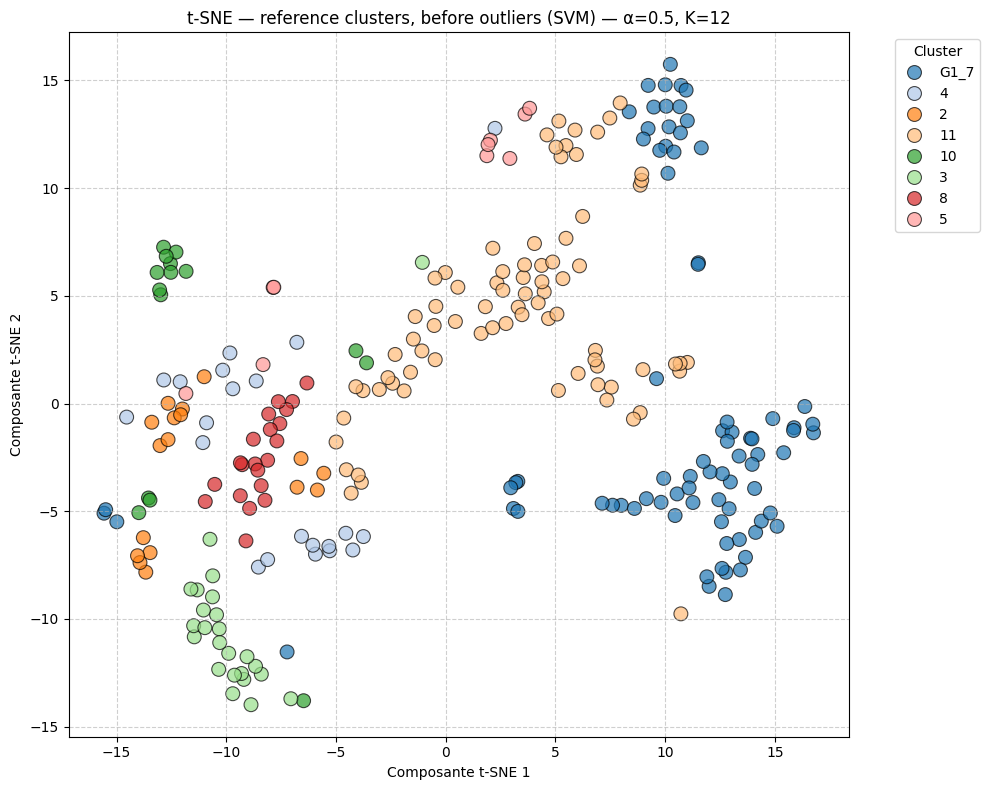

t-SNE saved: tsne_SVM_avant_outliers_alpha0.5_K12.png

Generating the outliers...

=== SMOTE parameters ===
Per-class counts before SMOTE (train split):
Entite
G1_7    56
11      54
3       17
8       15
4       15
2       12
10      10
5        7
Name: count, dtype: int64
Smallest class: 7 samples -> k_neighbors = 5
Per-class counts after SMOTE:
Entite
11      100
2       100
8       100
G1_7    100
3       100
10      100
5       100
4       100
Name: count, dtype: int64


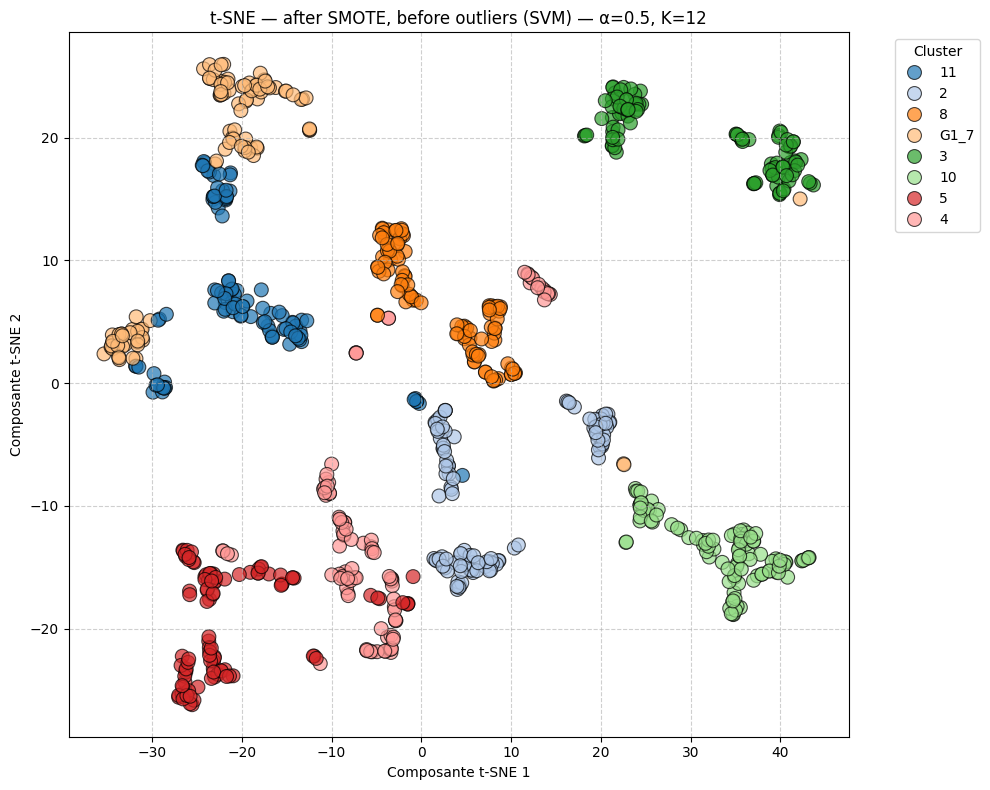

t-SNE saved: tsne_SVM_apres_SMOTE_alpha0.5_K12.png
Per-class counts (train SMOTE + outliers):
Outlier    610
11         100
2          100
8          100
G1_7       100
3          100
10         100
5          100
4          100
Name: count, dtype: int64


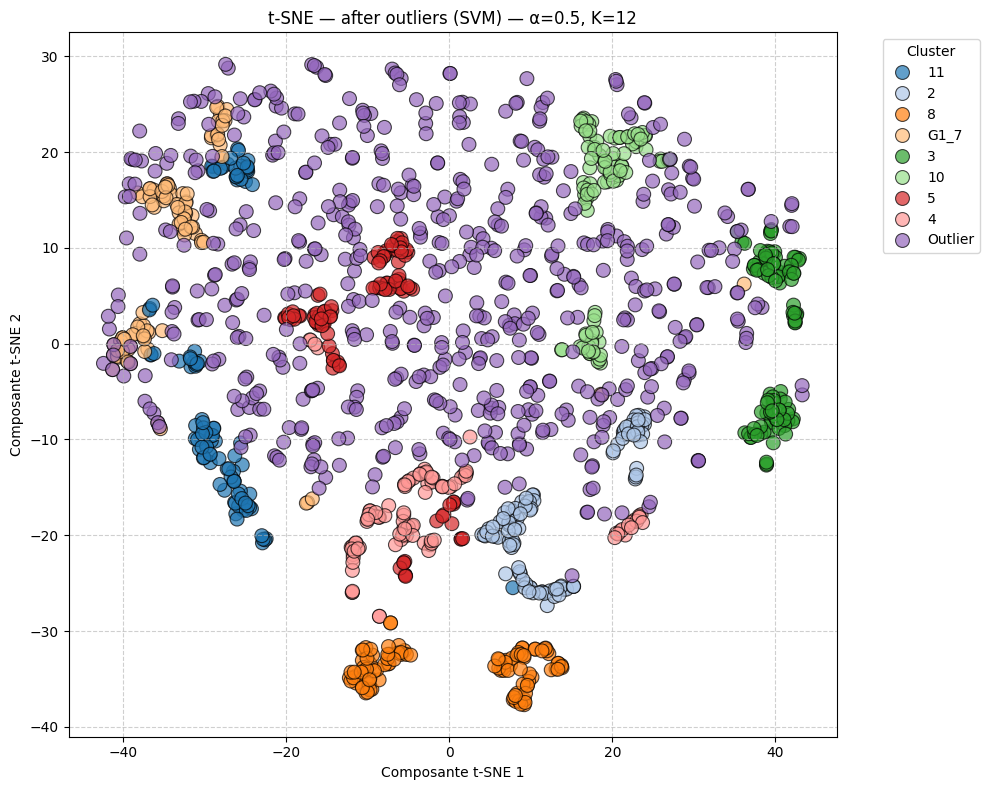

t-SNE saved: tsne_SVM_apres_outliers_alpha0.5_K12.png

--- Hyperparameter optimization (GridSearchCV for SVM) ---
Smallest class in the train set: 100 samples -> cv = 5
Fitting 5 folds for each of 180 candidates, totalling 900 fits
[CV] END ........C=0.1, degree=2, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ........C=0.1, degree=2, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ........C=0.1, degree=2, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ........C=0.1, degree=2, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ........C=0.1, degree=2, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ...........C=0.1, degree=2, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END ...........C=0.1, degree=2, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END ...........C=0.1, degree=2, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END .........C=0.1, degree=2, gamma=auto, kernel=linear; total time=   0.1s
[CV] END ..........C=0.1, degree=2, gam

/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


[CV] END .............C=0.1, degree=4, gamma=10, kernel=poly; total time=   0.0s
[CV] END ..........C=1, degree=2, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ..............C=0.1, degree=3, gamma=1, kernel=poly; total time=   1.5s
[CV] END ..........C=1, degree=2, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ..............C=0.1, degree=3, gamma=1, kernel=poly; total time=   1.6s
[CV] END ..........C=1, degree=2, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ..............C=0.1, degree=4, gamma=10, kernel=rbf; total time=   0.3s
[CV] END ...............C=0.1, degree=4, gamma=1, kernel=rbf; total time=   0.3s
[CV] END ..............C=0.1, degree=4, gamma=10, kernel=rbf; total time=   0.3s
[CV] END ..............C=0.1, degree=4, gamma=10, kernel=rbf; total time=   0.3s
[CV] END ...........C=0.1, degree=3, gamma=10, kernel=linear; total time=   0.1s
[CV] END ..........C=1, degree=2, gamma=scale, kernel=linear; total time=   0.1s
[CV] END .............C=1, d

/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


[CV] END ..............C=1, degree=2, gamma=1, kernel=linear; total time=   0.1s
[CV] END ..............C=1, degree=2, gamma=1, kernel=linear; total time=   0.1s
[CV] END ................C=1, degree=2, gamma=1, kernel=poly; total time=   0.0s
[CV] END ................C=1, degree=2, gamma=1, kernel=poly; total time=   0.1s
[CV] END .............C=1, degree=2, gamma=10, kernel=linear; total time=   0.1s
[CV] END .............C=0.1, degree=3, gamma=10, kernel=poly; total time=   1.6s
[CV] END .............C=1, degree=2, gamma=10, kernel=linear; total time=   0.1s
[CV] END .............C=1, degree=2, gamma=10, kernel=linear; total time=   0.1s
[CV] END .................C=1, degree=2, gamma=1, kernel=rbf; total time=   0.2s
[CV] END .............C=1, degree=2, gamma=10, kernel=linear; total time=   0.1s
[CV] END ...............C=1, degree=2, gamma=10, kernel=poly; total time=   0.0s
[CV] END ...............C=1, degree=2, gamma=10, kernel=poly; total time=   0.1s
[CV] END .................C=

...

  Fold 30/50 done...


/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_p

  Fold 40/50 done...


/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_p

  Fold 50/50 done...
Repeated cross-validation time: 24.15 seconds

Balanced accuracy over 5x10=50 folds: 0.8480 ± 0.0626 (min=0.6844, max=0.9922)
Macro F1-score over 50 folds: 0.8693 ± 0.0592 (min=0.7224, max=0.9781)

Classification report aggregated over all folds (each reference sample appears several times due to the repeats):
              precision    recall  f1-score   support

          10      0.941     0.853     0.895       150
          11      0.946     0.938     0.942       780
           2      0.904     0.994     0.947       170
           3      0.995     0.863     0.924       240
           4      0.841     0.781     0.810       210
           5      0.831     0.540     0.655       100
           8      0.975     0.933     0.954       210
        G1_7      0.967     0.886     0.925       800
     Outlier      0.000     0.000     0.000         0

    accuracy                          0.887      2660
   macro avg      0.822     0.754     0.783      2660
weighted avg     

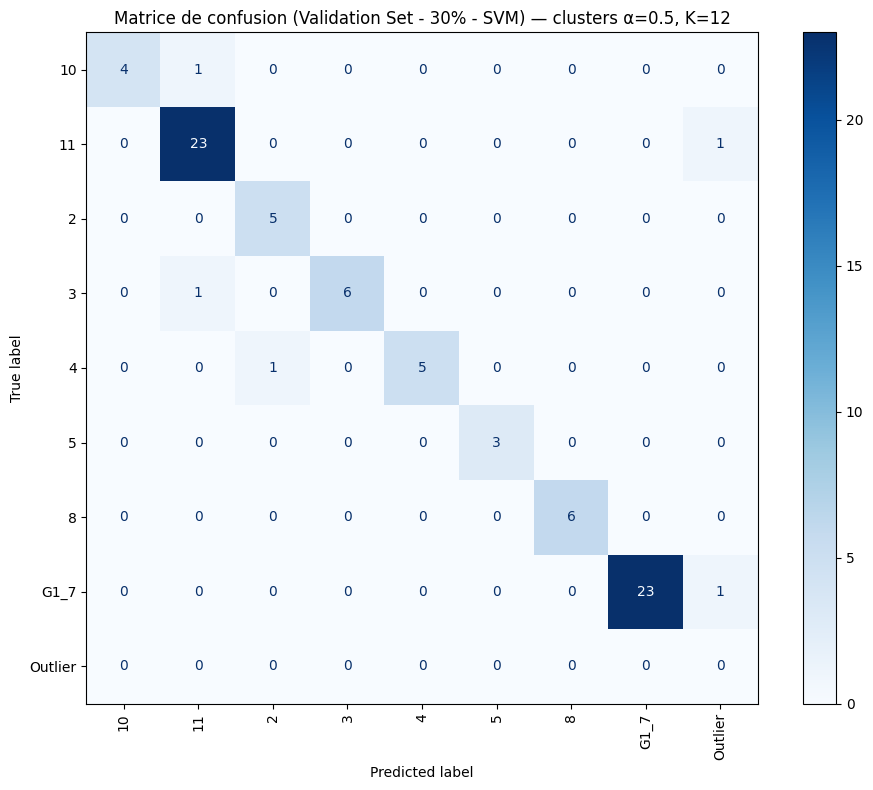


Class-membership probabilities for each object of the test set:

Object: CAP3
Probabilities per class:
  10: 0.0164
  11: 0.1614
  2: 0.0742
  3: 0.2205
  4: 0.1690
  5: 0.0122
  8: 0.0401
  G1_7: 0.0737
  Outlier: 0.2324
  → Predicted cluster: 11 (probability = 0.2324)

Object: CAP3
Probabilities per class:
  10: 0.0174
  11: 0.0487
  2: 0.1251
  3: 0.4406
  4: 0.1420
  5: 0.0121
  8: 0.0153
  G1_7: 0.0400
  Outlier: 0.1588
  → Predicted cluster: 3 (probability = 0.4406)

Object: CAP3
Probabilities per class:
  10: 0.0060
  11: 0.0833
  2: 0.0112
  3: 0.0084
  4: 0.0203
  5: 0.0065
  8: 0.0069
  G1_7: 0.7818
  Outlier: 0.0755
  → Predicted cluster: G1_7 (probability = 0.7818)

Object: CAP3
Probabilities per class:
  10: 0.0071
  11: 0.1041
  2: 0.0118
  3: 0.0105
  4: 0.0216
  5: 0.0077
  8: 0.0072
  G1_7: 0.7228
  Outlier: 0.1071
  → Predicted cluster: G1_7 (probability = 0.7228)

Object: CAP3
Probabilities per class:
  10: 0.0080
  11: 0.0583
  2: 0.0061
  3: 0.0077
  4: 0.0132
  5

In [23]:
import pandas as pd
import numpy as np
import os
import random
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import time
from tabulate import tabulate

pd.set_option('display.max_columns', None)

# ============================================================
# PARAMETERS — choice of the ClustGeo clustering used as reference classes
# ============================================================
ALPHA_CHOISI = 0.5
K_CHOISI = 12
CLUSTERS_CSV = f"clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.csv"
MIN_ECHANTILLONS_PAR_CLUSTER = 10   # same threshold for RF/SVM/NN, for a comparison with a harmonized minimum sample count

DATA_DIR = os.path.expanduser(
    "~/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Projet R FERMAPYR/data:"
)


COLONNES = ["Ce", "Eu", "Hf", "La", "Nb", "Nd", "Sm", "U", "Yb", "Th", "Y"]


# ============================================================
# 1. REFERENCE DATA — labels = ClustGeo clusters
# ============================================================
chemin_csv = os.path.join(DATA_DIR, "FERAPO_FERMAPYR_Data_v2.csv")
try:
    brut = pd.read_csv(chemin_csv, sep=';', engine='python')
    print(f"Reference file loaded: {brut.shape[0]} rows.")
except FileNotFoundError:
    print(f"Error: file not found -> {chemin_csv}")
    exit()

cols_a_majuscule = ["ce", "eu", "hf", "la", "nb", "nd", "sm", "u", "y", "yb",
                    "th", "pr", "gd", "dy", "ho", "er", "tm", "lu", "ba"]
brut.rename(columns={c: c.capitalize() for c in brut.columns if c in cols_a_majuscule},
            inplace=True)

brut = brut[~brut['typology'].isin(TYPOLOGIES_A_EXCLURE)]

try:
    clusters = pd.read_csv(CLUSTERS_CSV, sep=';', encoding='utf-8')
    print(f"Cluster file loaded: {clusters.shape[0]} sites -> {CLUSTERS_CSV}")
except FileNotFoundError:
    print(f"Error: file not found -> {CLUSTERS_CSV}. Rerun step 2 (clustering) of the pipeline first.")
    exit()

# "Groupe" = latest validated manual cluster grouping (e.g. merging
# several ClustGeo clusters into a single group); replaces "Cluster_label"
# (raw ClustGeo partition) as the training class.
site_to_cluster = clusters.set_index("Site")["Groupe"].to_dict()

brut_ref = brut[brut["context_name"].isin(site_to_cluster)].copy()
if brut_ref.empty:
    print("No reference site matches the clusters file. Stopping.")
    exit()

brut_ref_light = brut_ref[["context_name"] + COLONNES].copy()
brut_ref_light["Entite"] = brut_ref_light["context_name"].map(site_to_cluster)
brut_ref_light["Type"] = "ensemble"
brut_ref_light["Site"] = brut_ref_light["context_name"]
brut_ref_light = brut_ref_light.drop(columns="context_name")

print(f"Reference: {brut_ref_light.shape[0]} samples spread across "
      f"{brut_ref_light['Entite'].nunique()} clusters "
      f"(from {brut_ref['context_name'].nunique()} sites out of {len(site_to_cluster)} in {CLUSTERS_CSV}).")

# Exclusion of clusters that are too small
effectifs_clusters = brut_ref_light["Entite"].value_counts()
clusters_exclus = effectifs_clusters[effectifs_clusters < MIN_ECHANTILLONS_PAR_CLUSTER].index.tolist()
if clusters_exclus:
    print(f"Clusters excluded (< {MIN_ECHANTILLONS_PAR_CLUSTER} samples): "
          f"{', '.join(f'{c} ({effectifs_clusters[c]})' for c in clusters_exclus)}")
    brut_ref_light = brut_ref_light[~brut_ref_light["Entite"].isin(clusters_exclus)]
print(f"Reference retained: {brut_ref_light.shape[0]} samples, "
      f"{brut_ref_light['Entite'].nunique()} clusters kept.")

# ============================================================
# 2. ARCHAEOLOGICAL OBJECTS TO CLASSIFY
# ============================================================
objets_list = []
for nom_site, nom_fichier, feuille, col_id in SITES_CONFIG:
    chemin = os.path.join(DATA_DIR, nom_fichier)
    try:
        if feuille is None:
            df = pd.read_csv(chemin, sep=';')
        else:
            df = pd.read_excel(chemin, sheet_name=feuille)
        print(f"[OK] {nom_site}: {df.shape[0]} rows loaded from '{nom_fichier}'")
    except FileNotFoundError:
        print(f"[MISSING] {nom_site}: file not found -> {chemin}")
        continue
    except Exception as e:
        print(f"[ERROR] {nom_site}: {e}")
        continue

    for col in COLONNES:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        else:
            df[col] = np.nan

    if col_id not in df.columns:
        df["_entite"] = nom_site + "_" + df.index.astype(str)
        col_id = "_entite"

    df_light = df[[col_id] + COLONNES].copy()
    df_light = df_light.rename(columns={col_id: "Entite"})
    df_light["Type"] = "objet"
    df_light["Site"] = nom_site
    objets_list.append(df_light)

if not objets_list:
    print("No object file loaded. Only the reference set will be processed.")

# ============================================================
# 3. ASSEMBLY AND LOG RATIOS
# ============================================================
brut2 = pd.concat([brut_ref_light] + objets_list, ignore_index=True)

brut2 = calculer_rapport_log10(brut2, COLONNES, remplacer_zeros_par_nan=False)

colonnes_a_garder = (
    ["Entite", "Type", "Site"]
    + [c for c in brut2.columns if c.startswith("rapport_log10_")]
)
data = brut2[colonnes_a_garder].copy()
data = data.replace([np.inf, -np.inf], np.nan).dropna()

outname = f"data_rapports_log_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.csv"
data.to_csv(outname, sep=';', index=False, encoding="utf-8")
print(f"\nFinal DataFrame: {data.shape[0]} rows after removing NaN/Inf. Saved: {outname}")
print("\nNumber of rows per site and type:")
print(data.groupby(['Site', 'Type']).size().to_string())

# ============================================================
# FROM HERE ON: SVM pipeline.
# The training classes (y_train) are the ClustGeo cluster labels instead
# of the geological regions.
# ============================================================
train_data = data[data["Type"] == "ensemble"]  # Contient les labels dans "Entite" (Cluster 1, Cluster 2, etc.)
test_data = data[data["Type"] == "objet"]      # Contient des noms d'échantillons dans "Entite"

X_train = train_data[[col for col in train_data.columns if col.startswith("rapport_log10_")]]
y_train = train_data["Entite"]

X_test = test_data[[col for col in test_data.columns if col.startswith("rapport_log10_")]]

print("Cluster classes represented in the reference set:", sorted(y_train.unique()))
print(y_train.value_counts())

tracer_tsne(X_train, y_train,
            f"t-SNE — reference clusters, before outliers (SVM) — α={ALPHA_CHOISI}, K={K_CHOISI}",
            f"tsne_SVM_avant_outliers_alpha{ALPHA_CHOISI}_K{K_CHOISI}.png")

# --- 2. Splitting train_data into train (70%) and validation (30%), BEFORE generating the outliers ---
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train,
    test_size=0.3,
    random_state=42,
    stratify=y_train
)

# --- 3. Generating the outliers (natural + synthetic) and SMOTE, from the train split only ---
print("\nGenerating the outliers...")

# Natural outliers on the real data, before SMOTE
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_mask = iso_forest.fit_predict(X_train_split) == -1
X_natural_outliers = X_train_split[outlier_mask]
y_natural_outliers = pd.Series(["Outlier"] * len(X_natural_outliers), index=X_natural_outliers.index)

# SMOTE on the non-Outlier classes
sampling_strategy = {cls: 100 for cls in np.unique(y_train_split) if cls != "Outlier"}
min_classe_train = y_train_split.value_counts().min()
k_neighbors = max(1, min(5, min_classe_train - 1))
print("\n=== SMOTE parameters ===")
print(f"Per-class counts before SMOTE (train split):\n{y_train_split.value_counts()}")
print(f"Smallest class: {min_classe_train} samples -> k_neighbors = {k_neighbors}")
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=k_neighbors)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_split, y_train_split)
print(f"Per-class counts after SMOTE:\n{y_train_resampled.value_counts()}")

tracer_tsne(X_train_resampled, y_train_resampled,
            f"t-SNE — after SMOTE, before outliers (SVM) — α={ALPHA_CHOISI}, K={K_CHOISI}",
            f"tsne_SVM_apres_SMOTE_alpha{ALPHA_CHOISI}_K{K_CHOISI}.png")

outliers = []
n_outliers = 600
unique_classes = [cls for cls in np.unique(y_train_resampled) if cls != "Outlier"]

for _ in range(n_outliers):
    class1, class2 = random.sample(list(unique_classes), 2)
    sample1 = X_train_resampled[y_train_resampled == class1].sample(1).iloc[0]
    sample2 = X_train_resampled[y_train_resampled == class2].sample(1).iloc[0]
    alpha_interp = random.uniform(0.4, 0.6)
    interpolated_sample = sample1 * alpha_interp + sample2 * (1 - alpha_interp)
    noise_factor = random.uniform(0.4, 0.7)
    interpolated_sample += noise_factor * np.random.normal(0, 1, size=interpolated_sample.shape)
    outliers.append(interpolated_sample)

outliers_df = pd.DataFrame(outliers, columns=X_train_resampled.columns)

X_train_with_outliers = pd.concat([X_train_resampled, outliers_df, X_natural_outliers], ignore_index=True)
y_train_with_outliers = pd.concat([
    y_train_resampled,
    pd.Series(["Outlier"] * len(outliers_df)),
    y_natural_outliers
], ignore_index=True)

print(f"Per-class counts (train SMOTE + outliers):\n{pd.Series(y_train_with_outliers).value_counts()}")

tracer_tsne(X_train_with_outliers, y_train_with_outliers,
            f"t-SNE — after outliers (SVM) — α={ALPHA_CHOISI}, K={K_CHOISI}",
            f"tsne_SVM_apres_outliers_alpha{ALPHA_CHOISI}_K{K_CHOISI}.png")

# --- 4. Label encoding (on train + outliers) ---
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_with_outliers)
y_val_encoded = le.transform(y_val)

# Data standardization (CRUCIAL for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_with_outliers)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- 5. Hyperparameter optimization with GridSearchCV for SVM ---
print("\n--- Hyperparameter optimization (GridSearchCV for SVM) ---")

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 1, 10],
    'degree': [2, 3, 4],
}

# Bounded max_iter: with SMOTE, the train set has ~2800 rows (vs ~830
# without), and some combinations (C=100 + poly in particular) can make
# the libsvm SMO solver converge very slowly, blocking the whole search
# for tens of minutes on a single fit. A cap is applied to bound the worst
# case; combinations that have not converged by the limit simply get a
# degraded score (ConvergenceWarning), and are not selected as the best
# candidate anyway.
svm = SVC(probability=True, random_state=42, class_weight=None, max_iter=50000)

# Adaptive cv: GridSearchCV (StratifiedKFold) requires at least `cv`
# samples in the smallest class of the train set; with highly imbalanced
# clusters, the default cv=5 can be too high.
min_classe_train = pd.Series(y_train_encoded).value_counts().min()
cv_folds = max(2, min(5, min_classe_train))
print(f"Smallest class in the train set: {min_classe_train} samples -> cv = {cv_folds}")

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=cv_folds,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

start_time = time.time()
grid_search.fit(X_train_scaled, y_train_encoded)
end_time = time.time()

print(f"\nTemps d'optimisation : {end_time - start_time:.2f} secondes")

print("\n--- Best parameters found ---")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score (F1-weighted): {grid_search.best_score_:.4f}")

# ============================================================
# Robust evaluation via repeated cross-validation (RepeatedStratifiedKFold)
#
# The single 70/30 split has only ~85 samples for 10 classes (down to 2
# for the smallest), so a score on a single draw is very noisy. Here we
# repeat a 5-fold CV ten times (50 folds) on the WHOLE reference set
# (X_train/y_train, without outliers), with the hyperparameters already
# found by GridSearchCV (a nested search would be more rigorous but ~50x
# more costly). As with the main split, the outliers (natural +
# synthetic) are regenerated at each fold, solely from the current
# training fold, so as to never evaluate on synthetic points.
# probability=False in this loop: only the predicted classes are needed
# for the metrics, not the probabilities, which avoids the extra cost of
# Platt calibration (an additional internal 5-fold CV) on already small
# classes.
# ============================================================
print("\n=== Robust evaluation via repeated cross-validation (RepeatedStratifiedKFold) ===")

N_SPLITS_CV = 5
N_REPEATS_CV = 10
rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS_CV, n_repeats=N_REPEATS_CV, random_state=42)

best_svm_params = grid_search.best_params_

cv_balanced_acc = []
cv_macro_f1 = []
all_y_true_cv = []
all_y_pred_cv = []
cv_predictions_detail = []  # une entrée par (répétition, échantillon de validation) : pour comparaison inter-méthodes

start_time_cv = time.time()
for fold_i, (cv_train_idx, cv_val_idx) in enumerate(rskf.split(X_train, y_train)):
    X_fold_train, X_fold_val = X_train.iloc[cv_train_idx], X_train.iloc[cv_val_idx]
    y_fold_train, y_fold_val = y_train.iloc[cv_train_idx], y_train.iloc[cv_val_idx]

    # Natural outliers (Isolation Forest), on the real data of the fold, before SMOTE
    iso_fold = IsolationForest(contamination=0.05, random_state=42)
    fold_outlier_mask = iso_fold.fit_predict(X_fold_train) == -1
    X_fold_natural_outliers = X_fold_train[fold_outlier_mask]
    y_fold_natural_outliers = pd.Series(["Outlier"] * len(X_fold_natural_outliers), index=X_fold_natural_outliers.index)

    # SMOTE on the training fold only
    fold_sampling_strategy = {cls: 100 for cls in np.unique(y_fold_train) if cls != "Outlier"}
    fold_min_classe = y_fold_train.value_counts().min()
    fold_k_neighbors = max(1, min(5, fold_min_classe - 1))
    fold_smote = SMOTE(sampling_strategy=fold_sampling_strategy, random_state=42, k_neighbors=fold_k_neighbors)
    X_fold_resampled, y_fold_resampled = fold_smote.fit_resample(X_fold_train, y_fold_train)

    # Synthetic outliers by interpolation, from the fold's SMOTE data
    fold_outliers = []
    fold_unique_classes = [cls for cls in np.unique(y_fold_resampled) if cls != "Outlier"]
    for _ in range(n_outliers):
        class1, class2 = random.sample(list(fold_unique_classes), 2)
        sample1 = X_fold_resampled[y_fold_resampled == class1].sample(1).iloc[0]
        sample2 = X_fold_resampled[y_fold_resampled == class2].sample(1).iloc[0]
        alpha_interp = random.uniform(0.4, 0.6)
        interpolated_sample = sample1 * alpha_interp + sample2 * (1 - alpha_interp)
        noise_factor = random.uniform(0.4, 0.7)
        interpolated_sample += noise_factor * np.random.normal(0, 1, size=interpolated_sample.shape)
        fold_outliers.append(interpolated_sample)
    fold_outliers_df = pd.DataFrame(fold_outliers, columns=X_fold_resampled.columns)

    X_fold_train_aug = pd.concat([X_fold_resampled, fold_outliers_df, X_fold_natural_outliers], ignore_index=True)
    y_fold_train_aug = pd.concat([
        y_fold_resampled,
        pd.Series(["Outlier"] * len(fold_outliers_df)),
        y_fold_natural_outliers
    ], ignore_index=True)

    fold_label_encoder = LabelEncoder()
    y_fold_train_encoded = fold_label_encoder.fit_transform(y_fold_train_aug)
    y_fold_val_encoded = fold_label_encoder.transform(y_fold_val)

    fold_scaler = StandardScaler()
    X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train_aug)
    X_fold_val_scaled = fold_scaler.transform(X_fold_val)

    fold_model = SVC(probability=False, random_state=42, max_iter=50000, **best_svm_params)
    fold_model.fit(X_fold_train_scaled, y_fold_train_encoded)
    y_fold_pred_encoded = fold_model.predict(X_fold_val_scaled)
    y_fold_pred_labels = fold_label_encoder.inverse_transform(y_fold_pred_encoded)

    # Per-sample validation detail (site + true provenance + predicted
    # label — no probability, probability=False above), with the repeat
    # number — used afterwards to compare RF/SVM/NN on far more cases
    # than a single 70/30 split.
    repeat_idx = fold_i // N_SPLITS_CV
    sites_fold_val = train_data.loc[X_fold_val.index, "Site"]
    for row_i, idx in enumerate(X_fold_val.index):
        cv_predictions_detail.append({
            "Repeat": repeat_idx,
            "Site": sites_fold_val.loc[idx],
            "Vraie_provenance": y_fold_val.loc[idx],
            "Provenance_predite_echantillon": y_fold_pred_labels[row_i],
        })

    cv_balanced_acc.append(balanced_accuracy_score(y_fold_val_encoded, y_fold_pred_encoded))
    # labels= restricted to the classes actually present in y_fold_val (never "Outlier",
    # which is only added to the train set): without this, a false-positive "Outlier" on a
    # fold adds a phantom class at F1=0 to the macro average, diluting the score in a way
    # that is not consistent from fold to fold (unlike balanced_accuracy_score, which already
    # excludes it on its own).
    cv_macro_f1.append(f1_score(y_fold_val_encoded, y_fold_pred_encoded, labels=np.unique(y_fold_val_encoded), average='macro', zero_division=0))

    all_y_true_cv.extend(fold_label_encoder.inverse_transform(y_fold_val_encoded))
    all_y_pred_cv.extend(fold_label_encoder.inverse_transform(y_fold_pred_encoded))

    if (fold_i + 1) % 10 == 0:
        print(f"  Fold {fold_i + 1}/{N_SPLITS_CV * N_REPEATS_CV} done...")

cv_balanced_acc = np.array(cv_balanced_acc)
cv_macro_f1 = np.array(cv_macro_f1)
print(f"Repeated cross-validation time: {time.time() - start_time_cv:.2f} seconds")

print(f"\nBalanced accuracy over {N_SPLITS_CV}x{N_REPEATS_CV}={len(cv_balanced_acc)} folds: "
      f"{cv_balanced_acc.mean():.4f} ± {cv_balanced_acc.std():.4f} "
      f"(min={cv_balanced_acc.min():.4f}, max={cv_balanced_acc.max():.4f})")
print(f"Macro F1-score over {len(cv_macro_f1)} folds: "
      f"{cv_macro_f1.mean():.4f} ± {cv_macro_f1.std():.4f} "
      f"(min={cv_macro_f1.min():.4f}, max={cv_macro_f1.max():.4f})")

print("\nClassification report aggregated over all folds "
      "(each reference sample appears several times due to the repeats):")
print(classification_report(all_y_true_cv, all_y_pred_cv, digits=3, zero_division=0))

# === Export of the CV validation detail, aggregated by (repeat, site) ===
# No probability available (probability=False in the loop, for speed):
# the predicted provenance per site is the MAJORITY label among that
# site's samples in this fold/repeat (mode; in case of a tie, the first
# encountered value is kept).
cv_detail_df = pd.DataFrame(cv_predictions_detail)


def _mode_ou_premier(s):
    return s.mode().iloc[0]


agg_site = cv_detail_df.groupby(["Repeat", "Site"])
provenance_predite_cv = agg_site["Provenance_predite_echantillon"].agg(_mode_ou_premier)
nb_echantillons_cv = agg_site.size()
vraie_provenance_cv = agg_site["Vraie_provenance"].first()

resultat_cv = pd.DataFrame({
    "Nb_echantillons_val": nb_echantillons_cv,
    "Vraie_provenance": vraie_provenance_cv,
    "Provenance_predite": provenance_predite_cv,
}).reset_index()

excel_filename = f"SVM_validation_CV_par_site_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
resultat_cv.to_excel(excel_filename, sheet_name="Validation CV par site", index=False)
print(f"\nRepeated cross-validation detail, by (repeat, site), saved: {excel_filename} "
      f"({resultat_cv.shape[0]} rows, {resultat_cv['Site'].nunique()} distinct sites)")

# --- 5. Training the final model with the best parameters ---
best_model = grid_search.best_estimator_
best_model.fit(X_train_scaled, y_train_encoded)

# --- 6. Predictions on the validation set ---
y_val_pred = best_model.predict(X_val_scaled)
y_val_proba = best_model.predict_proba(X_val_scaled)

# === Export of the validation predictions, aggregated by site (true
# provenance known) — for empirical cross-method comparison ===
sites_val = train_data.loc[X_val.index, "Site"]
df_val_detail = pd.DataFrame(
    y_val_proba,
    columns=le.classes_,
    index=X_val.index
)
df_val_detail["Site"] = sites_val
df_val_detail["Vraie_provenance"] = y_val

proba_val_par_site = df_val_detail.groupby("Site")[list(le.classes_)].mean()
provenance_predite_val = proba_val_par_site.idxmax(axis=1)
nb_echantillons_val_par_site = df_val_detail.groupby("Site").size()
vraie_provenance_val = df_val_detail.groupby("Site")["Vraie_provenance"].first()

proba_val_par_site.insert(0, "Nb_echantillons_val", nb_echantillons_val_par_site)
proba_val_par_site.insert(1, "Vraie_provenance", vraie_provenance_val)
proba_val_par_site.insert(2, "Provenance_predite", provenance_predite_val)

excel_filename = f"SVM_validation_par_site_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
proba_val_par_site.to_excel(excel_filename, sheet_name="Validation par site")
print(f"\nValidation by site (for cross-method comparison) saved: {excel_filename} "
      f"({proba_val_par_site.shape[0]} sites)")

# --- 7. Computing the metrics ---
accuracy = accuracy_score(y_val_encoded, y_val_pred)
precision = precision_score(y_val_encoded, y_val_pred, average='weighted', zero_division=0)
recall = recall_score(y_val_encoded, y_val_pred, average='weighted', zero_division=0)
f1 = f1_score(y_val_encoded, y_val_pred, average='weighted', zero_division=0)

print("\n--- Metrics on the validation set (30%) ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-score (weighted): {f1:.4f}")

# "Outlier" never appears in y_val (added only after the split) and may
# never be predicted on real samples: the confusion matrix can therefore
# be smaller than the total number of classes. labels/target_names/
# display_labels are restricted to the classes actually present, to
# avoid a dimension mismatch.
all_val_classes = np.unique(np.concatenate([y_val_encoded, y_val_pred]))
val_class_names = [le.classes_[i] for i in sorted(all_val_classes)]

# --- 8. Detailed classification report ---
print("\nRapport de classification (Validation Set):")
print(classification_report(y_val_encoded, y_val_pred, labels=all_val_classes, target_names=val_class_names, zero_division=0))

# --- 9. Confusion matrix (display and save as image) ---
conf_matrix_val = confusion_matrix(y_val_encoded, y_val_pred, labels=all_val_classes)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix_val,
    display_labels=val_class_names
)
disp.plot(cmap="Blues", xticks_rotation="vertical", values_format='d', ax=plt.gca())
plt.title(f"Matrice de confusion (Validation Set - 30% - SVM) — clusters α={ALPHA_CHOISI}, K={K_CHOISI}")
plt.tight_layout()

conf_matrix_filename = f"matrice_confusion_validation_SVM_SMOTE100_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.png"
plt.savefig(conf_matrix_filename, dpi=300, bbox_inches='tight')
plt.show()

# --- 10. Predictions on the test set (without labels) ---
y_test_pred = best_model.predict(X_test_scaled)
y_test_proba = best_model.predict_proba(X_test_scaled)

test_obj_names = test_data["Entite"]

# === Displaying the probabilities per object ===
print("\nClass-membership probabilities for each object of the test set:")
for i, obj_name in enumerate(test_obj_names):
    print(f"\nObject: {obj_name}")
    print("Probabilities per class:")
    for class_idx, class_name in enumerate(le.classes_):
        proba = y_test_proba[i, class_idx]
        print(f"  {class_name}: {proba:.4f}")
    predicted_class = le.inverse_transform([y_test_pred[i]])[0]
    max_prob = np.max(y_test_proba[i])
    print(f"  → Predicted cluster: {predicted_class} (probability = {max_prob:.4f})")

# === Probability heatmap, object by object ===
print("\nProbability heatmap, object by object...")
unique_test_objects = test_obj_names.unique()
for obj_name in unique_test_objects:
    mask = (test_obj_names == obj_name).values
    proba_obj = y_test_proba[mask]
    sample_names = [f"Échantillon {i + 1}" for i in range(proba_obj.shape[0])]

    plt.figure(figsize=(12, max(4, 0.5 * len(sample_names))))
    sns.heatmap(
        proba_obj,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        xticklabels=le.classes_,
        yticklabels=sample_names,
        vmin=0,
        vmax=1
    )
    plt.title(f"Heatmap des probabilités de cluster pour l'objet {obj_name}")
    plt.xlabel("Cluster")
    plt.ylabel("Échantillons")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    os.makedirs("heatmaps_SVM", exist_ok=True)
    nom_heatmap = f"heatmaps_SVM/heatmap_SVM_{str(obj_name).replace(' ', '_')}_alpha{ALPHA_CHOISI}_K{K_CHOISI}.png"
    plt.savefig(nom_heatmap, dpi=120, bbox_inches='tight')
    plt.close()

# === Table of AVERAGE probabilities per object (predicted provenance) ===
# One row per object (its repeated samples averaged), instead of nothing
# (until now SVM exported no file, only the console print per sample
# above) — homogenized with RF/XGBoost/NN.
print("\nComputing the average probabilities per object...")
proba_par_echantillon = pd.DataFrame(
    y_test_proba,
    columns=le.classes_,
    index=test_obj_names.values
)
proba_moyenne_par_objet = proba_par_echantillon.groupby(level=0).mean()
groupe_predit_par_objet = proba_moyenne_par_objet.idxmax(axis=1)
nb_echantillons_par_objet = test_obj_names.value_counts()

proba_moyenne_par_objet.insert(0, "Nb_echantillons", nb_echantillons_par_objet.reindex(proba_moyenne_par_objet.index))
proba_moyenne_par_objet.insert(1, "Provenance_predite", groupe_predit_par_objet)

print("\nAverage class-membership probabilities per group, per object (predicted provenance):")
print(tabulate(proba_moyenne_par_objet, headers='keys', tablefmt='grid', floatfmt=".4f"))

# Explicit filename specific to SVM (prefix "SVM_"), so it can coexist
# without collision with the equivalent tables from RF/NN/XGBoost.
excel_filename = f"SVM_probabilites_moyennes_par_objet_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
proba_moyenne_par_objet.to_excel(excel_filename, sheet_name="Probabilités moyennes")
print(f"\nThe table of average probabilities per object has been saved to: {excel_filename}")

# === Per-sample detail (predicted class + probabilities) — Excel export
# only, without console printing (can reach several hundred rows) ===
results_df = pd.DataFrame({
    "Objet": test_obj_names,
    "Cluster prédit": le.inverse_transform(y_test_pred),
    **{f"Proba_{cls}": y_test_proba[:, i] for i, cls in enumerate(le.classes_)}
})

excel_filename = f"SVM_detail_par_echantillon_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
results_df.to_excel(excel_filename, sheet_name="Prédictions")
print(f"\nThe per-sample detail ({results_df.shape[0]} rows) has been saved to: {excel_filename}")

print("\n✅ Processing finished.")


## Step 10 — Neural network model

Neural network on the ClustGeo clusters (classes = "Groupe" column of
clusters_alpha{a}_K{k}.csv). Each individual reference sample (column
'context_name' of FERAPO_FERMAPYR_Data_v2.csv) is attached to its site's
cluster.

Evaluation by a single 70/30 split AND by repeated cross-validation
(RepeatedStratifiedKFold, 5 folds x 10 repeats = 50 evaluations). The
hyperparameter search (Keras tuner, 100 trials x 50 epochs) is NOT
repeated at each fold — that would be ~50x more costly — only the model
weights (same hyperparameters) are retrained at each fold, via
tuner.hypermodel.build(best_hyperparameters). SMOTE and the outliers
(natural via Isolation Forest, contamination=5%, and synthetic by
interpolation) are regenerated at each fold, solely from the current
training fold, never on the validation split/fold. The early stopping
inside a fold uses validation_split=0.1 taken from the fold's train set.

MIN_ECHANTILLONS_PAR_CLUSTER = 10 (ClustGeo clusters 1 and 7 merged into
the "G1_7" group). The probabilities and predictions are exported at the
sample level, averaged per object, for the validation split, and for each
fold of the repeated cross-validation, aggregated by reference site.

Technical note: kt.RandomSearch is called with overwrite=True — without
this parameter, Keras Tuner reloads the cache of a previous run sharing
the same directory/project_name (which depends only on
ALPHA_CHOISI/K_CHOISI); if the number of classes has changed in the
meantime, the saved model's output layer no longer matches the current
number of classes, which can cause a crash or, worse, a silent reload
reusing the hyperparameters of an entirely different set of classes.


Trial 100 Complete [00h 00m 09s]
val_accuracy: 0.9187500178813934

Best val_accuracy So Far: 0.96875
Total elapsed time: 00h 14m 45s

Best hyperparameters found:
units_1: 160
activation_1: relu
l2_reg_1: 1.792030664209247e-05
dropout_1: 0.4
units_2: 96
activation_2: relu
l2_reg_2: 0.006599323706446486
dropout_2: 0.30000000000000004
optimizer: sgd
learning_rate: 0.000768513725396424

=== Robust evaluation via repeated cross-validation (RepeatedStratifiedKFold) ===


/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  Fold 5/50 done...
  Fold 10/50 done...
  Fold 15/50 done...
  Fold 20/50 done...
  Fold 25/50 done...


/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  Fold 30/50 done...
  Fold 35/50 done...


...

  Fold 40/50 done...


/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  Fold 45/50 done...


/Users/Dillmann2/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Python bayesien/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  Fold 50/50 done...
Repeated cross-validation time: 270.82 seconds

Balanced accuracy over 5x10=50 folds: 0.9049 ± 0.0451 (min=0.8021, max=1.0000)
Macro F1-score over 50 folds: 0.9032 ± 0.0425 (min=0.8178, max=1.0000)

Classification report aggregated over all folds (each reference sample appears several times due to the repeats):
              precision    recall  f1-score   support

          10      0.923     0.873     0.897       150
          11      0.947     0.965     0.956       780
           2      0.883     0.976     0.927       170
           3      0.954     0.942     0.948       240
           4      0.833     0.852     0.842       210
           5      0.753     0.730     0.741       100
           8      0.985     0.957     0.971       210
        G1_7      0.973     0.944     0.958       800
     Outlier      0.000     0.000     0.000         0

    accuracy                          0.934      2660
   macro avg      0.806     0.804     0.805      2660
weighted avg    

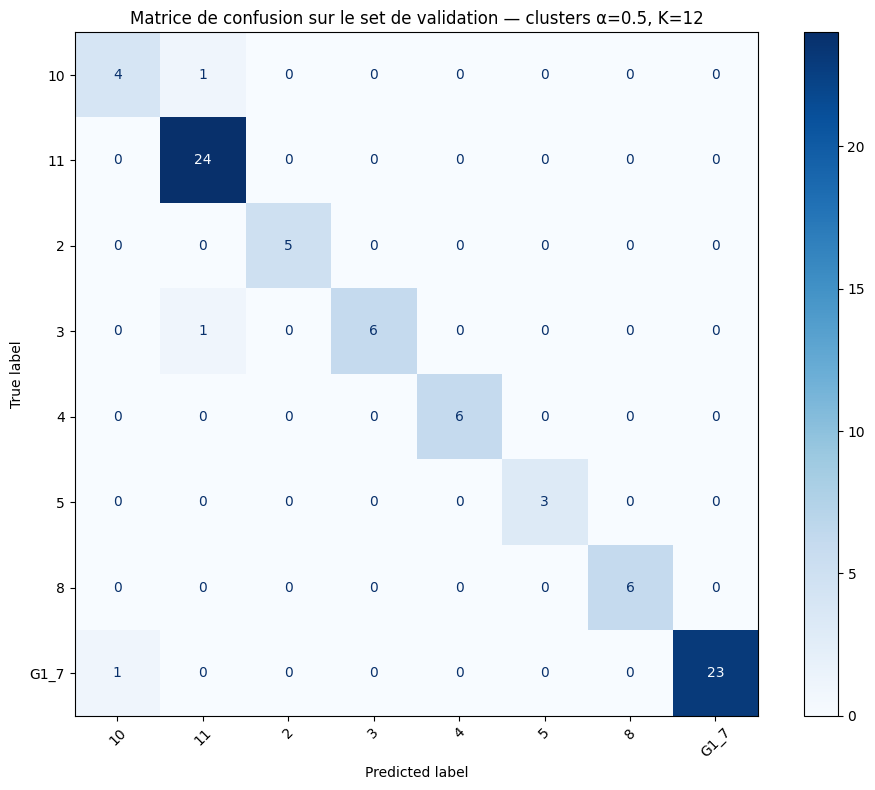


Rapport de classification :
              precision    recall  f1-score   support

          10      0.800     0.800     0.800         5
          11      0.923     1.000     0.960        24
           2      1.000     1.000     1.000         5
           3      1.000     0.857     0.923         7
           4      1.000     1.000     1.000         6
           5      1.000     1.000     1.000         3
           8      1.000     1.000     1.000         6
        G1_7      1.000     0.958     0.979        24

    accuracy                          0.963        80
   macro avg      0.965     0.952     0.958        80
weighted avg      0.964     0.963     0.962        80

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step
Object 1:
  Initial membership: CAP3
  Predicted cluster: 3
  Probability: 0.48
  ⚠️ Probability too low: this sample is probably an outlier.

Object 2:
  Initial membership: CAP3
  Predicted cluster: 3
  Probability: 0.40
  ⚠️ Probability too low: this sample is probably an out

In [24]:
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
import keras_tuner as kt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from tabulate import tabulate
import time

pd.set_option('display.max_columns', None)

# ============================================================
# PARAMETERS — choice of the ClustGeo clustering used as reference classes
# ============================================================
ALPHA_CHOISI = 0.5
K_CHOISI = 12
CLUSTERS_CSV = f"clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.csv"
MIN_ECHANTILLONS_PAR_CLUSTER = 10   # same threshold for RF/SVM/NN, for a comparison with a harmonized minimum sample count

DATA_DIR = os.path.expanduser(
    "~/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Projet R FERMAPYR/data:"
)


COLONNES = ["Ce", "Eu", "Hf", "La", "Nb", "Nd", "Sm", "U", "Yb", "Th", "Y"]


# ============================================================
# 1. REFERENCE DATA — labels = ClustGeo clusters
# ============================================================
chemin_csv = os.path.join(DATA_DIR, "FERAPO_FERMAPYR_Data_v2.csv")
try:
    brut = pd.read_csv(chemin_csv, sep=';', engine='python')
    print(f"Reference file loaded: {brut.shape[0]} rows.")
except FileNotFoundError:
    print(f"Error: file not found -> {chemin_csv}")
    exit()

cols_a_majuscule = ["ce", "eu", "hf", "la", "nb", "nd", "sm", "u", "y", "yb",
                    "th", "pr", "gd", "dy", "ho", "er", "tm", "lu", "ba"]
brut.rename(columns={c: c.capitalize() for c in brut.columns if c in cols_a_majuscule},
            inplace=True)

brut = brut[~brut['typology'].isin(TYPOLOGIES_A_EXCLURE)]

try:
    clusters = pd.read_csv(CLUSTERS_CSV, sep=';', encoding='utf-8')
    print(f"Cluster file loaded: {clusters.shape[0]} sites -> {CLUSTERS_CSV}")
except FileNotFoundError:
    print(f"Error: file not found -> {CLUSTERS_CSV}. Rerun step 2 (clustering) of the pipeline first.")
    exit()

# "Groupe" = latest validated manual cluster grouping (e.g. merging
# several ClustGeo clusters into a single group); replaces "Cluster_label"
# (raw ClustGeo partition) as the training class.
site_to_cluster = clusters.set_index("Site")["Groupe"].to_dict()

brut_ref = brut[brut["context_name"].isin(site_to_cluster)].copy()
if brut_ref.empty:
    print("No reference site matches the clusters file. Stopping.")
    exit()

brut_ref_light = brut_ref[["context_name"] + COLONNES].copy()
brut_ref_light["Entite"] = brut_ref_light["context_name"].map(site_to_cluster)
brut_ref_light["Type"] = "ensemble"
brut_ref_light["Site"] = brut_ref_light["context_name"]
brut_ref_light = brut_ref_light.drop(columns="context_name")

print(f"Reference: {brut_ref_light.shape[0]} samples spread across "
      f"{brut_ref_light['Entite'].nunique()} clusters "
      f"(from {brut_ref['context_name'].nunique()} sites out of {len(site_to_cluster)} in {CLUSTERS_CSV}).")

# Exclusion of clusters that are too small (required by the stratified split + SMOTE)
effectifs_clusters = brut_ref_light["Entite"].value_counts()
clusters_exclus = effectifs_clusters[effectifs_clusters < MIN_ECHANTILLONS_PAR_CLUSTER].index.tolist()
if clusters_exclus:
    print(f"Clusters excluded (< {MIN_ECHANTILLONS_PAR_CLUSTER} samples): "
          f"{', '.join(f'{c} ({effectifs_clusters[c]})' for c in clusters_exclus)}")
    brut_ref_light = brut_ref_light[~brut_ref_light["Entite"].isin(clusters_exclus)]
print(f"Reference retained: {brut_ref_light.shape[0]} samples, "
      f"{brut_ref_light['Entite'].nunique()} clusters kept.")

# ============================================================
# 2. ARCHAEOLOGICAL OBJECTS TO CLASSIFY
# ============================================================
objets_list = []
for nom_site, nom_fichier, feuille, col_id in SITES_CONFIG:
    chemin = os.path.join(DATA_DIR, nom_fichier)
    try:
        if feuille is None:
            df = pd.read_csv(chemin, sep=';')
        else:
            df = pd.read_excel(chemin, sheet_name=feuille)
        print(f"[OK] {nom_site}: {df.shape[0]} rows loaded from '{nom_fichier}'")
    except FileNotFoundError:
        print(f"[MISSING] {nom_site}: file not found -> {chemin}")
        continue
    except Exception as e:
        print(f"[ERROR] {nom_site}: {e}")
        continue

    for col in COLONNES:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        else:
            df[col] = np.nan

    if col_id not in df.columns:
        df["_entite"] = nom_site + "_" + df.index.astype(str)
        col_id = "_entite"

    df_light = df[[col_id] + COLONNES].copy()
    df_light = df_light.rename(columns={col_id: "Entite"})
    df_light["Type"] = "objet"
    df_light["Site"] = nom_site
    objets_list.append(df_light)

if not objets_list:
    print("No object file loaded. Only the reference set will be processed.")

# ============================================================
# 3. ASSEMBLY AND LOG RATIOS
# ============================================================
brut2 = pd.concat([brut_ref_light] + objets_list, ignore_index=True)

brut2 = calculer_rapport_log10(brut2, COLONNES, remplacer_zeros_par_nan=False)

colonnes_a_garder = (
    ["Entite", "Type", "Site"]
    + [c for c in brut2.columns if c.startswith("rapport_log10_")]
)
data = brut2[colonnes_a_garder].copy()
data = data.replace([np.inf, -np.inf], np.nan).dropna()

outname = f"data_rapports_log_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.csv"
data.to_csv(outname, sep=';', index=False, encoding="utf-8")
print(f"\nFinal DataFrame: {data.shape[0]} rows after removing NaN/Inf. Saved: {outname}")
print("\nNumber of rows per site and type:")
print(data.groupby(['Site', 'Type']).size().to_string())

# ============================================================
# FROM HERE ON: neural network pipeline.
# The training classes (y_train) are the ClustGeo cluster labels instead
# of the geological regions.
# ============================================================
train_data = data[data["Type"] == "ensemble"]
test_data = data[data["Type"] == "objet"]

X_train = train_data[[col for col in train_data.columns if col.startswith("rapport_log10_")]]
y_train = train_data["Entite"]

print("Colonnes de X_train :", X_train.columns)
print("Cluster classes represented in the reference set:", sorted(y_train.unique()))
print(y_train.value_counts())

tracer_tsne(X_train, y_train,
            f"t-SNE — reference clusters, before outliers (NN) — α={ALPHA_CHOISI}, K={K_CHOISI}",
            f"tsne_NN_avant_outliers_alpha{ALPHA_CHOISI}_K{K_CHOISI}.png")

# === 1. Splitting train/val (BEFORE SMOTE and outliers) ===
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42, stratify=y_train
)

# === 2. Applying SMOTE to the training set ===
sampling_strategy = {cls: 200 for cls in np.unique(y_train_split) if cls != "Outlier"}
min_classe_train = y_train_split.value_counts().min()
k_neighbors = max(1, min(5, min_classe_train - 1))
print("\n=== SMOTE parameters ===")
print(f"Per-class counts before SMOTE (train split):\n{y_train_split.value_counts()}")
print(f"Smallest class: {min_classe_train} samples -> k_neighbors = {k_neighbors}")
print(f"sampling_strategy (target count per class): {sampling_strategy}")
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=k_neighbors)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_split, y_train_split)
print(f"Per-class counts after SMOTE:\n{y_train_resampled.value_counts()}")

tracer_tsne(X_train_resampled, y_train_resampled,
            f"t-SNE — after SMOTE, before outliers (NN) — α={ALPHA_CHOISI}, K={K_CHOISI}",
            f"tsne_NN_apres_SMOTE_alpha{ALPHA_CHOISI}_K{K_CHOISI}.png")

# === 2bis. Natural outliers (Isolation Forest), on the real data of the
# train split, before SMOTE: detects the real reference samples whose
# geochemical signature is statistically atypical (contamination=5%), and
# relabels them "Outlier" rather than forcing them into their original
# group. Complements the synthetic outliers below (which simulate
# hypothetical provenances absent from the reference set, rather than
# flagging real samples that are already atypical). ===
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_mask = iso_forest.fit_predict(X_train_split) == -1
X_natural_outliers = X_train_split[outlier_mask]
y_natural_outliers = pd.Series(["Outlier"] * len(X_natural_outliers), index=X_natural_outliers.index)
print(f"Natural outliers detected (Isolation Forest, contamination=5%): {len(X_natural_outliers)}")

# === 3. Generating outliers by interpolation between classes ===
from scipy.interpolate import interp1d
import random

outliers = []
n_outliers = 600

unique_classes = y_train_resampled.unique()
n_classes = len(unique_classes)

for _ in range(n_outliers):
    class1, class2 = random.sample(list(unique_classes), 2)

    sample1 = X_train_resampled[y_train_resampled == class1].sample(1).iloc[0]
    sample2 = X_train_resampled[y_train_resampled == class2].sample(1).iloc[0]

    alpha = random.uniform(0.4, 0.6)
    interpolated_sample = sample1 * alpha + sample2 * (1 - alpha)

    noise_factor = random.uniform(0.4, 0.7)
    interpolated_sample += noise_factor * np.random.normal(0, 1, size=interpolated_sample.shape)

    outliers.append(interpolated_sample)

outliers_df = pd.DataFrame(outliers, columns=X_train_resampled.columns)
X_train_with_outliers = pd.concat([X_train_resampled, outliers_df, X_natural_outliers], ignore_index=True)
y_train_with_outliers = pd.concat([
    y_train_resampled,
    pd.Series(["Outlier"] * len(outliers_df)),
    y_natural_outliers
], ignore_index=True)

tracer_tsne(X_train_with_outliers, y_train_with_outliers,
            f"t-SNE — after outliers (NN) — α={ALPHA_CHOISI}, K={K_CHOISI}",
            f"tsne_NN_apres_outliers_alpha{ALPHA_CHOISI}_K{K_CHOISI}.png")

# === 4. Label encoding ===
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_with_outliers)
y_val_encoded = label_encoder.transform(y_val)

# === 5. Normalisation ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_with_outliers)
X_val_scaled = scaler.transform(X_val)
X_test = test_data[[col for col in test_data.columns if col.startswith("rapport_log10_")]]
X_test_scaled = scaler.transform(X_test)

# === 6. Preparing the categorical data ===
n_classes_total = len(label_encoder.classes_)
y_train_categorical = to_categorical(y_train_encoded, num_classes=n_classes_total)
y_val_categorical = to_categorical(y_val_encoded, num_classes=n_classes_total)

print("Unique classes in the data:", label_encoder.classes_)
print("Class distribution after SMOTE and outliers:")
print(pd.Series(y_train_with_outliers).value_counts())
print("Data shapes:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"y_train_categorical: {y_train_categorical.shape}")
print(f"X_val_scaled: {X_val_scaled.shape}")
print(f"y_val_categorical: {y_val_categorical.shape}")

start_time = time.time()

def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train_scaled.shape[1],)))

    model.add(Dense(
        units=hp.Int('units_1', min_value=64, max_value=256, step=32),
        activation=hp.Choice('activation_1', ['relu', 'tanh', 'elu']),
        kernel_regularizer=l2(hp.Float('l2_reg_1', min_value=1e-5, max_value=1e-2, sampling='log'))
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    model.add(Dense(
        units=hp.Int('units_2', min_value=32, max_value=128, step=32),
        activation=hp.Choice('activation_2', ['relu', 'tanh', 'elu']),
        kernel_regularizer=l2(hp.Float('l2_reg_2', min_value=1e-5, max_value=1e-2, sampling='log'))
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))

    model.add(Dense(len(label_encoder.classes_), activation='softmax'))

    optimizer = hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop'])
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=100,
    executions_per_trial=2,
    directory='keras_tuner_dir',
    project_name=f'fermapyr_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}',
    overwrite=True  # without this, Keras Tuner reloads the cache of a
    # previous run (same directory/project_name, since ALPHA_CHOISI/K_CHOISI
    # don't change from one test to another): if the number of classes has
    # changed in the meantime (cluster regrouping, different
    # MIN_ECHANTILLONS_PAR_CLUSTER threshold...), the saved model's output
    # layer no longer matches -> ValueError on loading (observed), or worse,
    # a SUCCESSFUL but silent reload reusing the hyperparameters of an
    # entirely different set of classes without any warning.
)

print("Hyperparameter optimization in progress...")
tuner.search(
    X_train_scaled,
    y_train_categorical,
    validation_data=(X_val_scaled, y_val_categorical),
    epochs=50,
    batch_size=16,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters()[0]

print("\nBest hyperparameters found:")
for param, value in best_hyperparameters.values.items():
    print(f"{param}: {value}")

# ============================================================
# Robust evaluation via repeated cross-validation (RepeatedStratifiedKFold)
# ============================================================
# Same conditions as the other 4 methods: 5-fold CV repeated 10 times
# (50 folds) on the WHOLE reference set (X_train/y_train), with the
# hyperparameters already found by the tuner (a nested search would be
# ~50x more costly). SMOTE and the outliers are regenerated at each fold,
# solely from the current training fold. validation_split=0.1 (taken from
# the fold's train set) is used for the intra-fold early stopping, never
# touching the validation fold used for the score.
# ============================================================
print("\n=== Robust evaluation via repeated cross-validation (RepeatedStratifiedKFold) ===")

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import balanced_accuracy_score, f1_score

N_SPLITS_CV = 5
N_REPEATS_CV = 10
rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS_CV, n_repeats=N_REPEATS_CV, random_state=42)

cv_balanced_acc = []
cv_macro_f1 = []
all_y_true_cv = []
all_y_pred_cv = []
cv_predictions_detail = []  # une entrée par (répétition, échantillon de validation) : pour comparaison inter-méthodes

start_time_cv = time.time()
for fold_i, (cv_train_idx, cv_val_idx) in enumerate(rskf.split(X_train, y_train)):
    X_fold_train, X_fold_val = X_train.iloc[cv_train_idx], X_train.iloc[cv_val_idx]
    y_fold_train, y_fold_val = y_train.iloc[cv_train_idx], y_train.iloc[cv_val_idx]

    # SMOTE on the training fold only
    fold_sampling_strategy = {cls: 200 for cls in np.unique(y_fold_train) if cls != "Outlier"}
    fold_min_classe = y_fold_train.value_counts().min()
    fold_k_neighbors = max(1, min(5, fold_min_classe - 1))
    fold_smote = SMOTE(sampling_strategy=fold_sampling_strategy, random_state=42, k_neighbors=fold_k_neighbors)
    X_fold_resampled, y_fold_resampled = fold_smote.fit_resample(X_fold_train, y_fold_train)

    # Natural outliers (Isolation Forest), from the training fold only
    iso_fold = IsolationForest(contamination=0.05, random_state=42)
    fold_outlier_mask = iso_fold.fit_predict(X_fold_train) == -1
    X_fold_natural_outliers = X_fold_train[fold_outlier_mask]
    y_fold_natural_outliers = pd.Series(["Outlier"] * len(X_fold_natural_outliers), index=X_fold_natural_outliers.index)

    # Synthetic outliers by interpolation, from the fold's SMOTE data
    fold_outliers = []
    fold_unique_classes = list(y_fold_resampled.unique())
    for _ in range(n_outliers):
        class1, class2 = random.sample(fold_unique_classes, 2)
        sample1 = X_fold_resampled[y_fold_resampled == class1].sample(1).iloc[0]
        sample2 = X_fold_resampled[y_fold_resampled == class2].sample(1).iloc[0]
        alpha_interp = random.uniform(0.4, 0.6)
        interpolated_sample = sample1 * alpha_interp + sample2 * (1 - alpha_interp)
        noise_factor = random.uniform(0.4, 0.7)
        interpolated_sample += noise_factor * np.random.normal(0, 1, size=interpolated_sample.shape)
        fold_outliers.append(interpolated_sample)
    fold_outliers_df = pd.DataFrame(fold_outliers, columns=X_fold_resampled.columns)

    X_fold_train_aug = pd.concat([X_fold_resampled, fold_outliers_df, X_fold_natural_outliers], ignore_index=True)
    y_fold_train_aug = pd.concat([
        y_fold_resampled,
        pd.Series(["Outlier"] * len(fold_outliers_df)),
        y_fold_natural_outliers
    ], ignore_index=True)

    fold_label_encoder = LabelEncoder()
    y_fold_train_encoded = fold_label_encoder.fit_transform(y_fold_train_aug)
    y_fold_val_encoded = fold_label_encoder.transform(y_fold_val)

    fold_scaler = StandardScaler()
    X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train_aug)
    X_fold_val_scaled = fold_scaler.transform(X_fold_val)

    fold_n_classes = len(fold_label_encoder.classes_)
    y_fold_train_categorical = to_categorical(y_fold_train_encoded, num_classes=fold_n_classes)

    fold_model = tuner.hypermodel.build(best_hyperparameters)
    fold_model.fit(
        X_fold_train_scaled,
        y_fold_train_categorical,
        validation_split=0.1,
        epochs=50,
        batch_size=16,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6)
        ],
        verbose=0
    )
    y_fold_pred_proba = fold_model.predict(X_fold_val_scaled, verbose=0)
    y_fold_pred_encoded = np.argmax(y_fold_pred_proba, axis=1)

    # Per-sample validation detail (site + true provenance + per-class
    # probability), with the repeat number — used afterwards to compare
    # RF/SVM/NN on far more cases than a single 70/30 split.
    repeat_idx = fold_i // N_SPLITS_CV
    sites_fold_val = train_data.loc[X_fold_val.index, "Site"]
    for row_i, idx in enumerate(X_fold_val.index):
        entree = {
            "Repeat": repeat_idx,
            "Site": sites_fold_val.loc[idx],
            "Vraie_provenance": y_fold_val.loc[idx],
        }
        for class_idx, class_name in enumerate(fold_label_encoder.classes_):
            entree[class_name] = y_fold_pred_proba[row_i, class_idx]
        cv_predictions_detail.append(entree)

    cv_balanced_acc.append(balanced_accuracy_score(y_fold_val_encoded, y_fold_pred_encoded))
    # labels= restricted to the classes actually present in y_fold_val (never "Outlier",
    # which is only added to the train set): without this, a false-positive "Outlier" on a
    # fold adds a phantom class at F1=0 to the macro average, diluting the score in a way
    # that is not consistent from fold to fold (unlike balanced_accuracy_score, which already
    # excludes it on its own).
    cv_macro_f1.append(f1_score(y_fold_val_encoded, y_fold_pred_encoded, labels=np.unique(y_fold_val_encoded), average='macro', zero_division=0))

    all_y_true_cv.extend(fold_label_encoder.inverse_transform(y_fold_val_encoded))
    all_y_pred_cv.extend(fold_label_encoder.inverse_transform(y_fold_pred_encoded))

    if (fold_i + 1) % 5 == 0:
        print(f"  Fold {fold_i + 1}/{N_SPLITS_CV * N_REPEATS_CV} done...")

cv_balanced_acc = np.array(cv_balanced_acc)
cv_macro_f1 = np.array(cv_macro_f1)
print(f"Repeated cross-validation time: {time.time() - start_time_cv:.2f} seconds")

print(f"\nBalanced accuracy over {N_SPLITS_CV}x{N_REPEATS_CV}={len(cv_balanced_acc)} folds: "
      f"{cv_balanced_acc.mean():.4f} ± {cv_balanced_acc.std():.4f} "
      f"(min={cv_balanced_acc.min():.4f}, max={cv_balanced_acc.max():.4f})")
print(f"Macro F1-score over {len(cv_macro_f1)} folds: "
      f"{cv_macro_f1.mean():.4f} ± {cv_macro_f1.std():.4f} "
      f"(min={cv_macro_f1.min():.4f}, max={cv_macro_f1.max():.4f})")

print("\nClassification report aggregated over all folds "
      "(each reference sample appears several times due to the repeats):")
print(classification_report(all_y_true_cv, all_y_pred_cv, digits=3, zero_division=0))

# === Export of the CV validation detail, aggregated by (repeat, site) ===
# Schema reduced to the essential columns (not the per-class
# probabilities), to remain consistent with SVM (probability=False in its
# fold loop, so no probabilities available for that method).
cv_detail_df = pd.DataFrame(cv_predictions_detail).fillna(0)
colonnes_proba = [c for c in cv_detail_df.columns if c not in ("Repeat", "Site", "Vraie_provenance")]

proba_cv_par_site = cv_detail_df.groupby(["Repeat", "Site"])[colonnes_proba].mean()
provenance_predite_cv = proba_cv_par_site.idxmax(axis=1)
nb_echantillons_cv = cv_detail_df.groupby(["Repeat", "Site"]).size()
vraie_provenance_cv = cv_detail_df.groupby(["Repeat", "Site"])["Vraie_provenance"].first()

resultat_cv = pd.DataFrame({
    "Nb_echantillons_val": nb_echantillons_cv,
    "Vraie_provenance": vraie_provenance_cv,
    "Provenance_predite": provenance_predite_cv,
}).reset_index()

excel_filename = f"NN_validation_CV_par_site_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
resultat_cv.to_excel(excel_filename, sheet_name="Validation CV par site", index=False)
print(f"\nRepeated cross-validation detail, by (repeat, site), saved: {excel_filename} "
      f"({resultat_cv.shape[0]} rows, {resultat_cv['Site'].nunique()} distinct sites)")

print("\nTraining the best model on the validation set...")
history = best_model.fit(
    X_train_scaled,
    y_train_categorical,
    validation_data=(X_val_scaled, y_val_categorical),
    epochs=50,
    batch_size=16,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6)
    ],
    verbose=1
)

val_loss, val_accuracy, val_precision, val_recall = best_model.evaluate(
    X_val_scaled, y_val_categorical, verbose=0
)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Execution time: {elapsed_time:.4f} seconds")

print(f"\nPerformance on the validation set:")
print(f"Loss: {val_loss:.4f}")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")

########## hyperparametres choisis #######
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n=== Optimized hyperparameters ===")
hyperparameters_table = []
for param, value in best_hyperparameters.values.items():
    hyperparameters_table.append([param, value])

print(tabulate(hyperparameters_table, headers=["Hyperparameter", "Value"], tablefmt="grid"))

###########################
# Matrice de confusion
y_val_pred = best_model.predict(X_val_scaled)
y_val_pred_classes = np.argmax(y_val_pred, axis=1)

# === Export of the validation predictions, aggregated by site (true
# provenance known) — for empirical cross-method comparison ===
sites_val = train_data.loc[X_val.index, "Site"]
df_val_detail = pd.DataFrame(
    y_val_pred,
    columns=label_encoder.classes_,
    index=X_val.index
)
df_val_detail["Site"] = sites_val
df_val_detail["Vraie_provenance"] = y_val

proba_val_par_site = df_val_detail.groupby("Site")[list(label_encoder.classes_)].mean()
provenance_predite_val = proba_val_par_site.idxmax(axis=1)
nb_echantillons_val_par_site = df_val_detail.groupby("Site").size()
vraie_provenance_val = df_val_detail.groupby("Site")["Vraie_provenance"].first()

proba_val_par_site.insert(0, "Nb_echantillons_val", nb_echantillons_val_par_site)
proba_val_par_site.insert(1, "Vraie_provenance", vraie_provenance_val)
proba_val_par_site.insert(2, "Provenance_predite", provenance_predite_val)

excel_filename = f"NN_validation_par_site_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
proba_val_par_site.to_excel(excel_filename, sheet_name="Validation par site")
print(f"\nValidation by site (for cross-method comparison) saved: {excel_filename} "
      f"({proba_val_par_site.shape[0]} sites)")

print("Classes in y_val_encoded:", np.unique(y_val_encoded))
print("Classes predicted by the model:", np.unique(y_val_pred_classes))
print("Labels encoded by label_encoder:", label_encoder.classes_)

all_classes = np.unique(np.concatenate([y_val_encoded, y_val_pred_classes]))
class_names = [label_encoder.classes_[i] for i in sorted(all_classes)]

cm = confusion_matrix(y_val_encoded, y_val_pred_classes, labels=all_classes)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
plt.title(f"Matrice de confusion sur le set de validation — clusters α={ALPHA_CHOISI}, K={K_CHOISI}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nRapport de classification :")
print(classification_report(y_val_encoded, y_val_pred_classes, target_names=class_names, digits=3))

# === PARTIE TEST ===
test_predictions = best_model.predict(X_test_scaled)

class_names = label_encoder.classes_
threshold = 0.6
for i, (pred, real_label) in enumerate(zip(test_predictions, test_data["Entite"])):
    max_prob = np.max(pred)
    predicted_class = class_names[np.argmax(pred)]
    print(f"Object {i+1}:")
    print(f"  Initial membership: {real_label}")
    print(f"  Predicted cluster: {predicted_class}")
    print(f"  Probability: {max_prob:.2f}")
    if max_prob < threshold:
        print("  ⚠️ Probability too low: this sample is probably an outlier.\n")
    else:
        print("\n")

print(f"Percentage of exact predictions on the validation set: {val_accuracy:.2f}%")

# (Figure "Predicted cluster probabilities for each object" — single
# scatter plot across all objects/classes combined — removed at the
# user's request; see the individual per-object heatmaps below instead.)

#######################
####### heat map
#######################
class_names = label_encoder.classes_

print("Predictions for each sample of the test set:")
for i, (pred_proba, real_label) in enumerate(zip(test_predictions, test_data["Entite"])):
    predicted_class_idx = np.argmax(pred_proba)
    predicted_class = class_names[predicted_class_idx]
    max_probability = pred_proba[predicted_class_idx]

    print(f"Sample {i+1}:")
    print(f"  Initial membership: {real_label}")
    print(f"  Predicted cluster: {predicted_class}")
    print(f"  Maximum probability: {max_probability:.4f}")
    print("  Probabilities per class:")
    for class_idx, class_name in enumerate(class_names):
        print(f"    {class_name}: {pred_proba[class_idx]:.4f}")
    print()

import seaborn as sns

unique_real_labels = test_data["Entite"].unique()

for real_label in unique_real_labels:
    mask = test_data["Entite"] == real_label
    y_subset_pred_proba = best_model.predict(X_test_scaled[mask])

    sample_names = [f"Échantillon {i + 1}" for i in range(y_subset_pred_proba.shape[0])]

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        y_subset_pred_proba,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        xticklabels=label_encoder.classes_,
        yticklabels=sample_names,
        vmin=0,
        vmax=1,
    )
    plt.title(f"Heatmap des probabilités de cluster pour l'objet {real_label}")
    plt.xlabel("Cluster")
    plt.ylabel("Échantillons")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    os.makedirs("heatmaps_NN", exist_ok=True)
    nom_heatmap = f"heatmaps_NN/heatmap_NN_{str(real_label).replace(' ', '_')}_alpha{ALPHA_CHOISI}_K{K_CHOISI}.png"
    plt.savefig(nom_heatmap, dpi=120, bbox_inches='tight')
    plt.close()

#########################
####### average table of the classes
###########
mean_proba_by_object = {obj: {class_name: [] for class_name in label_encoder.classes_} for obj in
                        test_data["Entite"].unique()}

for i, (pred_proba, real_label2) in enumerate(zip(test_predictions, test_data["Entite"])):
    for class_idx, class_name in enumerate(label_encoder.classes_):
        mean_proba_by_object[real_label2][class_name].append(pred_proba[class_idx])

mean_proba_df = pd.DataFrame.from_dict(
    {obj: {class_name: sum(probas) / len(probas) for class_name, probas in classes.items()}
     for obj, classes in mean_proba_by_object.items()},
    orient='index'
)
nb_echantillons_par_objet = test_data["Entite"].value_counts()
mean_proba_df.insert(0, "Nb_echantillons", nb_echantillons_par_objet.reindex(mean_proba_df.index))
mean_proba_df.insert(1, "Provenance_predite", mean_proba_df[list(label_encoder.classes_)].idxmax(axis=1))

print("\nAverage class-membership probabilities for each cluster, per object:")
print(tabulate(mean_proba_df, headers='keys', tablefmt='grid', floatfmt=".4f"))

# Explicit filename specific to NN (prefix "NN_"), so it can coexist
# without collision with the equivalent tables from RF/SVM/XGBoost.
excel_filename = f"NN_probabilites_moyennes_par_objet_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
mean_proba_df.to_excel(excel_filename, sheet_name="Probabilités moyennes")

print(f"\nThe table has been saved to the file: {excel_filename}")

################################################
############  10 execution ##############
# Interactive prompt removed for unsupervised execution (see file header):
user_input = "n"  # optional feature, not used in the publication

if user_input.lower() == 'o':
    print("Running the model 10 times...")

    all_entity_class_probas = {entity: {class_name: [] for class_name in label_encoder.classes_} for entity in test_data["Entite"].unique()}

    n_runs = 10
    for run in range(n_runs):
        print(f"Run {run + 1}/{n_runs}")
        test_predictions = best_model.predict(X_test_scaled)

        for entity in test_data["Entite"].unique():
            entity_mask = (test_data["Entite"] == entity)
            entity_probas = test_predictions[entity_mask]

            mean_probas_per_class = np.mean(entity_probas, axis=0)

            for class_idx, class_name in enumerate(label_encoder.classes_):
                all_entity_class_probas[entity][class_name].append(mean_probas_per_class[class_idx])

    global_mean_probas = {}
    for entity, class_probas in all_entity_class_probas.items():
        global_mean_probas[entity] = {}
        for class_name, probas in class_probas.items():
            global_mean_probas[entity][class_name] = np.mean(probas)

    print("\nOverall average probabilities for each object and each cluster (over 10 runs):")
    for entity, class_means in global_mean_probas.items():
        print(f"\nObject: {entity}")
        for class_name, mean_proba in class_means.items():
            print(f"  {class_name}: {mean_proba:.4f}")

    global_mean_probas_df = pd.DataFrame.from_dict(
        {entity: class_means for entity, class_means in global_mean_probas.items()},
        orient='index'
    )
    global_mean_probas_df.insert(0, "Nb_echantillons", nb_echantillons_par_objet.reindex(global_mean_probas_df.index))
    global_mean_probas_df.insert(1, "Provenance_predite", global_mean_probas_df[list(label_encoder.classes_)].idxmax(axis=1))

    excel_filename = f"NN_moyennes_10_executions_par_objet_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
    global_mean_probas_df.to_excel(excel_filename, sheet_name="Moyennes globales")

    print(f"\nThe overall average probabilities have been saved to the file: {excel_filename}")
else:
    print("Run cancelled.")


## Step 11 — RF-SVM-NN comparison / consensus (Table S1)

Compares the provenance predictions of the archaeological objects between
the three chosen methods (Random Forest, SVM, Neural Network), all
retrained on the "Groupe" column of clusters_alpha{a}_K{k}.csv.

Inputs (generated by steps 8/9/10 of this pipeline):
  - RF_probabilites_moyennes_par_objet_clusters_alpha{a}_K{k}.xlsx
  - SVM_probabilites_moyennes_par_objet_clusters_alpha{a}_K{k}.xlsx
  - NN_probabilites_moyennes_par_objet_clusters_alpha{a}_K{k}.xlsx
Each one: one row per object, columns "Nb_echantillons", "Provenance_predite",
followed by one probability column per class (averaged over the object's
repeated samples).

For each object, this script computes:
  - the predicted provenance and confidence (probability of that class)
    of each of the 3 methods;
  - the agreement level: "Unanime (3/3)", "Majoritaire (2/3)", or
    "Aucun consensus (3 avis différents)";
  - a proposed final provenance: the unanimous/majority group, or, in the
    absence of consensus, the prediction of the method judged most
    reliable (RANG_FIABILITE below).

RANG_FIABILITE reflects the ranking observed in repeated cross-validation
BEFORE the switch to "Groupe" classes (NN ~0.89, SVM ~0.83, RF ~0.76
balanced accuracy on the "Cluster_label" classes): to be adjusted manually
if new CV results become available for the "Groupe" versions.

Output:
  - comparaison_predictions_RF_SVM_NN_Groupe_alpha{a}_K{k}.xlsx: full
    table (provenance + confidence + sample count per method, agreement,
    proposed final provenance), one row per object.
  - agreement statistics (overall and pairwise) printed to the console.


In [25]:
import pandas as pd
import numpy as np
import os
from tabulate import tabulate

# ============================================================
# PARAMETRES
# ============================================================
ALPHA_CHOISI = 0.5
K_CHOISI = 12

FICHIERS_METHODES = {
    "RF":  f"RF_probabilites_moyennes_par_objet_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx",
    "SVM": f"SVM_probabilites_moyennes_par_objet_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx",
    "NN":  f"NN_probabilites_moyennes_par_objet_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx",
}

# Used ONLY when there is no consensus (3 differing opinions), to
# propose a default provenance — see the docstring above.
RANG_FIABILITE = ["NN", "SVM", "RF"]

# ============================================================
# 1. LOADING THE 3 TABLES
# ============================================================
donnees_par_methode = {}
for methode, fichier in FICHIERS_METHODES.items():
    if not os.path.exists(fichier):
        print(f"Erreur : fichier introuvable -> {fichier}. "
              f"Lancer le script correspondant à la méthode '{methode}' d'abord.")
        exit()
    df = pd.read_excel(fichier, index_col=0)
    if "Provenance_predite" not in df.columns:
        print(f"Erreur : colonne 'Provenance_predite' absente de {fichier}.")
        exit()
    donnees_par_methode[methode] = df
    print(f"[OK] {methode}: {df.shape[0]} objects loaded from {fichier}")

# ============================================================
# 2. COMPARATIVE TABLE PER OBJECT
# ============================================================
tous_objets = sorted(set().union(*(df.index for df in donnees_par_methode.values())))

lignes = []
for objet in tous_objets:
    predictions = {}
    confiances = {}
    ligne = {"Objet": objet}

    for methode, df in donnees_par_methode.items():
        if objet in df.index:
            provenance = df.loc[objet, "Provenance_predite"]
            confiance = df.loc[objet, provenance] if provenance in df.columns else np.nan
            nb_ech = df.loc[objet, "Nb_echantillons"] if "Nb_echantillons" in df.columns else np.nan
        else:
            provenance, confiance, nb_ech = None, np.nan, np.nan

        predictions[methode] = provenance
        confiances[methode] = confiance
        ligne[f"{methode}_provenance"] = provenance
        ligne[f"{methode}_confiance_%"] = confiance * 100 if pd.notna(confiance) else np.nan
        ligne[f"{methode}_nb_echantillons"] = nb_ech

    votes = [v for v in predictions.values() if v is not None]
    votes_uniques = set(votes)

    if len(votes) < len(FICHIERS_METHODES):
        accord = "Incomplet (objet absent d'au moins une méthode)"
        provenance_finale = max(votes_uniques, key=votes.count) if votes else None
    elif len(votes_uniques) == 1:
        accord = "Unanime (3/3)"
        provenance_finale = votes[0]
    elif len(votes_uniques) == 2:
        accord = "Majoritaire (2/3)"
        provenance_finale = max(votes_uniques, key=votes.count)
    else:
        accord = "Aucun consensus (3 avis différents)"
        provenance_finale = next(
            (predictions[m] for m in RANG_FIABILITE if predictions.get(m) is not None),
            None
        )

    # Confidence associated with the FINAL proposed provenance: average of
    # the confidences of the methods that actually voted for this group
    # (a single method if there is no consensus, two for a majority,
    # all three if unanimous).
    methodes_d_accord = [m for m, p in predictions.items() if p == provenance_finale]
    confiances_d_accord = [confiances[m] for m in methodes_d_accord if pd.notna(confiances[m])]
    confiance_finale = np.mean(confiances_d_accord) * 100 if confiances_d_accord else np.nan

    ligne["Accord"] = accord
    ligne["Provenance_finale_proposee"] = provenance_finale
    ligne["Confiance_provenance_finale_%"] = confiance_finale
    lignes.append(ligne)

comparaison_df = pd.DataFrame(lignes).set_index("Objet")

# ============================================================
# 3. STATISTIQUES D'ACCORD
# ============================================================
print("\n" + "=" * 60)
print("AGREEMENT STATISTICS BETWEEN THE 3 METHODS")
print("=" * 60)
print(comparaison_df["Accord"].value_counts().to_string())

n_total = comparaison_df.shape[0]
n_unanime = (comparaison_df["Accord"] == "Unanime (3/3)").sum()
print(f"\n{n_unanime}/{n_total} objects ({100 * n_unanime / n_total:.1f}%) "
      f"with unanimous agreement of the 3 methods.")

print("\nPairwise agreement (on objects present in both methods):")
for m1, m2 in [("RF", "SVM"), ("RF", "NN"), ("SVM", "NN")]:
    col1, col2 = f"{m1}_provenance", f"{m2}_provenance"
    sous_ens = comparaison_df.dropna(subset=[col1, col2])
    taux = (sous_ens[col1] == sous_ens[col2]).mean() * 100
    print(f"  {m1} <-> {m2}: {taux:.1f}% agreement ({sous_ens.shape[0]} objects compared)")

print("\nDistribution of proposed provenances for UNANIMOUS objects:")
unanimes = comparaison_df[comparaison_df["Accord"] == "Unanime (3/3)"]
print(unanimes["Provenance_finale_proposee"].value_counts().to_string())

# ============================================================
# 4. CONSOLE PREVIEW (essential columns only) AND FULL EXPORT
# ============================================================
colonnes_apercu = ["RF_provenance", "SVM_provenance", "NN_provenance",
                    "Accord", "Provenance_finale_proposee", "Confiance_provenance_finale_%"]
print("\nPreview of the comparative table (essential columns):")
print(tabulate(comparaison_df[colonnes_apercu].reset_index(), headers='keys', tablefmt='grid', floatfmt=".1f"))

outname = f"comparaison_predictions_RF_SVM_NN_Groupe_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
comparaison_df.to_excel(outname, sheet_name="Comparaison")
print(f"\nFull comparative table (with confidences and sample counts per method) saved: {outname}")

# ============================================================
# 5. ENGLISH EXPORT (same data, translated headers and values)
# ============================================================
TRADUCTION_COLONNES = {
    "RF_provenance": "RF_group", "RF_confiance_%": "RF_confidence_%", "RF_nb_echantillons": "RF_n_samples",
    "SVM_provenance": "SVM_group", "SVM_confiance_%": "SVM_confidence_%", "SVM_nb_echantillons": "SVM_n_samples",
    "NN_provenance": "NN_group", "NN_confiance_%": "NN_confidence_%", "NN_nb_echantillons": "NN_n_samples",
    "Accord": "Agreement",
    "Provenance_finale_proposee": "Final_provenance_group",
    "Confiance_provenance_finale_%": "Final_provenance_confidence_%",
}
TRADUCTION_ACCORD = {
    "Unanime (3/3)": "Unanimous (3/3)",
    "Majoritaire (2/3)": "Majority (2/3)",
    "Aucun consensus (3 avis différents)": "No consensus (3 different opinions)",
    "Incomplet (objet absent d'au moins une méthode)": "Incomplete (object missing from at least one method)",
}

comparaison_df_en = comparaison_df.rename(columns=TRADUCTION_COLONNES)
comparaison_df_en.index.name = "Object"
comparaison_df_en["Agreement"] = comparaison_df_en["Agreement"].replace(TRADUCTION_ACCORD)

outname_en = f"comparison_predictions_RF_SVM_NN_Group_alpha{ALPHA_CHOISI}_K{K_CHOISI}_EN.xlsx"
comparaison_df_en.to_excel(outname_en, sheet_name="Comparison")
print(f"English version saved: {outname_en}")


[OK] RF: 77 objects loaded from RF_probabilites_moyennes_par_objet_clusters_alpha0.5_K12.xlsx
[OK] SVM: 77 objects loaded from SVM_probabilites_moyennes_par_objet_clusters_alpha0.5_K12.xlsx
[OK] NN: 77 objects loaded from NN_probabilites_moyennes_par_objet_clusters_alpha0.5_K12.xlsx

AGREEMENT STATISTICS BETWEEN THE 3 METHODS
Accord
Majoritaire (2/3)                      36
Unanime (3/3)                          30
Aucun consensus (3 avis différents)    11

30/77 objects (39.0%) with unanimous agreement of the 3 methods.

Pairwise agreement (on objects present in both methods):
  RF <-> SVM: 41.6% agreement (77 objects compared)
  RF <-> NN: 64.9% agreement (77 objects compared)
  SVM <-> NN: 57.1% agreement (77 objects compared)

Distribution of proposed provenances for UNANIMOUS objects:
Provenance_finale_proposee
G1_7    18
11      12

Preview of the comparative table (essential columns):
+----+---------------+-----------------+------------------+-----------------+------------------

## Step 12 — Consensus provenance map (Figure 6 / S4)

The objects are placed at their real GEOGRAPHIC POSITION (file
"localisation objets v6.xlsx"), on an IGN basemap, and connected by an
edge to their provenance group, whose position on the map is the
BARYCENTRE of the ClustGeo reference sites that make up that group
(clusters_alpha{a}_K{k}.csv + coordonnees_sites.csv).

Selection: objects with Accord == "Unanime (3/3)" AND
Confiance_provenance_finale_% > SEUIL_CONFIANCE (60% by default), from
comparaison_predictions_RF_SVM_NN_Groupe_alpha{a}_K{k}.xlsx.

Limitations:
  - Only groups "11" (Canigou) and "G1_7" (Rancié) have a meaningful
    geographic barycentre — these are genuine, geolocated groupings of
    ClustGeo reference sites. Objects assigned to "Outlier" (not a real
    geochemical/geographic group) have no group position to connect to
    and are therefore excluded from this map.
  - Objects with no known coordinates in the localisation file (e.g.
    "Hors_Espaces"/"Hors_Espaces2", precisely those located outside the
    mapped study area) are excluded and flagged in the console.

Objects NOT retained by the selection (not unanimous, confidence <=
threshold, or assigned to a group with no geographic barycentre) are also
displayed on the map, at their own geographic position, as black circles
with transparent fill and a black border — to visually situate the rest
of the corpus relative to the confidently assigned objects. Since
Scattermap does not support a marker border (marker.line, unlike a
classic Scatter), the border effect is simulated by overlaying a
slightly larger opaque black disc beneath an almost transparent disc of
the desired size.

The barycentre of ALL THE OTHER GROUPS in clusters_alpha{a}_K{k}.csv (not
just Canigou/Rancié) is also computed (average of the group's geolocated
reference sites) and displayed in grey on the map, to geographically
situate the full set of reference groups — even those with no
archaeological object unanimously assigned to them in the current
selection.

Several objects can share exactly the same coordinates (same
archaeological site): a slight "jitter" (offset) is applied, arranging
them in a small circle around their real position, so that each remains
visible and individually clickable (the edges to the group barycentre
start from the shifted position). The jitter is computed over the set of
all displayed objects (assigned + unassigned combined).

Sortie : carte_provenance_objets_unanimes_alpha{a}_K{k}.html


In [26]:
import pandas as pd
import numpy as np
import os
import plotly.graph_objects as go
import plotly.io as pio

# ============================================================
# PARAMETRES
# ============================================================
ALPHA_CHOISI = 0.5
K_CHOISI = 12
SEUIL_CONFIANCE = 60.0  # en %

FICHIER_COMPARAISON = f"comparaison_predictions_RF_SVM_NN_Groupe_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
FICHIER_LOCALISATION_OBJETS = os.path.expanduser(
    "~/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Projet R FERMAPYR/data:/localisation objets v6.xlsx"
)
CLUSTERS_CSV = f"clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.csv"
COORDONNEES_SITES_CSV = "coordonnees_sites.csv"


# IGN basemap (Plan IGN v2), Géoplateforme, no API key needed.




# ============================================================
# 1. LOADING THE COMPARISON AND SELECTION
# ============================================================
try:
    df = pd.read_excel(FICHIER_COMPARAISON)
except FileNotFoundError:
    print(f"Erreur : fichier introuvable -> {FICHIER_COMPARAISON}. "
          f"Relancer l'étape 11 (comparaison RF/SVM/NN) du pipeline d'abord.")
    exit()

selection = df[
    (df["Accord"] == "Unanime (3/3)") &
    (df["Confiance_provenance_finale_%"] > SEUIL_CONFIANCE)
].copy()

selection["Provenance_str"] = selection["Provenance_finale_proposee"].astype(str)

# Only the named groups (Canigou/Rancié) have a meaningful geographic
# barycentre -> the others (e.g. "Outlier") are excluded from the map.
groupes_exclus = sorted(set(selection["Provenance_str"]) - set(NOMS_GROUPES.keys()))
if groupes_exclus:
    n_exclus = selection[selection["Provenance_str"].isin(groupes_exclus)].shape[0]
    print(f"Groups with no named geographic barycentre, excluded from the map: "
          f"{groupes_exclus} ({n_exclus} object(s))")

selection = selection[selection["Provenance_str"].isin(NOMS_GROUPES.keys())].copy()
selection["Nom_groupe"] = selection["Provenance_str"].map(NOMS_GROUPES)
selection["Objet"] = selection["Objet"].astype(str).str.strip()

if selection.empty:
    print("No object selected after filtering. Stopping.")
    exit()

# ============================================================
# 2. GEOGRAPHIC LOCATION OF THE OBJECTS
# ============================================================
try:
    loc = pd.read_excel(FICHIER_LOCALISATION_OBJETS, sheet_name="Feuil1")
except FileNotFoundError:
    print(f"Erreur : fichier introuvable -> {FICHIER_LOCALISATION_OBJETS}")
    exit()

loc["objet"] = loc["objet"].astype(str).str.strip()
loc = loc.drop_duplicates(subset="objet").set_index("objet")

selection["Easting"] = selection["Objet"].map(loc["easting"])
selection["Northing"] = selection["Objet"].map(loc["northing"])

objets_sans_coord = selection[selection["Easting"].isna()]["Objet"].tolist()
if objets_sans_coord:
    print(f"Objects excluded (no coordinates in "
          f"'{os.path.basename(FICHIER_LOCALISATION_OBJETS)}'): {objets_sans_coord}")
selection = selection.dropna(subset=["Easting", "Northing"])

print(f"\n{selection.shape[0]} objects selected and geolocated "
      f"(unanimous, confidence > {SEUIL_CONFIANCE}%, Canigou/Rancié groups):")
print(selection["Nom_groupe"].value_counts().to_string())

# ============================================================
# 2bis. UNASSIGNED OBJECTS (the rest of the corpus), geolocated
# ============================================================
df["Objet"] = df["Objet"].astype(str).str.strip()
non_attribues = df[~df["Objet"].isin(selection["Objet"])].copy()
non_attribues["Easting"] = non_attribues["Objet"].map(loc["easting"])
non_attribues["Northing"] = non_attribues["Objet"].map(loc["northing"])

non_attribues_sans_coord = non_attribues[non_attribues["Easting"].isna()]["Objet"].tolist()
if non_attribues_sans_coord:
    print(f"\nUnassigned objects with no known coordinates (not displayed): {non_attribues_sans_coord}")
non_attribues = non_attribues.dropna(subset=["Easting", "Northing"])

print(f"\n{non_attribues.shape[0]} geolocated unassigned objects "
      f"(displayed as transparent black circles).")

# ============================================================
# 2ter. JITTER — shifts objects sharing exactly the same coordinates
# (same site), computed on both layers together so as to also separate
# an assigned object from an unassigned object at the same site.
# ============================================================
selection["_couche"] = "attribue"
non_attribues["_couche"] = "non_attribue"
combine = pd.concat([selection, non_attribues], ignore_index=False)
n_avant_jitter = combine.duplicated(subset=["Easting", "Northing"], keep=False).sum()
combine = appliquer_jitter(combine)
selection = combine[combine["_couche"] == "attribue"].drop(columns="_couche")
non_attribues = combine[combine["_couche"] == "non_attribue"].drop(columns="_couche")
if n_avant_jitter:
    print(f"\n{n_avant_jitter} objects share coordinates with at least one other "
          f"object (same site) -> slightly shifted on the map to remain visible.")

# ============================================================
# 3. BARYCENTRE OF THE REFERENCE SITES, PER GROUP
# ============================================================
try:
    clusters = pd.read_csv(CLUSTERS_CSV, sep=";", encoding="utf-8")
    coordonnees = pd.read_csv(COORDONNEES_SITES_CSV, sep=";", encoding="utf-8")
    coordonnees = coordonnees.drop_duplicates(subset="Entite").set_index("Entite")
except FileNotFoundError as e:
    print(f"Erreur : fichier introuvable -> {e}")
    exit()

clusters["Easting"] = clusters["Site"].map(coordonnees["easting"])
clusters["Northing"] = clusters["Site"].map(coordonnees["northing"])
clusters["Groupe_str"] = clusters["Groupe"].astype(str)

# Barycentre of ALL groups (not just Canigou/Rancié) — unnamed groups
# keep their raw identifier (e.g. "3", "8"...).
sites_tous_groupes = clusters.dropna(subset=["Easting", "Northing"])
barycentres_tous = sites_tous_groupes.groupby("Groupe_str")[["Easting", "Northing"]].mean()
nb_sites_tous = sites_tous_groupes.groupby("Groupe_str").size()

barycentres = barycentres_tous.loc[list(NOMS_GROUPES.keys())].copy()
nb_sites_groupe = nb_sites_tous.loc[list(NOMS_GROUPES.keys())].copy()
barycentres.index = barycentres.index.map(NOMS_GROUPES)
nb_sites_groupe.index = nb_sites_groupe.index.map(NOMS_GROUPES)

autres_groupes_str = [g for g in barycentres_tous.index if g not in NOMS_GROUPES]
barycentres_autres = barycentres_tous.loc[autres_groupes_str].copy()
nb_sites_autres = nb_sites_tous.loc[autres_groupes_str].copy()

print("\nBarycentre of the named groups (average of the geolocated reference sites):")
for groupe in barycentres.index:
    print(f"  {groupe}: Easting={barycentres.loc[groupe, 'Easting']:.4f}, "
          f"Northing={barycentres.loc[groupe, 'Northing']:.4f} "
          f"({nb_sites_groupe[groupe]} reference sites)")

print("\nBarycentre of the other groups (unnamed, displayed in grey):")
for groupe in barycentres_autres.index:
    print(f"  Group {groupe}: Easting={barycentres_autres.loc[groupe, 'Easting']:.4f}, "
          f"Northing={barycentres_autres.loc[groupe, 'Northing']:.4f} "
          f"({nb_sites_autres[groupe]} reference sites)")

# ============================================================
# 4. FIGURE CARTOGRAPHIQUE INTERACTIVE (Plotly, fond IGN)
# ============================================================

fig = go.Figure()

# --- Unassigned objects: black circles with transparent fill, black
# border (simulated by a slightly larger opaque black disc, covered by
# an almost transparent disc — Scattermap has no marker.line) ---
if not non_attribues.empty:
    fig.add_trace(go.Scattermap(
        lat=non_attribues["Northing_affiche"], lon=non_attribues["Easting_affiche"],
        mode="markers",
        marker=dict(size=17, color="black"),
        hoverinfo="skip",
        showlegend=False
    ))
    fig.add_trace(go.Scattermap(
        lat=non_attribues["Northing_affiche"], lon=non_attribues["Easting_affiche"],
        mode="markers",
        marker=dict(size=13, color="rgba(255,255,255,0.05)"),
        text=[f"{obj} (non attribué)" for obj in non_attribues["Objet"]],
        hoverinfo="text",
        name=f"Objets non attribués ({non_attribues.shape[0]})"
    ))

# --- Object -> group barycentre edges (starting from the shifted position) ---
for groupe in NOMS_GROUPES.values():
    if groupe not in barycentres.index:
        continue
    lat_g, lon_g = barycentres.loc[groupe, "Northing"], barycentres.loc[groupe, "Easting"]
    sous_ens = selection[selection["Nom_groupe"] == groupe]
    lats, lons = [], []
    for _, row in sous_ens.iterrows():
        lats += [row["Northing_affiche"], lat_g, None]
        lons += [row["Easting_affiche"], lon_g, None]
    fig.add_trace(go.Scattermap(
        lat=lats, lon=lons,
        mode="lines",
        line=dict(width=3.5, color=couleur_par_groupe[groupe]),
        opacity=0.75,
        hoverinfo="skip",
        showlegend=False
    ))

# --- Objects (colored by provenance group) ---
for groupe in NOMS_GROUPES.values():
    sous_ens = selection[selection["Nom_groupe"] == groupe]
    if sous_ens.empty:
        continue
    fig.add_trace(go.Scattermap(
        lat=sous_ens["Northing_affiche"], lon=sous_ens["Easting_affiche"],
        mode="markers",
        marker=dict(size=20, color=couleur_par_groupe[groupe]),
        text=[
            f"{obj}<br>Provenance : {groupe}<br>Confiance : {conf:.1f}%"
            for obj, conf in zip(sous_ens["Objet"], sous_ens["Confiance_provenance_finale_%"])
        ],
        hoverinfo="text",
        name=f"Objets -> {groupe} ({sous_ens.shape[0]})"
    ))

# --- Barycentres of the OTHER groups (unnamed, grey markers) ---
if not barycentres_autres.empty:
    fig.add_trace(go.Scattermap(
        lat=barycentres_autres["Northing"], lon=barycentres_autres["Easting"],
        mode="markers+text",
        marker=dict(size=24, color="#777777"),
        text=[f"Groupe {g}" for g in barycentres_autres.index],
        textposition="top center",
        textfont=dict(size=12, color="#444444"),
        hovertext=[f"Groupe {g} : barycentre de {nb_sites_autres[g]} sites de référence"
                   for g in barycentres_autres.index],
        hoverinfo="text",
        name=f"Autres groupes ({barycentres_autres.shape[0]})"
    ))

# --- Barycentres of the named groups (large labelled markers) ---
fig.add_trace(go.Scattermap(
    lat=[barycentres.loc[g, "Northing"] for g in barycentres.index],
    lon=[barycentres.loc[g, "Easting"] for g in barycentres.index],
    mode="markers+text",
    marker=dict(size=38, color=[couleur_par_groupe[g] for g in barycentres.index]),
    text=list(barycentres.index),
    textposition="top center",
    textfont=dict(size=15, color="black"),
    hovertext=[f"{g} : barycentre de {nb_sites_groupe[g]} sites de référence" for g in barycentres.index],
    hoverinfo="text",
    name="Barycentre des groupes",
    showlegend=False
))

lat_centre = pd.concat([selection["Northing"], non_attribues["Northing"],
                         barycentres["Northing"], barycentres_autres["Northing"]]).mean()
lon_centre = pd.concat([selection["Easting"], non_attribues["Easting"],
                         barycentres["Easting"], barycentres_autres["Easting"]]).mean()

fig.update_layout(
    title=(f"Objets archéologiques — provenance unanime RF/SVM/NN, confiance > {SEUIL_CONFIANCE}%<br>"
           f"({selection.shape[0]} objets géolocalisés, α={ALPHA_CHOISI}, K={K_CHOISI})"),
    map=dict(
        style="white-bg",
        center=dict(lat=lat_centre, lon=lon_centre),
        zoom=7,
        layers=[{
            "below": "traces",
            "sourcetype": "raster",
            "sourceattribution": "© IGN-F/Géoportail",
            "source": [URL_TUILES_IGN],
            "opacity": OPACITE_FOND_CARTE
        }]
    ),
    legend_title="Groupe de provenance",
    font=dict(size=12),
    margin=dict(l=0, r=0, t=60, b=0)
)

outname = f"carte_provenance_objets_unanimes_alpha{ALPHA_CHOISI}_K{K_CHOISI}.html"
pio.write_html(fig, file=outname, auto_open=False, include_plotlyjs=True)
print(f"\nInteractive map saved and opened: {outname}")


##############################################################################



27 objects selected and geolocated (unanimous, confidence > 60.0%, Canigou/Rancié groups):
Nom_groupe
Rancié     15
Canigou    12

Unassigned objects with no known coordinates (not displayed): ['Hors_Espaces', 'Hors_Espaces2']

48 geolocated unassigned objects (displayed as transparent black circles).

71 objects share coordinates with at least one other object (same site) -> slightly shifted on the map to remain visible.

Barycentre of the named groups (average of the geolocated reference sites):
  Canigou: Easting=2.4793, Northing=42.5215 (19 reference sites)
  Rancié: Easting=1.5374, Northing=42.7994 (14 reference sites)

Barycentre of the other groups (unnamed, displayed in grey):
  Group 10: Easting=2.9404, Northing=42.5171 (3 reference sites)
  Group 12: Easting=1.9595, Northing=42.4729 (1 reference sites)
  Group 2: Easting=1.6516, Northing=42.8568 (4 reference sites)
  Group 3: Easting=1.7134, Northing=42.5441 (6 reference sites)
  Group 4: Easting=1.1526, Northing=42.9286 (4 

## Step 13 — Provenance maps per method, 60% threshold (Figure 7 / S5-S7)

Map showing, separately for EACH of the 3 methods (RF/SVM/NN), the
geolocated objects connected by an edge to their provenance group, whose
position on the map is the barycentre of the reference sites making up
that group, using directly the prediction file specific to that method
(`{METHODE}_probabilites_moyennes_par_objet_clusters_alpha{a}_K{k}.xlsx`).

Selection, per method M: objects whose confidence in M (probability of
its own predicted class) exceeds SEUIL_CONFIANCE (60% by default), AND
whose group predicted by M is named (Canigou=11, Rancié=G1_7) — the other
groups have no named geographic barycentre and are excluded from that
method's map.

Allows visual comparison of where each method "sees" the objects'
provenance, independently of the other 2 — useful for spotting systematic
geographic disagreements (e.g. if one method places many objects in a
group while the other 2 place them in the other one).

Each map also displays the barycentre of ALL THE OTHER GROUPS in
clusters_alpha{a}_K{k}.csv (not just Canigou/Rancié), in grey, to
geographically situate the full set of reference groups even without an
object confidently assigned to them by that method.

A slight "jitter" (small-circle offset) is applied to objects that share
exactly the same coordinates (same archaeological site), computed for
each method over the set of all objects displayed on its map (assigned +
unassigned combined).

Outputs:
  - carte_provenance_RF_alpha{a}_K{k}.html
  - carte_provenance_SVM_alpha{a}_K{k}.html
  - carte_provenance_NN_alpha{a}_K{k}.html
  - A comparative table (console): for each object, the named group
    retained by each of the 3 individual maps (empty if the confidence
    threshold is not reached or if the predicted group is not named for
    that method), and whether the 3 maps geographically agree.


In [27]:
import pandas as pd
import numpy as np
import os
import plotly.graph_objects as go
import plotly.io as pio

# ============================================================
# PARAMETRES
# ============================================================
ALPHA_CHOISI = 0.5
K_CHOISI = 12
SEUIL_CONFIANCE = 60.0  # en %

FICHIERS_METHODES = {
    "RF":  f"RF_probabilites_moyennes_par_objet_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx",
    "SVM": f"SVM_probabilites_moyennes_par_objet_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx",
    "NN":  f"NN_probabilites_moyennes_par_objet_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx",
}

FICHIER_LOCALISATION_OBJETS = os.path.expanduser(
    "~/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Projet R FERMAPYR/data:/localisation objets v6.xlsx"
)
CLUSTERS_CSV = f"clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.csv"
COORDONNEES_SITES_CSV = "coordonnees_sites.csv"


# IGN basemap (Plan IGN v2), Géoplateforme, no API key needed.




# ============================================================
# 1. OBJECT LOCATIONS (shared across the 3 methods)
# ============================================================
try:
    loc = pd.read_excel(FICHIER_LOCALISATION_OBJETS, sheet_name="Feuil1")
except FileNotFoundError:
    print(f"Erreur : fichier introuvable -> {FICHIER_LOCALISATION_OBJETS}")
    exit()
loc["objet"] = loc["objet"].astype(str).str.strip()
loc = loc.drop_duplicates(subset="objet").set_index("objet")

# ============================================================
# 2. BARYCENTRE OF THE REFERENCE SITES, PER GROUP (shared across the 3 methods)
# ============================================================
try:
    clusters = pd.read_csv(CLUSTERS_CSV, sep=";", encoding="utf-8")
    coordonnees = pd.read_csv(COORDONNEES_SITES_CSV, sep=";", encoding="utf-8")
    coordonnees = coordonnees.drop_duplicates(subset="Entite").set_index("Entite")
except FileNotFoundError as e:
    print(f"Erreur : fichier introuvable -> {e}")
    exit()

clusters["Easting"] = clusters["Site"].map(coordonnees["easting"])
clusters["Northing"] = clusters["Site"].map(coordonnees["northing"])
clusters["Groupe_str"] = clusters["Groupe"].astype(str)

# Barycentre of ALL groups (not just Canigou/Rancié) — unnamed groups
# keep their raw identifier (e.g. "3", "8"...).
sites_tous_groupes = clusters.dropna(subset=["Easting", "Northing"])
barycentres_tous = sites_tous_groupes.groupby("Groupe_str")[["Easting", "Northing"]].mean()
nb_sites_tous = sites_tous_groupes.groupby("Groupe_str").size()

barycentres = barycentres_tous.loc[list(NOMS_GROUPES.keys())].copy()
nb_sites_groupe = nb_sites_tous.loc[list(NOMS_GROUPES.keys())].copy()
barycentres.index = barycentres.index.map(NOMS_GROUPES)
nb_sites_groupe.index = nb_sites_groupe.index.map(NOMS_GROUPES)

autres_groupes_str = [g for g in barycentres_tous.index if g not in NOMS_GROUPES]
barycentres_autres = barycentres_tous.loc[autres_groupes_str].copy()
nb_sites_autres = nb_sites_tous.loc[autres_groupes_str].copy()

print("Barycentre of the named groups (average of the geolocated reference sites):")
for groupe in barycentres.index:
    print(f"  {groupe}: Easting={barycentres.loc[groupe, 'Easting']:.4f}, "
          f"Northing={barycentres.loc[groupe, 'Northing']:.4f} "
          f"({nb_sites_groupe[groupe]} reference sites)")

print("Barycentre of the other groups (unnamed, displayed in grey):")
for groupe in barycentres_autres.index:
    print(f"  Group {groupe}: Easting={barycentres_autres.loc[groupe, 'Easting']:.4f}, "
          f"Northing={barycentres_autres.loc[groupe, 'Northing']:.4f} "
          f"({nb_sites_autres[groupe]} reference sites)")

# ============================================================
# 3. ONE MAP PER METHOD
# ============================================================
selections = {}  # {method: filtered DataFrame, "Nom_groupe" column}

for methode, fichier in FICHIERS_METHODES.items():
    print(f"\n{'=' * 60}\n{methode}\n{'=' * 60}")

    if not os.path.exists(fichier):
        print(f"Erreur : fichier introuvable -> {fichier}. "
              f"Lancer le script d'entraînement correspondant à '{methode}' d'abord.")
        continue

    df_m = pd.read_excel(fichier, index_col=0)
    df_m.index = df_m.index.astype(str).str.strip()
    df_m["Confiance"] = df_m.apply(
        lambda r: r[r["Provenance_predite"]] if r["Provenance_predite"] in df_m.columns else np.nan, axis=1
    )
    df_m["Provenance_str"] = df_m["Provenance_predite"].astype(str)

    selection = df_m[
        (df_m["Confiance"] * 100 > SEUIL_CONFIANCE) &
        (df_m["Provenance_str"].isin(NOMS_GROUPES.keys()))
    ].copy()
    selection["Nom_groupe"] = selection["Provenance_str"].map(NOMS_GROUPES)
    selection["Objet"] = selection.index

    selection["Easting"] = selection["Objet"].map(loc["easting"])
    selection["Northing"] = selection["Objet"].map(loc["northing"])
    objets_sans_coord = selection[selection["Easting"].isna()]["Objet"].tolist()
    if objets_sans_coord:
        print(f"Objects excluded (no coordinates): {objets_sans_coord}")
    selection = selection.dropna(subset=["Easting", "Northing"])

    print(f"{selection.shape[0]} objects selected and geolocated "
          f"(confidence {methode} > {SEUIL_CONFIANCE}%, Canigou/Rancié groups):")
    print(selection["Nom_groupe"].value_counts().to_string())

    non_attribues = df_m[~df_m.index.isin(selection["Objet"])].copy()
    non_attribues["Objet"] = non_attribues.index
    non_attribues["Easting"] = non_attribues["Objet"].map(loc["easting"])
    non_attribues["Northing"] = non_attribues["Objet"].map(loc["northing"])
    non_attribues = non_attribues.dropna(subset=["Easting", "Northing"])
    print(f"{non_attribues.shape[0]} unassigned objects (per {methode}) geolocated.")

    selections[methode] = selection[["Objet", "Nom_groupe", "Confiance"]].copy()

    # --- Jitter: shifts objects sharing exactly the same coordinates
    # (same site), on both layers together ---
    selection["_couche"] = "attribue"
    non_attribues["_couche"] = "non_attribue"
    combine = pd.concat([selection, non_attribues], ignore_index=False)
    n_avant_jitter = combine.duplicated(subset=["Easting", "Northing"], keep=False).sum()
    combine = appliquer_jitter(combine)
    selection = combine[combine["_couche"] == "attribue"].drop(columns="_couche")
    non_attribues = combine[combine["_couche"] == "non_attribue"].drop(columns="_couche")
    if n_avant_jitter:
        print(f"{n_avant_jitter} objects share coordinates with at least one other "
              f"object (same site) -> slightly shifted on the map.")

    # --- Figure ---
    fig = go.Figure()

    if not non_attribues.empty:
        fig.add_trace(go.Scattermap(
            lat=non_attribues["Northing_affiche"], lon=non_attribues["Easting_affiche"],
            mode="markers", marker=dict(size=17, color="black"),
            hoverinfo="skip", showlegend=False
        ))
        fig.add_trace(go.Scattermap(
            lat=non_attribues["Northing_affiche"], lon=non_attribues["Easting_affiche"],
            mode="markers", marker=dict(size=13, color="rgba(255,255,255,0.05)"),
            text=[f"{obj} (non attribué)" for obj in non_attribues["Objet"]],
            hoverinfo="text",
            name=f"Objets non attribués ({non_attribues.shape[0]})"
        ))

    for groupe in NOMS_GROUPES.values():
        if groupe not in barycentres.index:
            continue
        lat_g, lon_g = barycentres.loc[groupe, "Northing"], barycentres.loc[groupe, "Easting"]
        sous_ens = selection[selection["Nom_groupe"] == groupe]
        lats, lons = [], []
        for _, row in sous_ens.iterrows():
            lats += [row["Northing_affiche"], lat_g, None]
            lons += [row["Easting_affiche"], lon_g, None]
        fig.add_trace(go.Scattermap(
            lat=lats, lon=lons, mode="lines",
            line=dict(width=3.5, color=couleur_par_groupe[groupe]),
            opacity=0.75, hoverinfo="skip", showlegend=False
        ))

    for groupe in NOMS_GROUPES.values():
        sous_ens = selection[selection["Nom_groupe"] == groupe]
        if sous_ens.empty:
            continue
        fig.add_trace(go.Scattermap(
            lat=sous_ens["Northing_affiche"], lon=sous_ens["Easting_affiche"],
            mode="markers", marker=dict(size=20, color=couleur_par_groupe[groupe]),
            text=[
                f"{obj}<br>Provenance : {groupe}<br>Confiance : {conf * 100:.1f}%"
                for obj, conf in zip(sous_ens["Objet"], sous_ens["Confiance"])
            ],
            hoverinfo="text",
            name=f"Objets -> {groupe} ({sous_ens.shape[0]})"
        ))

    # --- Barycentres of the OTHER groups (unnamed, grey markers) ---
    if not barycentres_autres.empty:
        fig.add_trace(go.Scattermap(
            lat=barycentres_autres["Northing"], lon=barycentres_autres["Easting"],
            mode="markers+text",
            marker=dict(size=24, color="#777777"),
            text=[f"Groupe {g}" for g in barycentres_autres.index],
            textposition="top center",
            textfont=dict(size=12, color="#444444"),
            hovertext=[f"Groupe {g} : barycentre de {nb_sites_autres[g]} sites de référence"
                       for g in barycentres_autres.index],
            hoverinfo="text",
            name=f"Autres groupes ({barycentres_autres.shape[0]})"
        ))

    fig.add_trace(go.Scattermap(
        lat=[barycentres.loc[g, "Northing"] for g in barycentres.index],
        lon=[barycentres.loc[g, "Easting"] for g in barycentres.index],
        mode="markers+text",
        marker=dict(size=38, color=[couleur_par_groupe[g] for g in barycentres.index]),
        text=list(barycentres.index),
        textposition="top center",
        textfont=dict(size=15, color="black"),
        hovertext=[f"{g} : barycentre de {nb_sites_groupe[g]} sites de référence" for g in barycentres.index],
        hoverinfo="text",
        name="Barycentre des groupes",
        showlegend=False
    ))

    lat_centre = pd.concat([selection["Northing"], non_attribues["Northing"],
                             barycentres["Northing"], barycentres_autres["Northing"]]).mean()
    lon_centre = pd.concat([selection["Easting"], non_attribues["Easting"],
                             barycentres["Easting"], barycentres_autres["Easting"]]).mean()

    fig.update_layout(
        title=(f"Objets archéologiques — provenance {methode} seul, confiance > {SEUIL_CONFIANCE}%<br>"
               f"({selection.shape[0]} objets géolocalisés, α={ALPHA_CHOISI}, K={K_CHOISI})"),
        map=dict(
            style="white-bg",
            center=dict(lat=lat_centre, lon=lon_centre),
            zoom=7,
            layers=[{
                "below": "traces",
                "sourcetype": "raster",
                "sourceattribution": "© IGN-F/Géoportail",
                "source": [URL_TUILES_IGN],
                "opacity": OPACITE_FOND_CARTE
            }]
        ),
        legend_title="Groupe de provenance",
        font=dict(size=12),
        margin=dict(l=0, r=0, t=60, b=0)
    )

    outname = f"carte_provenance_{methode}_alpha{ALPHA_CHOISI}_K{K_CHOISI}.html"
    pio.write_html(fig, file=outname, auto_open=False, include_plotlyjs=True)
    print(f"Map saved and opened: {outname}")

# ============================================================
# 4. COMPARISON OF THE 3 MAPS
# ============================================================
if len(selections) < 2:
    print("\nFewer than 2 methods available: comparison impossible.")
    exit()

print(f"\n{'=' * 60}\nCOMPARISON OF THE 3 INDIVIDUAL MAPS\n{'=' * 60}")

tous_objets = sorted(set().union(*(sel["Objet"] for sel in selections.values())))
comparaison = pd.DataFrame(index=tous_objets)
for methode, sel in selections.items():
    comparaison[methode] = comparaison.index.map(sel.set_index("Objet")["Nom_groupe"])

def _accord(row):
    presents = row.dropna()
    if len(presents) < 2:
        return "Non comparable (< 2 cartes)"
    if presents.nunique() == 1:
        return f"Accord total ({len(presents)}/{len(row)} cartes)"
    return "Désaccord géographique"

comparaison["Accord"] = comparaison.apply(_accord, axis=1)

print(comparaison.to_string())

n_total = comparaison.shape[0]
n_accord_total_3 = (comparaison["Accord"] == "Accord total (3/3 cartes)").sum()
n_desaccord = (comparaison["Accord"] == "Désaccord géographique").sum()
print(f"\n{n_total} objects appear on at least one individual map.")
print(f"{n_accord_total_3} objects placed in the same geographic group on all 3 maps.")
print(f"{n_desaccord} objects placed in different geographic groups depending on the method.")

outname_comp = f"comparaison_cartes_par_methode_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
comparaison.to_excel(outname_comp, sheet_name="Comparaison cartes")
print(f"\nComparative table saved: {outname_comp}")


Barycentre of the named groups (average of the geolocated reference sites):
  Canigou: Easting=2.4793, Northing=42.5215 (19 reference sites)
  Rancié: Easting=1.5374, Northing=42.7994 (14 reference sites)
Barycentre of the other groups (unnamed, displayed in grey):
  Group 10: Easting=2.9404, Northing=42.5171 (3 reference sites)
  Group 12: Easting=1.9595, Northing=42.4729 (1 reference sites)
  Group 2: Easting=1.6516, Northing=42.8568 (4 reference sites)
  Group 3: Easting=1.7134, Northing=42.5441 (6 reference sites)
  Group 4: Easting=1.1526, Northing=42.9286 (4 reference sites)
  Group 5: Easting=1.3010, Northing=42.9070 (1 reference sites)
  Group 6: Easting=1.8499, Northing=42.7138 (2 reference sites)
  Group 8: Easting=2.2590, Northing=43.3941 (6 reference sites)
  Group 9: Easting=2.5403, Northing=42.6780 (2 reference sites)

RF
23 objects selected and geolocated (confidence RF > 60.0%, Canigou/Rancié groups):
Nom_groupe
Rancié     15
Canigou     8
52 unassigned objects (per RF)

## Step 14 — Provenance maps per method, 80% threshold (Figure 7 / S5-S7)

Identical to step 13 (provenance maps per method), with SEUIL_CONFIANCE
raised to 80% and the output files suffixed "_seuil80".

Map showing, separately for EACH of the 3 methods (RF/SVM/NN), the
geolocated objects connected by an edge to their provenance group, whose
position on the map is the barycentre of the reference sites making up
that group, using directly the prediction file specific to that method
(`{METHODE}_probabilites_moyennes_par_objet_clusters_alpha{a}_K{k}.xlsx`).

Selection, per method M: objects whose confidence in M (probability of
its own predicted class) exceeds SEUIL_CONFIANCE (80% here), AND whose
group predicted by M is named (Canigou=11, Rancié=G1_7) — the other
groups have no named geographic barycentre and are excluded from that
method's map.

Each map also displays the barycentre of ALL THE OTHER GROUPS in
clusters_alpha{a}_K{k}.csv (not just Canigou/Rancié), in grey, to
geographically situate the full set of reference groups even without an
object confidently assigned to them by that method.

A slight "jitter" (small-circle offset) is applied to objects that share
exactly the same coordinates (same archaeological site), computed for
each method over the set of all objects displayed on its map (assigned +
unassigned combined).

Outputs:
  - carte_provenance_RF_seuil80_alpha{a}_K{k}.html
  - carte_provenance_SVM_seuil80_alpha{a}_K{k}.html
  - carte_provenance_NN_seuil80_alpha{a}_K{k}.html
  - A comparative table (console): for each object, the named group
    retained by each of the 3 individual maps (empty if the confidence
    threshold is not reached or if the predicted group is not named for
    that method), and whether the 3 maps geographically agree.


In [28]:
import pandas as pd
import numpy as np
import os
import plotly.graph_objects as go
import plotly.io as pio

# ============================================================
# PARAMETRES
# ============================================================
ALPHA_CHOISI = 0.5
K_CHOISI = 12
SEUIL_CONFIANCE = 80.0  # en %

FICHIERS_METHODES = {
    "RF":  f"RF_probabilites_moyennes_par_objet_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx",
    "SVM": f"SVM_probabilites_moyennes_par_objet_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx",
    "NN":  f"NN_probabilites_moyennes_par_objet_clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx",
}

FICHIER_LOCALISATION_OBJETS = os.path.expanduser(
    "~/Documents/Data/projets en cours/FERMAPYR/Moulis retraite/Projet R FERMAPYR/data:/localisation objets v6.xlsx"
)
CLUSTERS_CSV = f"clusters_alpha{ALPHA_CHOISI}_K{K_CHOISI}.csv"
COORDONNEES_SITES_CSV = "coordonnees_sites.csv"


# IGN basemap (Plan IGN v2), Géoplateforme, no API key needed.




# ============================================================
# 1. OBJECT LOCATIONS (shared across the 3 methods)
# ============================================================
try:
    loc = pd.read_excel(FICHIER_LOCALISATION_OBJETS, sheet_name="Feuil1")
except FileNotFoundError:
    print(f"Erreur : fichier introuvable -> {FICHIER_LOCALISATION_OBJETS}")
    exit()
loc["objet"] = loc["objet"].astype(str).str.strip()
loc = loc.drop_duplicates(subset="objet").set_index("objet")

# ============================================================
# 2. BARYCENTRE OF THE REFERENCE SITES, PER GROUP (shared across the 3 methods)
# ============================================================
try:
    clusters = pd.read_csv(CLUSTERS_CSV, sep=";", encoding="utf-8")
    coordonnees = pd.read_csv(COORDONNEES_SITES_CSV, sep=";", encoding="utf-8")
    coordonnees = coordonnees.drop_duplicates(subset="Entite").set_index("Entite")
except FileNotFoundError as e:
    print(f"Erreur : fichier introuvable -> {e}")
    exit()

clusters["Easting"] = clusters["Site"].map(coordonnees["easting"])
clusters["Northing"] = clusters["Site"].map(coordonnees["northing"])
clusters["Groupe_str"] = clusters["Groupe"].astype(str)

# Barycentre of ALL groups (not just Canigou/Rancié) — unnamed groups
# keep their raw identifier (e.g. "3", "8"...).
sites_tous_groupes = clusters.dropna(subset=["Easting", "Northing"])
barycentres_tous = sites_tous_groupes.groupby("Groupe_str")[["Easting", "Northing"]].mean()
nb_sites_tous = sites_tous_groupes.groupby("Groupe_str").size()

barycentres = barycentres_tous.loc[list(NOMS_GROUPES.keys())].copy()
nb_sites_groupe = nb_sites_tous.loc[list(NOMS_GROUPES.keys())].copy()
barycentres.index = barycentres.index.map(NOMS_GROUPES)
nb_sites_groupe.index = nb_sites_groupe.index.map(NOMS_GROUPES)

autres_groupes_str = [g for g in barycentres_tous.index if g not in NOMS_GROUPES]
barycentres_autres = barycentres_tous.loc[autres_groupes_str].copy()
nb_sites_autres = nb_sites_tous.loc[autres_groupes_str].copy()

print("Barycentre of the named groups (average of the geolocated reference sites):")
for groupe in barycentres.index:
    print(f"  {groupe}: Easting={barycentres.loc[groupe, 'Easting']:.4f}, "
          f"Northing={barycentres.loc[groupe, 'Northing']:.4f} "
          f"({nb_sites_groupe[groupe]} reference sites)")

print("Barycentre of the other groups (unnamed, displayed in grey):")
for groupe in barycentres_autres.index:
    print(f"  Group {groupe}: Easting={barycentres_autres.loc[groupe, 'Easting']:.4f}, "
          f"Northing={barycentres_autres.loc[groupe, 'Northing']:.4f} "
          f"({nb_sites_autres[groupe]} reference sites)")

# ============================================================
# 3. ONE MAP PER METHOD
# ============================================================
selections = {}  # {method: filtered DataFrame, "Nom_groupe" column}

for methode, fichier in FICHIERS_METHODES.items():
    print(f"\n{'=' * 60}\n{methode}\n{'=' * 60}")

    if not os.path.exists(fichier):
        print(f"Erreur : fichier introuvable -> {fichier}. "
              f"Lancer le script d'entraînement correspondant à '{methode}' d'abord.")
        continue

    df_m = pd.read_excel(fichier, index_col=0)
    df_m.index = df_m.index.astype(str).str.strip()
    df_m["Confiance"] = df_m.apply(
        lambda r: r[r["Provenance_predite"]] if r["Provenance_predite"] in df_m.columns else np.nan, axis=1
    )
    df_m["Provenance_str"] = df_m["Provenance_predite"].astype(str)

    selection = df_m[
        (df_m["Confiance"] * 100 > SEUIL_CONFIANCE) &
        (df_m["Provenance_str"].isin(NOMS_GROUPES.keys()))
    ].copy()
    selection["Nom_groupe"] = selection["Provenance_str"].map(NOMS_GROUPES)
    selection["Objet"] = selection.index

    selection["Easting"] = selection["Objet"].map(loc["easting"])
    selection["Northing"] = selection["Objet"].map(loc["northing"])
    objets_sans_coord = selection[selection["Easting"].isna()]["Objet"].tolist()
    if objets_sans_coord:
        print(f"Objects excluded (no coordinates): {objets_sans_coord}")
    selection = selection.dropna(subset=["Easting", "Northing"])

    print(f"{selection.shape[0]} objects selected and geolocated "
          f"(confidence {methode} > {SEUIL_CONFIANCE}%, Canigou/Rancié groups):")
    print(selection["Nom_groupe"].value_counts().to_string())

    non_attribues = df_m[~df_m.index.isin(selection["Objet"])].copy()
    non_attribues["Objet"] = non_attribues.index
    non_attribues["Easting"] = non_attribues["Objet"].map(loc["easting"])
    non_attribues["Northing"] = non_attribues["Objet"].map(loc["northing"])
    non_attribues = non_attribues.dropna(subset=["Easting", "Northing"])
    print(f"{non_attribues.shape[0]} unassigned objects (per {methode}) geolocated.")

    selections[methode] = selection[["Objet", "Nom_groupe", "Confiance"]].copy()

    # --- Jitter: shifts objects sharing exactly the same coordinates
    # (same site), on both layers together ---
    selection["_couche"] = "attribue"
    non_attribues["_couche"] = "non_attribue"
    combine = pd.concat([selection, non_attribues], ignore_index=False)
    n_avant_jitter = combine.duplicated(subset=["Easting", "Northing"], keep=False).sum()
    combine = appliquer_jitter(combine)
    selection = combine[combine["_couche"] == "attribue"].drop(columns="_couche")
    non_attribues = combine[combine["_couche"] == "non_attribue"].drop(columns="_couche")
    if n_avant_jitter:
        print(f"{n_avant_jitter} objects share coordinates with at least one other "
              f"object (same site) -> slightly shifted on the map.")

    # --- Figure ---
    fig = go.Figure()

    if not non_attribues.empty:
        fig.add_trace(go.Scattermap(
            lat=non_attribues["Northing_affiche"], lon=non_attribues["Easting_affiche"],
            mode="markers", marker=dict(size=17, color="black"),
            hoverinfo="skip", showlegend=False
        ))
        fig.add_trace(go.Scattermap(
            lat=non_attribues["Northing_affiche"], lon=non_attribues["Easting_affiche"],
            mode="markers", marker=dict(size=13, color="rgba(255,255,255,0.05)"),
            text=[f"{obj} (non attribué)" for obj in non_attribues["Objet"]],
            hoverinfo="text",
            name=f"Objets non attribués ({non_attribues.shape[0]})"
        ))

    for groupe in NOMS_GROUPES.values():
        if groupe not in barycentres.index:
            continue
        lat_g, lon_g = barycentres.loc[groupe, "Northing"], barycentres.loc[groupe, "Easting"]
        sous_ens = selection[selection["Nom_groupe"] == groupe]
        lats, lons = [], []
        for _, row in sous_ens.iterrows():
            lats += [row["Northing_affiche"], lat_g, None]
            lons += [row["Easting_affiche"], lon_g, None]
        fig.add_trace(go.Scattermap(
            lat=lats, lon=lons, mode="lines",
            line=dict(width=3.5, color=couleur_par_groupe[groupe]),
            opacity=0.75, hoverinfo="skip", showlegend=False
        ))

    for groupe in NOMS_GROUPES.values():
        sous_ens = selection[selection["Nom_groupe"] == groupe]
        if sous_ens.empty:
            continue
        fig.add_trace(go.Scattermap(
            lat=sous_ens["Northing_affiche"], lon=sous_ens["Easting_affiche"],
            mode="markers", marker=dict(size=20, color=couleur_par_groupe[groupe]),
            text=[
                f"{obj}<br>Provenance : {groupe}<br>Confiance : {conf * 100:.1f}%"
                for obj, conf in zip(sous_ens["Objet"], sous_ens["Confiance"])
            ],
            hoverinfo="text",
            name=f"Objets -> {groupe} ({sous_ens.shape[0]})"
        ))

    # --- Barycentres of the OTHER groups (unnamed, grey markers) ---
    if not barycentres_autres.empty:
        fig.add_trace(go.Scattermap(
            lat=barycentres_autres["Northing"], lon=barycentres_autres["Easting"],
            mode="markers+text",
            marker=dict(size=24, color="#777777"),
            text=[f"Groupe {g}" for g in barycentres_autres.index],
            textposition="top center",
            textfont=dict(size=12, color="#444444"),
            hovertext=[f"Groupe {g} : barycentre de {nb_sites_autres[g]} sites de référence"
                       for g in barycentres_autres.index],
            hoverinfo="text",
            name=f"Autres groupes ({barycentres_autres.shape[0]})"
        ))

    fig.add_trace(go.Scattermap(
        lat=[barycentres.loc[g, "Northing"] for g in barycentres.index],
        lon=[barycentres.loc[g, "Easting"] for g in barycentres.index],
        mode="markers+text",
        marker=dict(size=38, color=[couleur_par_groupe[g] for g in barycentres.index]),
        text=list(barycentres.index),
        textposition="top center",
        textfont=dict(size=15, color="black"),
        hovertext=[f"{g} : barycentre de {nb_sites_groupe[g]} sites de référence" for g in barycentres.index],
        hoverinfo="text",
        name="Barycentre des groupes",
        showlegend=False
    ))

    lat_centre = pd.concat([selection["Northing"], non_attribues["Northing"],
                             barycentres["Northing"], barycentres_autres["Northing"]]).mean()
    lon_centre = pd.concat([selection["Easting"], non_attribues["Easting"],
                             barycentres["Easting"], barycentres_autres["Easting"]]).mean()

    fig.update_layout(
        title=(f"Objets archéologiques — provenance {methode} seul, confiance > {SEUIL_CONFIANCE}%<br>"
               f"({selection.shape[0]} objets géolocalisés, α={ALPHA_CHOISI}, K={K_CHOISI})"),
        map=dict(
            style="white-bg",
            center=dict(lat=lat_centre, lon=lon_centre),
            zoom=7,
            layers=[{
                "below": "traces",
                "sourcetype": "raster",
                "sourceattribution": "© IGN-F/Géoportail",
                "source": [URL_TUILES_IGN],
                "opacity": OPACITE_FOND_CARTE
            }]
        ),
        legend_title="Groupe de provenance",
        font=dict(size=12),
        margin=dict(l=0, r=0, t=60, b=0)
    )

    outname = f"carte_provenance_{methode}_seuil{int(SEUIL_CONFIANCE)}_alpha{ALPHA_CHOISI}_K{K_CHOISI}.html"
    pio.write_html(fig, file=outname, auto_open=False, include_plotlyjs=True)
    print(f"Map saved and opened: {outname}")

# ============================================================
# 4. COMPARISON OF THE 3 MAPS
# ============================================================
if len(selections) < 2:
    print("\nFewer than 2 methods available: comparison impossible.")
    exit()

print(f"\n{'=' * 60}\nCOMPARISON OF THE 3 INDIVIDUAL MAPS\n{'=' * 60}")

tous_objets = sorted(set().union(*(sel["Objet"] for sel in selections.values())))
comparaison = pd.DataFrame(index=tous_objets)
for methode, sel in selections.items():
    comparaison[methode] = comparaison.index.map(sel.set_index("Objet")["Nom_groupe"])

def _accord(row):
    presents = row.dropna()
    if len(presents) < 2:
        return "Non comparable (< 2 cartes)"
    if presents.nunique() == 1:
        return f"Accord total ({len(presents)}/{len(row)} cartes)"
    return "Désaccord géographique"

comparaison["Accord"] = comparaison.apply(_accord, axis=1)

print(comparaison.to_string())

n_total = comparaison.shape[0]
n_accord_total_3 = (comparaison["Accord"] == "Accord total (3/3 cartes)").sum()
n_desaccord = (comparaison["Accord"] == "Désaccord géographique").sum()
print(f"\n{n_total} objects appear on at least one individual map.")
print(f"{n_accord_total_3} objects placed in the same geographic group on all 3 maps.")
print(f"{n_desaccord} objects placed in different geographic groups depending on the method.")

outname_comp = f"comparaison_cartes_par_methode_seuil{int(SEUIL_CONFIANCE)}_alpha{ALPHA_CHOISI}_K{K_CHOISI}.xlsx"
comparaison.to_excel(outname_comp, sheet_name="Comparaison cartes")
print(f"\nComparative table saved: {outname_comp}")


Barycentre of the named groups (average of the geolocated reference sites):
  Canigou: Easting=2.4793, Northing=42.5215 (19 reference sites)
  Rancié: Easting=1.5374, Northing=42.7994 (14 reference sites)
Barycentre of the other groups (unnamed, displayed in grey):
  Group 10: Easting=2.9404, Northing=42.5171 (3 reference sites)
  Group 12: Easting=1.9595, Northing=42.4729 (1 reference sites)
  Group 2: Easting=1.6516, Northing=42.8568 (4 reference sites)
  Group 3: Easting=1.7134, Northing=42.5441 (6 reference sites)
  Group 4: Easting=1.1526, Northing=42.9286 (4 reference sites)
  Group 5: Easting=1.3010, Northing=42.9070 (1 reference sites)
  Group 6: Easting=1.8499, Northing=42.7138 (2 reference sites)
  Group 8: Easting=2.2590, Northing=43.3941 (6 reference sites)
  Group 9: Easting=2.5403, Northing=42.6780 (2 reference sites)

RF
6 objects selected and geolocated (confidence RF > 80.0%, Canigou/Rancié groups):
Nom_groupe
Rancié     4
Canigou    2
69 unassigned objects (per RF) ge